In [ ]:
#Load libraries
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd
#import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import folium
#!pip install tensorflow
!pip install tensorflow
!pip install shapely
!pip install geopy
!pip install selenium
!pip install folium
!pip install xgboost
!pip install optuna
import tensorflow as tf
import sklearn as sk
import sklearn.preprocessing as skprep
from sklearn.model_selection import train_test_split
from collections import Counter
!pip install spektral==1.0.3 #For GCN https://github.com/danielegrattarola/spektral/issues/453
import spektral

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 113.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.8/511.8 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.4/111.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
#Connect drive to Collab

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
# List files in the directory
file_list = os.listdir('/content/drive/MyDrive/PhD data analysis/Paper1/')
print(file_list)

['Fire_NIS.csv', 'Water_NIS.csv', 'Fire_TAUW.csv', 'Water_TAUW.csv', 'Raw datasets', 'preprocessed_df.csv', 'LSTM.ipynb', '.ipynb_checkpoints', 'x3.csv', 'x4.csv', 'x5.csv', 'df_pred.csv', 'Copy of LSTM_2.ipynb', 'spatial_dist_30000.csv', 'spatial_dist_10000.csv', 'Models', 'GCNLSTM_1616.csv', 'spatial_dist_suburban.csv', 'spatial_dist_ams_ut.csv', 'spatial_dist_dh_rot.csv', 'spatial_dist_outlier.csv', 'spatial_dist_limburg.csv', 'test_gcn5.csv', 'test_gcn4.csv', 'test_gcn3.csv', 'test_gcn2.csv', 'gcnblstm_training_log3.csv', 'test3_gcnblstm.csv', 'gcnblstm_training_log4.csv', 'test4_gcnblstm.csv', 'gcnblstm_training_log5.csv', 'gat_training_log1.csv', 'test1_gat.csv', 'test3_gat.csv', 'gat_training_log3.csv', 'gat_training_log4.csv', 'test2_gat.csv', 'test4_gat.csv', 'gat_training_log5.csv', 'test5_gat.csv', 'gcnblstm_training_log2.csv', 'test2_gcnblstm.csv', 'gcnblstm_training_log1.csv', 'test1_gcnblstm.csv', 'test5_gcnblstm.csv', 'test5_gcnblstm1.csv', 'blstm_training_log1.csv', 'te

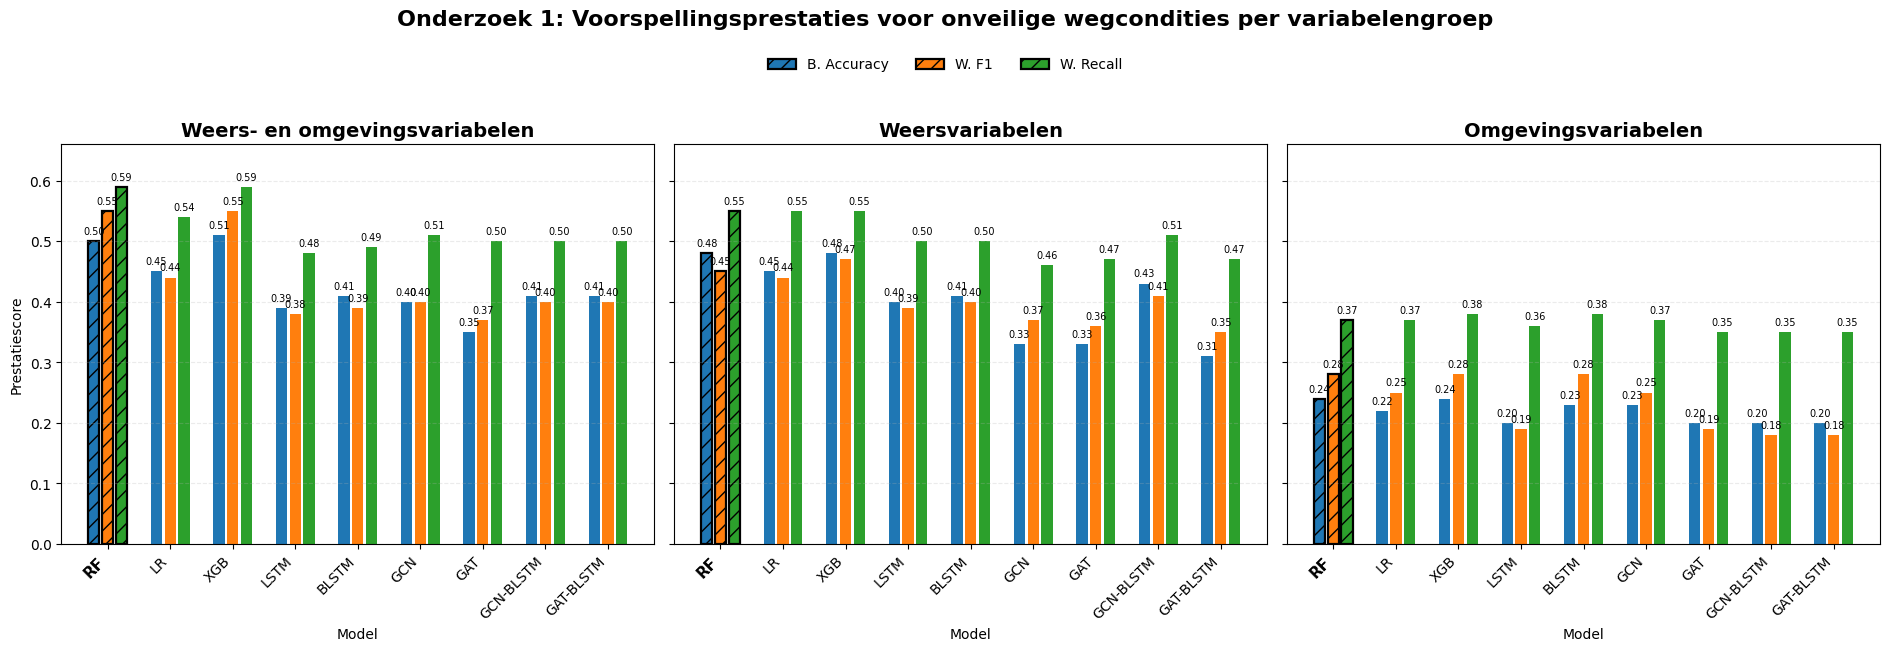

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
models = [
    "RF", "LR", "XGB", "LSTM", "BLSTM",
    "GCN", "GAT", "GCN-BLSTM", "GAT-BLSTM"
]

data = {
    "Weers- en omgevingsvariabelen": {
        "B. Accuracy": [0.50, 0.45, 0.51, 0.39, 0.41, 0.40, 0.35, 0.41, 0.41],
        "W. F1":       [0.55, 0.44, 0.55, 0.38, 0.39, 0.40, 0.37, 0.40, 0.40],
        "W. Recall":   [0.59, 0.54, 0.59, 0.48, 0.49, 0.51, 0.50, 0.50, 0.50]
    },

    "Weersvariabelen": {
        "B. Accuracy": [0.48, 0.45, 0.48, 0.40, 0.41, 0.33, 0.33, 0.43, 0.31],
        "W. F1":       [0.45, 0.44, 0.47, 0.39, 0.40, 0.37, 0.36, 0.41, 0.35],
        "W. Recall":   [0.55, 0.55, 0.55, 0.50, 0.50, 0.46, 0.47, 0.51, 0.47]
    },

    "Omgevingsvariabelen": {
        "B. Accuracy": [0.24, 0.22, 0.24, 0.20, 0.23, 0.23, 0.20, 0.20, 0.20],
        "W. F1":       [0.28, 0.25, 0.28, 0.19, 0.28, 0.25, 0.19, 0.18, 0.18],
        "W. Recall":   [0.37, 0.37, 0.38, 0.36, 0.38, 0.37, 0.35, 0.35, 0.35]
    }
}

metrics = ["B. Accuracy", "W. F1", "W. Recall"]

# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1, 3,
    figsize=(19, 6.5),
    sharey=True
)

x = np.arange(len(models))

# Dunner dan voorheen
width = 0.18

# Iets meer ruimte tussen de drie bars per model
offsets = [-0.22, 0, 0.22]

for ax, (subset, scores) in zip(axes, data.items()):

    for i, metric in enumerate(metrics):

        values = scores[metric]

        bars = ax.bar(
            x + offsets[i],
            values,
            width=width,
            label=metric
        )

        # -------------------------------------------------
        # Ruwe score boven iedere bar
        # -------------------------------------------------
        for j, (bar, value) in enumerate(zip(bars, values)):

            # RF extra benadrukken
            if models[j] == "RF":
                bar.set_edgecolor("black")
                bar.set_linewidth(1.6)
                bar.set_hatch("//")

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.008,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=7
            )

    ax.set_title(
        subset,
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        models,
        rotation=45,
        ha="right"
    )

    # RF-label vet maken
    for label in ax.get_xticklabels():
        if label.get_text() == "RF":
            label.set_fontweight("bold")
            label.set_fontsize(11)

    ax.set_ylim(0, 0.66)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.25
    )

    ax.set_xlabel("Model")

axes[0].set_ylabel("Prestatiescore")

# ---------------------------------------------------------
# Gezamenlijke legenda
# ---------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 0.94)
)

fig.suptitle(
    "Onderzoek 1: Voorspellingsprestaties voor onveilige "
    "wegcondities per variabelengroep",
    fontsize=16,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

plt.show()

In [ ]:
#Load dataset

df = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/preprocessed_df.csv")  #Preprocessing data - left at 'Overig' incident type to redo the labels
df[0:10]

,OBJECTID,dataset,start_date,start_time,end_date,end_time,incident_duration,incident_type,incident_description,traffic_jam,...,sum_prec (1h),max_prec (5min),max_temp,round_max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,total_acreage_%
0,1,UDLS,1/21/2014,12:46:46,1/21/2014,13:44:12,00:57:25,Overig,modder op oprit,NaN,...,0.000000,0.00,5.753218,6,35.0,NaN,1.0,33.0,3.0,72
1,2,UDLS,1/27/2014,11:52:00,1/27/2014,12:48:00,00:56:00,Wateroverlast,wateroverlast geldrop,NaN,...,0.000000,0.00,5.988402,6,40.0,4.0,6.0,34.0,1.0,85
2,3,UDLS,2-6-2014,08:35:41,2-7-2014,15:38:36,07:02:54,Schade aan infra,uitspoeling in de mb,NaN,...,0.000000,0.00,9.551981,10,64.0,NaN,0.0,30.0,2.0,96
3,4,UDLS,3-5-2014,00:56:27,3-5-2014,04:07:14,03:10:47,Zichtbaarheid,mist everdingen - deil,NaN,...,0.000000,0.00,12.243471,12,41.0,17.0,1.0,26.0,7.0,92
4,5,UDLS,3/14/2014,07:00:14,3/14/2014,12:10:04,05:09:50,Zichtbaarheid,gesloten sps i.v.m. mist,NaN,...,0.000000,0.00,11.787109,12,61.0,9.0,NaN,24.0,6.0,100
5,830,UDLS,2/28/2018,14:54:58,2/28/2018,15:08:49,00:13:51,Brand,bermbrand,NaN,...,0.000000,0.00,-5.431953,-5,76.0,NaN,0.0,23.0,0.0,99
6,7,UDLS,4/24/2014,19:50:36,4/25/2014,14:22:17,18:31:41,Wateroverlast,wateroverlast,NaN,...,1.520000,0.34,20.173279,20,42.0,8.0,5.0,37.0,3.0,95
7,8,UDLS,4/24/2014,15:35:26,4/25/2014,00:25:08,08:49:42,Wateroverlast,wateroverlast,NaN,...,31.630000,12.54,20.263058,20,32.0,36.0,1.0,20.0,8.0,97
8,1429,UDLS,2/28/2018,14:29:55,2/28/2018,16:03:13,01:33:18,Brand,autobrand/strooien,NaN,...,0.000000,0.00,-4.539720,-5,22.0,39.0,0.0,20.0,7.0,88
9,10,UDLS,7/28/2014,12:17:16,7/28/2014,12:57:12,00:39:56,Wateroverlast,wateroverlast + schade,NaN,...,28.999999,5.51,23.615494,24,44.0,3.0,6.0,44.0,4.0,101


In [ ]:
#Preprocessing step 1 (Handling NAs)

#Check missing values
print('Columns with missing values:', df.isnull().any())
print('Observations of original df:', len(df))

#Remove observations with a missing end time/end date
df_1 = df.dropna(subset=['end_date', 'end_time', 'incident_type'])

print('--------------------------')

#Check missing values
print('After removal:', df_1.isnull().any())
print('Observations of cleaned df:', len(df_1))

#Replacing all NAs in traffic and areal variables with 0
df_1 = df_1.fillna(0)

print('--------------------------')

#Check missing values again
print('After filling NAs with 0:', df_1.isnull().any())

Columns with missing values: OBJECTID                False
dataset                 False
start_date              False
start_time              False
end_date                 True
end_time                 True
incident_duration       False
incident_type            True
incident_description    False
traffic_jam              True
road_level              False
lon                     False
lat                     False
sum_prec (1h)           False
max_prec (5min)         False
max_temp                False
round_max_temp          False
low_veg_%                True
mid_high_veg_%           True
misc_%                   True
pavement_%               True
water_%                  True
total_acreage_%         False
dtype: bool
Observations of original df: 7591
--------------------------
After removal: OBJECTID                False
dataset                 False
start_date              False
start_time              False
end_date                False
end_time                False
incident_dura

In [ ]:
df_1['incident_type'].unique()

array(['Overig', 'Wateroverlast', 'Schade aan infra', 'Zichtbaarheid',
       'Brand', 'Gladheid', 'Voorwerp', 'Ongeval', 'Gladheidsbestrijding',
       'Storing', 'Invalid - Gladheidsbestrijding', 'Onbekend',
       'Weergerelateerd wegprobleem'], dtype=object)

In [ ]:
incidents_all = df_1['incident_type'].value_counts()
print(incidents_all)
incidents_filtered = df_1[df_1['incident_type'].isin(['Brand', 'Gladheid',
       'Schade aan infra', 'Wateroverlast','Zichtbaarheid', 'Onbekend', 'Overig'])]['incident_type'].value_counts()
print(incidents_filtered)

incident_type
Wateroverlast                     2129
Voorwerp                          2053
Brand                             1095
Schade aan infra                   769
Overig                             341
Ongeval                            332
Gladheid                           294
Gladheidsbestrijding               155
Zichtbaarheid                      104
Storing                             37
Onbekend                            30
Weergerelateerd wegprobleem         20
Invalid - Gladheidsbestrijding      18
Name: count, dtype: int64
incident_type
Wateroverlast       2129
Brand               1095
Schade aan infra     769
Overig               341
Gladheid             294
Zichtbaarheid        104
Onbekend              30
Name: count, dtype: int64


In [ ]:
#Leave out some labels from incident_type

filtered_df = df_1[df_1['incident_type'].isin(['Brand', 'Gladheid',
       'Schade aan infra', 'Wateroverlast', 'Onbekend', 'Overig'])] #'Onbekend', 'Overig'
print(filtered_df)

      OBJECTID       dataset start_date start_time   end_date  end_time  \
0            1          UDLS  1/21/2014   12:46:46  1/21/2014  13:44:12   
1            2          UDLS  1/27/2014   11:52:00  1/27/2014  12:48:00   
2            3          UDLS   2-6-2014   08:35:41   2-7-2014  15:38:36   
5          830          UDLS  2/28/2018   14:54:58  2/28/2018  15:08:49   
6            7          UDLS  4/24/2014   19:50:36  4/25/2014  14:22:17   
...        ...           ...        ...        ...        ...       ...   
7567      5445          UDLS  7/24/2019   10:15:06  7/24/2019  13:47:34   
7568      5452          UDLS  7/25/2019   14:19:02  7/25/2019  16:05:04   
7569      5442          UDLS  7/25/2019   12:21:45  7/25/2019  12:32:45   
7570      5446          UDLS  7/25/2019   12:35:06  7/25/2019  12:40:32   
7571      7338  Dexter files  7/25/2019   14:26:00  7/25/2019  14:57:13   

     incident_duration     incident_type     incident_description  \
0             00:57:25        

In [ ]:
#Translate incident labels from Dutch to English

#'Brand', 'Gladheid', 'Schade aan infra', 'Wateroverlast','Zichtbaarheid', 'Onbekend', 'Overig'
#Roadside fire, Slippery pavement, Infrastructure damage, Road ponding, Poor visbility, Unknown, Miscellaneous
filtered_df = filtered_df.replace({'incident_type': {'Brand': 'Roadside fire',
                                                     'Gladheid': 'Slippery pavement', #'Slippery pavement', (Reduce the amount of classes to 3)
                                                     'Schade aan infra': 'Infrastructure damage',#Infrastructure damage',
                                                     'Wateroverlast': 'Road ponding',
                                         #            'Zichtbaarheid':'Poor visbility',
                                                     'Onbekend':'Other',
                                                     'Overig':'Other'}})

In [ ]:
filtered_df

,OBJECTID,dataset,start_date,start_time,end_date,end_time,incident_duration,incident_type,incident_description,traffic_jam,...,sum_prec (1h),max_prec (5min),max_temp,round_max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,total_acreage_%
0,1,UDLS,1/21/2014,12:46:46,1/21/2014,13:44:12,00:57:25,Other,modder op oprit,0.0,...,0.00,0.00,5.753218,6,35.0,0.0,1.0,33.0,3.0,72
1,2,UDLS,1/27/2014,11:52:00,1/27/2014,12:48:00,00:56:00,Road ponding,wateroverlast geldrop,0.0,...,0.00,0.00,5.988402,6,40.0,4.0,6.0,34.0,1.0,85
2,3,UDLS,2-6-2014,08:35:41,2-7-2014,15:38:36,07:02:54,Infrastructure damage,uitspoeling in de mb,0.0,...,0.00,0.00,9.551981,10,64.0,0.0,0.0,30.0,2.0,96
5,830,UDLS,2/28/2018,14:54:58,2/28/2018,15:08:49,00:13:51,Roadside fire,bermbrand,0.0,...,0.00,0.00,-5.431953,-5,76.0,0.0,0.0,23.0,0.0,99
6,7,UDLS,4/24/2014,19:50:36,4/25/2014,14:22:17,18:31:41,Road ponding,wateroverlast,0.0,...,1.52,0.34,20.173279,20,42.0,8.0,5.0,37.0,3.0,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7567,5445,UDLS,7/24/2019,10:15:06,7/24/2019,13:47:34,03:32:28,Roadside fire,bermbrand,0.0,...,0.00,0.00,38.947773,39,49.0,19.0,2.0,28.0,2.0,100
7568,5452,UDLS,7/25/2019,14:19:02,7/25/2019,16:05:04,01:46:02,Roadside fire,bermbrand + va klapband,0.0,...,0.00,0.00,39.705345,40,9.0,6.0,2.0,15.0,0.0,32
7569,5442,UDLS,7/25/2019,12:21:45,7/25/2019,12:32:45,00:11:00,Roadside fire,bermbrand,0.0,...,0.00,0.00,39.760983,40,42.0,0.0,4.0,27.0,2.0,75
7570,5446,UDLS,7/25/2019,12:35:06,7/25/2019,12:40:32,00:05:26,Roadside fire,bermbrand,0.0,...,0.00,0.00,39.760983,40,45.0,1.0,5.0,28.0,2.0,81


In [ ]:
filtered_df.shape

(4658, 23)

In [ ]:
incidents_all = filtered_df['incident_type'].value_counts()
print(incidents_all)
print(len(filtered_df['incident_type']))

incident_type
Road ponding             2129
Roadside fire            1095
Infrastructure damage     769
Other                     371
Slippery pavement         294
Name: count, dtype: int64
4658


In [ ]:
#Preprocessing step 2 - Dropping variables, date_time transformation


#Dropping unnecessary columns and all the temporal columns (Incident type to be preprocessed and added later)
df1 = filtered_df.drop(columns=['OBJECTID',
                       'dataset',
                       'incident_description',
                       'traffic_jam',
                      # 'lat',
                     #  'lon',
                       'round_max_temp',
                       'total_acreage_%'])


#Removing missing values
#print('Columns with missing values:', df.isnull().any())

#Extracting all temporal variables and converting these into datetime[ns64] data
#The temporal information is added to the train, validation, and test datasets later

df1['start_date'] = pd.to_datetime(df1['start_date'], format='mixed', dayfirst=True)
df1['end_date'] = pd.to_datetime(df1['end_date'], format='mixed', dayfirst=True)
df1['incident_duration'] = pd.to_datetime(df1['incident_duration'], format='%H:%M:%S')
df1['start_time'] = pd.to_datetime(df1['start_time'], format='%H:%M:%S')
df1['end_time'] = pd.to_datetime(df1['end_time'], format='%H:%M:%S')

#Label encoding the target variable:

#Defining the encoder
label_enc1 = skprep.LabelEncoder()
label_enc2 = skprep.LabelEncoder()
label_enc1.fit(df1['incident_type'])
label_enc2.fit(df1['road_level'])

#Transforming the target variable
df1['incident_type'] = label_enc1.transform(df1['incident_type'])
df1['road_level'] = label_enc2.transform(df1['road_level'])

df1.head()
df1.dtypes

,0
start_date,datetime64[ns]
start_time,datetime64[ns]
end_date,datetime64[ns]
end_time,datetime64[ns]
incident_duration,datetime64[ns]
incident_type,int64
road_level,int64
lon,float64
lat,float64
sum_prec (1h),float64


In [ ]:
df1

,start_date,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),max_prec (5min),max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%
0,2014-01-21,1900-01-01 12:46:46,2014-01-21,1900-01-01 13:44:12,1900-01-01 00:57:25,1,0,5.186706,51.903114,0.00,0.00,5.753218,35.0,0.0,1.0,33.0,3.0
1,2014-01-27,1900-01-01 11:52:00,2014-01-27,1900-01-01 12:48:00,1900-01-01 00:56:00,2,1,5.254379,51.829996,0.00,0.00,5.988402,40.0,4.0,6.0,34.0,1.0
2,2014-06-02,1900-01-01 08:35:41,2014-07-02,1900-01-01 15:38:36,1900-01-01 07:02:54,0,0,5.146372,52.118044,0.00,0.00,9.551981,64.0,0.0,0.0,30.0,2.0
5,2018-02-28,1900-01-01 14:54:58,2018-02-28,1900-01-01 15:08:49,1900-01-01 00:13:51,3,0,6.890518,53.170201,0.00,0.00,-5.431953,76.0,0.0,0.0,23.0,0.0
6,2014-04-24,1900-01-01 19:50:36,2014-04-25,1900-01-01 14:22:17,1900-01-01 18:31:41,2,0,5.157969,52.140820,1.52,0.34,20.173279,42.0,8.0,5.0,37.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7567,2019-07-24,1900-01-01 10:15:06,2019-07-24,1900-01-01 13:47:34,1900-01-01 03:32:28,3,0,5.606413,51.312105,0.00,0.00,38.947773,49.0,19.0,2.0,28.0,2.0
7568,2019-07-25,1900-01-01 14:19:02,2019-07-25,1900-01-01 16:05:04,1900-01-01 01:46:02,3,0,5.591747,51.416806,0.00,0.00,39.705345,9.0,6.0,2.0,15.0,0.0
7569,2019-07-25,1900-01-01 12:21:45,2019-07-25,1900-01-01 12:32:45,1900-01-01 00:11:00,3,0,4.740278,51.545056,0.00,0.00,39.760983,42.0,0.0,4.0,27.0,2.0
7570,2019-07-25,1900-01-01 12:35:06,2019-07-25,1900-01-01 12:40:32,1900-01-01 00:05:26,3,0,4.740424,51.542346,0.00,0.00,39.760983,45.0,1.0,5.0,28.0,2.0


In [ ]:
#Temporal ordering

df1 = df1.sort_values(by='start_date').set_index('start_date')

In [ ]:
df1[4000:4050]

,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),max_prec (5min),max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,x_coor,y_coor,z_coor,cluster
start_date,,,,,,,,,,,,,,,,,,,,
2022-02-18,1900-01-01 15:40:54,2022-02-18,1900-01-01 15:46:15,1900-01-01 00:05:21,0,0,4.807316,51.540907,0.00,0.00,12.450347,83.0,0.0,1.0,14.0,2.0,0.619768,0.052123,0.783052,0
2022-02-18,1900-01-01 15:28:48,2022-02-18,1900-01-01 16:08:31,1900-01-01 00:39:43,1,0,6.020126,53.030564,0.01,0.01,10.802402,44.0,20.0,0.0,35.0,0.0,0.598072,0.063072,0.798956,-1
2022-02-18,1900-01-01 17:33:42,2022-02-18,1900-01-01 18:09:45,1900-01-01 00:36:03,0,0,4.951659,52.538620,0.18,0.07,10.944884,68.0,0.0,2.0,17.0,8.0,0.605957,0.052499,0.793763,0
2022-02-18,1900-01-01 14:27:17,2022-02-18,1900-01-01 16:17:50,1900-01-01 01:50:33,0,0,5.034387,52.773341,0.00,0.00,10.731048,23.0,11.0,2.0,17.0,5.0,0.602636,0.053088,0.796249,-1
2022-02-18,1900-01-01 16:54:33,2022-02-18,1900-01-01 19:13:21,1900-01-01 02:18:48,0,0,4.686606,52.260054,0.00,0.00,11.125898,23.0,0.0,7.0,70.0,0.0,0.610032,0.050010,0.790797,0
2022-02-18,1900-01-01 17:31:42,2022-02-19,1900-01-01 05:15:40,1900-01-01 11:43:58,1,0,6.543568,52.544484,0.04,0.02,11.592972,13.0,7.0,2.0,5.0,0.0,0.604184,0.069303,0.793826,-1
2022-02-18,1900-01-01 16:07:13,2022-02-18,1900-01-01 16:21:49,1900-01-01 00:14:36,1,0,5.572750,53.047428,0.00,0.00,10.610632,52.0,18.0,6.0,22.0,3.0,0.598312,0.058378,0.799133,-1
2022-02-18,1900-01-01 14:56:08,2022-02-18,1900-01-01 15:18:53,1900-01-01 00:22:45,1,0,5.772951,52.698111,0.01,0.01,11.122593,21.0,1.0,0.0,22.0,1.0,0.602941,0.060957,0.795454,-1
2022-02-18,1900-01-01 15:56:52,2022-02-18,1900-01-01 19:59:40,1900-01-01 04:02:48,0,0,5.541974,52.276325,0.00,0.00,11.680251,46.0,4.0,0.0,24.0,2.0,0.608994,0.059090,0.790971,0


In [ ]:
#Mapping of labels

label_enc1_mapping = dict(zip(label_enc1.classes_, label_enc1.transform(label_enc1.classes_)))
print(label_enc1_mapping)
label_enc2_mapping = dict(zip(label_enc2.classes_, label_enc2.transform(label_enc2.classes_)))
print(label_enc2_mapping)

{'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2), 'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4)}
{'maaiveld': np.int64(0), 'overbrugging': np.int64(1), 'tunneldeel': np.int64(2)}


In [ ]:
#Preprocessing step 3 - Converting latitude and longitude as inputs

lat = df1['lat']
lon = df1['lon']

lat_radians = np.deg2rad(lat)
lon_radians = np.deg2rad(lon)

x = np.cos(lat_radians) * np.cos(lon_radians)
y = np.cos(lat_radians) * np.sin(lon_radians)
z = np.sin(lat_radians)

df1['x_coor'] = x
df1['y_coor'] = y
df1['z_coor'] = z

In [ ]:
df1[['x_coor', 'y_coor', 'z_coor']]

,x_coor,y_coor,z_coor
0,0.614467,0.055777,0.786969
1,0.615400,0.056595,0.786181
2,0.611561,0.055079,0.789278
5,0.595110,0.071916,0.800420
6,0.611238,0.055175,0.789522
...,...,...,...
7567,0.622088,0.061067,0.780562
7568,0.620683,0.060768,0.781703
7569,0.619772,0.051393,0.783097
7570,0.619809,0.051398,0.783068


DBSCAN clustering

In [ ]:
#Load necessary libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import geopy
import shapely
from geopy.distance import great_circle
from shapely.geometry import MultiPoint
!pip install geopandas
#Image saving

import selenium
import io
from PIL import Image
import geopandas as gpd

import random
random.seed(26)

coords = df1[['lat', 'lon']]
coords.head()

,lat,lon
0,51.903114,5.186706
1,51.829996,5.254379
2,52.118044,5.146372
5,53.170201,6.890518
6,52.140820,5.157969


In [ ]:
kms_per_radian = 6371.0088
epsilon = 20/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

Number of clusters: 3


In [ ]:
df1['cluster'] = cluster_labels
print(Counter(df1['cluster']))

Counter({0: 3101, -1: 1235, 1: 322})


In [ ]:
#Evaluate cluster representation

from sklearn import metrics

clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords))
metrics.silhouette_score(coords, clusters)

np.float64(0.4244109608500305)

In [ ]:
cluster1 = df1[df1['cluster'] == -1]
cluster2 = df1[df1['cluster'] == 0]
cluster3 = df1[df1['cluster'] == 1]
print("Cluster 1 shape", cluster1.shape)
print("Cluster 2 shape", cluster2.shape)
print("Cluster 3 shape", cluster3.shape)
print("Unique incidents in cluster 1", cluster1['incident_type'].unique())
print("Unique incidents in cluster 2", cluster2['incident_type'].unique())
print("Unique incidents in cluster 3", cluster3['incident_type'].unique())

Cluster 1 shape (1235, 21)
Cluster 2 shape (3101, 21)
Cluster 3 shape (322, 21)
Unique incidents in cluster 1 [3 4 2 0 1]
Unique incidents in cluster 2 [1 2 0 3 4]
Unique incidents in cluster 3 [3 2 0 1 4]


In [ ]:
cluster3.head()

,start_date,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),...,max_temp,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,x_coor,y_coor,z_coor,cluster
72,2018-07-01,1900-01-01 14:28:05,2018-07-01,1900-01-01 14:55:17,1900-01-01 00:27:12,3,0,5.879143,51.166865,0.0,...,4.502483,55.0,15.0,5.0,24.0,0.0,0.623756,0.064229,0.778975,1
130,2015-02-19,1900-01-01 06:14:21,2015-02-19,1900-01-01 06:53:19,1900-01-01 00:38:58,3,0,5.894304,51.130306,0.0,...,6.647906,12.0,0.0,0.0,20.0,0.0,0.624233,0.064446,0.778575,1
202,2018-05-04,1900-01-01 05:52:40,2018-05-04,1900-01-01 06:12:22,1900-01-01 00:19:42,3,0,5.787577,50.968141,0.0,...,9.729857,56.0,0.0,3.0,39.0,3.0,0.626542,0.063505,0.776796,1
398,2014-12-22,1900-01-01 00:15:41,2014-12-22,1900-01-01 00:46:25,1900-01-01 00:30:44,3,0,5.822930,50.951134,0.0,...,11.472540,24.0,11.0,1.0,18.0,8.0,0.626732,0.063915,0.776609,1
1347,2018-10-19,1900-01-01 19:07:06,2018-10-19,1900-01-01 19:20:15,1900-01-01 00:13:09,3,0,5.785845,50.938023,0.0,...,16.631786,56.0,10.0,4.0,22.0,0.0,0.626950,0.063527,0.776465,1


In [ ]:
#Mapping initial cluster

frames1 = [cluster1, cluster2, cluster3]

combined_clusters1 = pd.concat(frames1)

combined_clusters1['cluster'].value_counts()

,count
cluster,
0,3101
-1,1235
1,322


In [ ]:
# Convert DataFrame to GeoDataFrame
combined_clusters1_gdf = gpd.GeoDataFrame(
    combined_clusters1,
    geometry=gpd.points_from_xy(combined_clusters1.lon, combined_clusters1.lat)
)

# Get coordinates in (lat, lon) format
combined_clusters_list1 = list(zip(combined_clusters1_gdf.lat, combined_clusters1_gdf.lon))

In [ ]:
# Create map
import folium
com_map1 = folium.Map(location=(51.903, 5.187), zoom_start=8)

In [ ]:
# Add markers
for i, coordinates in enumerate(combined_clusters_list1):
    cluster_label = combined_clusters1_gdf.cluster.iloc[i]

    if cluster_label == 0: #Central Netherlands (to sub-split)
        type_color = "red"
    elif cluster_label == 1: #Limburg
        type_color = "blue"
    elif cluster_label == -1: #Outskirts Netherlands
        type_color = "green"
    else:
        type_color = "black"

    folium.Marker(
        location=coordinates,
        icon=folium.Icon(color=type_color),
        popup=f"Cluster information<br>{cluster_label}"
    ).add_to(com_map1)

#com_map1

Subclustering cluster 2 (n = 3101)

In [ ]:
coords2 = cluster2[['lat', 'lon']]
coords2.head()

,lat,lon
0,51.903114,5.186706
1,51.829996,5.254379
2,52.118044,5.146372
6,52.140820,5.157969
7,52.096872,5.208125


In [ ]:
random.seed(26)

kms_per_radian = 6371.0088
epsilon = 15/ kms_per_radian
db = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit(np.radians(coords2))
cluster_labels = db.labels_
num_clusters = len(set(cluster_labels))
clusters = pd.Series([coords2[cluster_labels == n] for n in range(num_clusters)])
print('Number of clusters: {}'.format(num_clusters))

Number of clusters: 3


In [ ]:
cluster2['cluster'] = cluster_labels
print(cluster2['cluster'].value_counts())

cluster
 1    1281
 0    1060
-1     760
Name: count, dtype: int64


/tmp/ipykernel_7144/2096689883.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster2['cluster'] = cluster_labels


In [ ]:
clusters = DBSCAN(eps=epsilon, min_samples=200, algorithm='ball_tree', metric='haversine').fit_predict(np.radians(coords2))
metrics.silhouette_score(coords2, clusters)

np.float64(0.3746308882730513)

In [ ]:
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
#cluster2d = cluster2[cluster2['cluster'] == 2]

print(cluster2a.shape)
print(cluster2b.shape)
print(cluster2c.shape)
#print(cluster2d.shape)

(760, 21)
(1060, 21)
(1281, 21)


In [ ]:
#Mapping all clusters

cluster_neg1 = df1[df1['cluster'] == -1]
cluster1 = df1[df1['cluster'] == 1]
cluster2a = cluster2[cluster2['cluster'] == -1]
cluster2b = cluster2[cluster2['cluster'] == 0]
cluster2c = cluster2[cluster2['cluster'] == 1]
#cluster2d = cluster2[cluster2['cluster'] == 2]

In [ ]:
cluster_neg1.loc[cluster_neg1["cluster"] == -1, "cluster"] = 2
cluster1.loc[cluster1["cluster"] == 1, "cluster"] = 3

In [ ]:
print("Cluster -1 shape:",cluster_neg1.shape)
print("Cluster 1 shape:",cluster1.shape)
print("Cluster 2a shape:",cluster2a.shape)
print("Cluster 2b shape:",cluster2b.shape)
print("Cluster 2c shape:",cluster2c.shape)
#print("Cluster 2d shape:", cluster2d.shape)

Cluster -1 shape: (1235, 21)
Cluster 1 shape: (322, 21)
Cluster 2a shape: (760, 21)
Cluster 2b shape: (1060, 21)
Cluster 2c shape: (1281, 21)


In [ ]:
frames = [cluster2a, cluster2b, cluster2c, cluster1, cluster_neg1]

combined_clusters = pd.concat(frames)

In [ ]:
combined_clusters['cluster'].value_counts()

,count
cluster,
1,1281
2,1235
0,1060
-1,760
3,322


In [ ]:
# Convert DataFrame to GeoDataFrame
combined_clusters_gdf = gpd.GeoDataFrame(
    combined_clusters,
    geometry=gpd.points_from_xy(combined_clusters.lon, combined_clusters.lat)
)

# Get coordinates in (lat, lon) format
combined_clusters_list = list(zip(combined_clusters_gdf.lat, combined_clusters_gdf.lon))

In [ ]:
# Create map
com_map = folium.Map(location=(51.903, 5.187), zoom_start=8)

In [ ]:
# Add markers
for i, coordinates in enumerate(combined_clusters_list):
    cluster_label = combined_clusters_gdf.cluster.iloc[i]

    if cluster_label == 0: #Amsterdam - Utrecht
        type_color = "red"
    elif cluster_label == 1: #Randstad
        type_color = "blue"
    elif cluster_label == -1: #Suburban (Brabant, Alkmaar)
        type_color = "green"
    elif cluster_label == 2: #Outskirts (North Holland)
        type_color = "purple"
    else:
        type_color = "gray" #3, Limburg

    folium.Marker(
        location=coordinates,
        icon=folium.Icon(color=type_color),
        popup=f"Cluster information<br>{cluster_label}"
    ).add_to(com_map)

#com_map

Data augmentation (bootstrapping) & preprocessing

In [ ]:
cluster_suburban = cluster2a.copy()
cluster_ams_ut = cluster2b.copy()
cluster_dh_rot = cluster2c.copy()
cluster_outlier = cluster_neg1.copy()
cluster_limburg = cluster1.copy()

In [ ]:
cluster_suburban = cluster_suburban.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_ams_ut = cluster_ams_ut.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_dh_rot = cluster_dh_rot.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_outlier = cluster_outlier.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                     2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})
cluster_limburg = cluster_limburg.replace({'incident_type': {0: 'Infrastructure damage',
                                                             1: 'Other',
                                                            2: 'Road ponding',
                                                     3: 'Roadside fire',
                                                    4: 'Slippery pavement'}})

label_enc21 = skprep.LabelEncoder()
label_enc21.fit(cluster_suburban['incident_type'])
cluster_suburban['incident_type'] = label_enc21.transform(cluster_suburban['incident_type'])
cluster_ams_ut['incident_type'] = label_enc21.transform(cluster_ams_ut['incident_type'])
cluster_dh_rot['incident_type'] = label_enc21.transform(cluster_dh_rot['incident_type'])
cluster_outlier['incident_type'] = label_enc21.transform(cluster_outlier['incident_type'])
cluster_limburg['incident_type'] = label_enc21.transform(cluster_limburg['incident_type'])

In [ ]:
label_enc21_mapping = dict(zip(label_enc21.classes_, label_enc21.transform(label_enc21.classes_)))
print(label_enc21)

LabelEncoder()


In [ ]:
print(cluster_suburban.shape)
print(cluster_ams_ut.shape)
print(cluster_dh_rot.shape)
print(cluster_outlier.shape)
print(cluster_limburg.shape)

#'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2),
#'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4), 'Zichtbaarheid': np.int64(5)

print("Cluster outlier", cluster_suburban['incident_type'].value_counts())
print("Cluster Amsterdam - Utrecht", cluster_ams_ut['incident_type'].value_counts())
print("Cluster Randstad", cluster_dh_rot['incident_type'].value_counts())
print("Cluster outlier2" ,cluster_outlier['incident_type'].value_counts())
print("Cluster Limburg", cluster_limburg['incident_type'].value_counts())

(760, 21)
(1060, 21)
(1281, 21)
(1235, 21)
(322, 21)
Cluster outlier incident_type
3    311
2    226
0    133
1     47
4     43
Name: count, dtype: int64
Cluster Amsterdam - Utrecht incident_type
2    447
3    218
0    151
4    124
1    120
Name: count, dtype: int64
Cluster Randstad incident_type
2    775
3    231
0    120
1    102
4     53
Name: count, dtype: int64
Cluster outlier2 incident_type
2    498
0    305
3    285
1     80
4     67
Name: count, dtype: int64
Cluster Limburg incident_type
2    183
0     60
3     50
1     22
4      7
Name: count, dtype: int64


In [ ]:
#Duplicate stary_date and index

cluster_suburban['start'] = cluster_suburban['start_date']
cluster_ams_ut['start'] = cluster_ams_ut['start_date']
cluster_dh_rot['start'] = cluster_dh_rot['start_date']
cluster_outlier['start'] = cluster_outlier['start_date']
cluster_limburg['start'] = cluster_limburg['start_date']

cluster_suburban = cluster_suburban.sort_values(by='start_date').set_index('start_date')
cluster_ams_ut = cluster_ams_ut.sort_values(by='start_date').set_index('start_date')
cluster_dh_rot = cluster_dh_rot.sort_values(by='start_date').set_index('start_date')
cluster_outlier = cluster_outlier.sort_values(by='start_date').set_index('start_date')
cluster_limburg = cluster_limburg.sort_values(by='start_date').set_index('start_date')

In [ ]:
cluster_suburban

,start_time,end_date,end_time,incident_duration,incident_type,road_level,lon,lat,sum_prec (1h),max_prec (5min),...,low_veg_%,mid_high_veg_%,misc_%,pavement_%,water_%,x_coor,y_coor,z_coor,cluster,start
start_date,,,,,,,,,,,,,,,,,,,,,
2014-01-27,1900-01-01 11:52:00,2014-01-27,1900-01-01 12:48:00,1900-01-01 00:56:00,2,1,5.254379,51.829996,0.00,0.00,...,40.0,4.0,6.0,34.0,1.0,0.615400,0.056595,0.786181,-1,2014-01-27
2014-02-01,1900-01-01 10:10:29,2014-02-01,1900-01-01 10:38:03,1900-01-01 00:27:34,4,0,5.598054,51.651221,0.12,0.06,...,57.0,7.0,1.0,22.0,13.0,0.617488,0.060524,0.784248,-1,2014-02-01
2014-02-14,1900-01-01 17:57:29,2014-02-14,1900-01-01 19:42:32,1900-01-01 01:45:03,2,2,5.380990,51.708883,4.12,0.58,...,46.0,13.0,5.0,32.0,1.0,0.616927,0.058110,0.784872,-1,2014-02-14
2014-03-02,1900-01-01 06:56:18,2014-03-02,1900-01-01 06:57:03,1900-01-01 00:00:45,1,0,5.433771,51.491672,0.00,0.00,...,37.0,42.0,2.0,18.0,0.0,0.619830,0.058960,0.782518,-1,2014-03-02
2014-03-09,1900-01-01 14:45:02,2014-03-09,1900-01-01 16:52:41,1900-01-01 02:07:39,0,0,5.404583,51.474584,0.00,0.00,...,54.0,3.0,1.0,38.0,4.0,0.620093,0.058666,0.782332,-1,2014-03-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-23,1900-01-01 14:04:20,2022-12-23,1900-01-01 16:02:30,1900-01-01 01:58:10,2,0,5.259732,51.810168,0.90,0.17,...,41.0,19.0,8.0,22.0,2.0,0.615666,0.056677,0.785967,-1,2022-12-23
2022-12-25,1900-01-01 14:33:11,2022-12-25,1900-01-01 15:47:47,1900-01-01 01:14:36,2,1,5.291202,51.660302,0.77,0.14,...,14.0,17.0,10.0,24.0,1.0,0.617679,0.057205,0.784347,-1,2022-12-25
2022-12-25,1900-01-01 14:54:02,2022-12-25,1900-01-01 15:47:41,1900-01-01 00:53:39,2,1,5.291202,51.660302,0.53,0.14,...,14.0,17.0,10.0,24.0,1.0,0.617679,0.057205,0.784347,-1,2022-12-25


Bootstrapping before data splitting is not necessary as of now! The cells are at the end of the notebook

In [ ]:
#Test URC distribution

#cluster_suburban = cluster_suburban.replace({'incident_type': {0: 'Infrastructure damage',
#                                                             1: 'Other',
#                                                     2: 'Road ponding',
#                                                     3: 'Roadside fire',
#                                                   4: 'Slippery pavement'}})


In [ ]:
cluster_limburg.shape

(322, 21)

In [ ]:
def bootstrap_spatiotemporal_naive(df, n_samples=None):
    """
    Naively bootstraps spatiotemporal data (including time, lat, lon).
    Assumes rows are i.i.d., which may not be appropriate for time series.

    Parameters:
        df (pd.DataFrame): Must include 'timestamp', 'lat', 'lon', and features.
        n_samples (int): How many rows to sample. Defaults to len(df).

    Returns:
        pd.DataFrame: Bootstrapped dataset.
    """
    if n_samples is None:
        n_samples = len(df)
    return df.sample(n=n_samples, replace=True)

In [ ]:
#random.seed(27) #Bootstrap x 3
#bootstrap_suburban = bootstrap_spatiotemporal_naive(cluster_suburban, n_samples=2280) #760 x 3
#bootstrap_ams_ut = bootstrap_spatiotemporal_naive(cluster_ams_ut, n_samples=3180) #1060 x 3
#bootstrap_dh_rot = bootstrap_spatiotemporal_naive(cluster_dh_rot, n_samples=3843) #1281 x 3
#bootstrap_outlier = bootstrap_spatiotemporal_naive(cluster_outlier, n_samples=3705) #1235 x 3
#bootstrap_limburg = bootstrap_spatiotemporal_naive(cluster_limburg, n_samples=1000) #322 x 3

# Sort all bootstrapped dataframes by 'start_date' to maintain time-series order
#bootstrap_suburban = bootstrap_suburban.sort_values(by='start_date')
#bootstrap_ams_ut = bootstrap_ams_ut.sort_values(by='start_date')
#bootstrap_dh_rot = bootstrap_dh_rot.sort_values(by='start_date')
#bootstrap_outlier = bootstrap_outlier.sort_values(by='start_date')
#bootstrap_limburg = bootstrap_limburg.sort_values(by='start_date')



In [ ]:
#Save the bootstrapped samples
#bootstrap_suburban.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_suburban.csv', header=True, index=True)
#bootstrap_ams_ut.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_ams_ut.csv', header=True, index=True)
#bootstrap_dh_rot.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_dh_rot.csv', header=True, index=True)
#bootstrap_outlier.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_outlier.csv', header=True, index=True)
#bootstrap_limburg.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_limburg.csv', header=True, index=True)

In [ ]:
#Load and print the bootstrapped samples

bootstrap_suburban = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_suburban.csv', index_col=0)
bootstrap_ams_ut = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_ams_ut.csv', index_col=0)
bootstrap_dh_rot = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_dh_rot.csv', index_col=0)
bootstrap_outlier = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_outlier.csv', index_col=0)
bootstrap_limburg = pd.read_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/bootstrap_limburg.csv', index_col=0)

print("Bootstrapped outlier cluster URC distribution", bootstrap_suburban['incident_type'].value_counts())
print("Bootstrapped cluster Amsterdam - Utrecht URC distribution", bootstrap_ams_ut['incident_type'].value_counts())
print("Bootstrapped cluster Randstad URC distribution", bootstrap_dh_rot['incident_type'].value_counts())
print("Bootstrapped cluster outlier2 URC distribution", bootstrap_outlier['incident_type'].value_counts())
print("Bootstrapped cluster Limburg URC distribution", bootstrap_limburg['incident_type'].value_counts())

print("Original sample size - cluster outlier", cluster_suburban.shape, "Bootstrapped sample size", bootstrap_suburban.shape)
print("Original sample size - Amsterdam - Utrecht", cluster_ams_ut.shape, "Bootstrapped sample size", bootstrap_ams_ut.shape)
print("Original sample size - Randstad", cluster_dh_rot.shape, "Bootstrapped sample size", bootstrap_dh_rot.shape)
print("Original sample size - outlier2", cluster_outlier.shape, "Bootstrapped sample size", bootstrap_outlier.shape)
print("Original sample size - Limburg", cluster_limburg.shape, "Bootstrapped sample size", bootstrap_limburg.shape)

#'Infrastructure damage': np.int64(0), 'Other': np.int64(1), 'Road ponding': np.int64(2),
#'Roadside fire': np.int64(3), 'Slippery pavement': np.int64(4), 'Zichtbaarheid': np.int64(5)


Bootstrapped outlier cluster URC distribution incident_type
3    969
2    682
0    366
1    136
4    127
Name: count, dtype: int64
Bootstrapped cluster Amsterdam - Utrecht URC distribution incident_type
2    1354
3     643
0     437
4     374
1     372
Name: count, dtype: int64
Bootstrapped cluster Randstad URC distribution incident_type
2    2347
3     668
0     375
1     291
4     162
Name: count, dtype: int64
Bootstrapped cluster outlier2 URC distribution incident_type
2    1495
0     900
3     868
1     242
4     200
Name: count, dtype: int64
Bootstrapped cluster Limburg URC distribution incident_type
2    564
0    173
3    164
1     71
4     28
Name: count, dtype: int64
Original sample size - cluster outlier (760, 21) Bootstrapped sample size (2280, 21)
Original sample size - Amsterdam - Utrecht (1060, 21) Bootstrapped sample size (3180, 21)
Original sample size - Randstad (1281, 21) Bootstrapped sample size (3843, 21)
Original sample size - outlier2 (1235, 21) Bootstrapped sample

Weighted scores of all models across entire bootstrapped dataset

In [ ]:
cl1_size = 2280
cl2_size = 3180
cl3_size = 3843
cl4_size = 3705
cl5_size = 1000

total = cl1_size + cl2_size + cl3_size + cl4_size + cl5_size
print(total)

w_cl1 = cl1_size / total
w_cl2 = cl2_size / total
w_cl3 = cl3_size / total
w_cl4 = cl4_size / total
w_cl5 = cl5_size / total

print("Weight Cluster 1", w_cl1)
print("Weight Cluster 2", w_cl2)
print("Weight Cluster 3", w_cl3)
print("Weight Cluster 4", w_cl4)
print("Weight Cluster 5", w_cl5)

14008
Weight Cluster 1 0.16276413478012564
Weight Cluster 2 0.22701313535122786
Weight Cluster 3 0.27434323243860653
Weight Cluster 4 0.2644917190177042
Weight Cluster 5 0.0713877784123358


In [ ]:
#Standardization of infrastructure and temperature data

from sklearn import preprocessing

infra_col = ['low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']

temp = ['max_temp']

scaler = preprocessing.MinMaxScaler()

bootstrap_suburban[infra_col] = scaler.fit_transform(bootstrap_suburban[infra_col])
bootstrap_suburban[temp] = scaler.fit_transform(bootstrap_suburban[temp])

bootstrap_ams_ut[infra_col] = scaler.fit_transform(bootstrap_ams_ut[infra_col])
bootstrap_ams_ut[temp] = scaler.fit_transform(bootstrap_ams_ut[temp])

bootstrap_dh_rot[infra_col] = scaler.fit_transform(bootstrap_dh_rot[infra_col])
bootstrap_dh_rot[temp] = scaler.fit_transform(bootstrap_dh_rot[temp])

bootstrap_outlier[infra_col] = scaler.fit_transform(bootstrap_outlier[infra_col])
bootstrap_outlier[temp] = scaler.fit_transform(bootstrap_outlier[temp])

bootstrap_limburg[infra_col] = scaler.fit_transform(bootstrap_limburg[infra_col])
bootstrap_limburg[temp] = scaler.fit_transform(bootstrap_limburg[temp])


#Log 1-p scaling of precipitation data

sum1 = bootstrap_suburban['sum_prec (1h)']
sum2 = bootstrap_ams_ut['sum_prec (1h)']
sum3 = bootstrap_dh_rot['sum_prec (1h)']
sum4 = bootstrap_outlier['sum_prec (1h)']
sum5 = bootstrap_limburg['sum_prec (1h)']

logsum1 = np.log1p(sum1)
logsum2 = np.log1p(sum2)
logsum3 = np.log1p(sum3)
logsum4 = np.log1p(sum4)
logsum5 = np.log1p(sum5)

bootstrap_suburban['sum_prec (1h)'] = logsum1
bootstrap_ams_ut['sum_prec (1h)'] = logsum2
bootstrap_dh_rot['sum_prec (1h)'] = logsum3
bootstrap_outlier['sum_prec (1h)'] = logsum4
bootstrap_limburg['sum_prec (1h)'] = logsum5

In [ ]:
attributes1 = bootstrap_suburban[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial1 = bootstrap_suburban[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords1 = bootstrap_suburban[['lat', 'lon']]
output1 = bootstrap_suburban['incident_type']#tolist()

attributes2 = bootstrap_ams_ut[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial2 = bootstrap_ams_ut[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords2 = bootstrap_ams_ut[['lat', 'lon']]
output2 = bootstrap_ams_ut['incident_type']#tolist()

attributes3 = bootstrap_dh_rot[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial3 = bootstrap_dh_rot[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords3 = bootstrap_dh_rot[['lat', 'lon']]
output3 = bootstrap_dh_rot['incident_type']#tolist()

attributes4 = bootstrap_outlier[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial4 = bootstrap_outlier[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords4 = bootstrap_outlier[['lat', 'lon']]
output4 = bootstrap_outlier['incident_type']#tolist()

attributes5 = bootstrap_limburg[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial5 = bootstrap_limburg[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords5 = bootstrap_limburg[['lat', 'lon']]
output5 = bootstrap_limburg['incident_type']#tolist()

In [ ]:
coords1

,lat,lon
start_date,,
2014-01-27,51.829996,5.254379
2014-01-27,51.829996,5.254379
2014-01-27,51.829996,5.254379
2014-01-27,51.829996,5.254379
2014-02-01,51.651221,5.598054
...,...,...
2022-12-25,51.660302,5.291202
2022-12-25,51.660302,5.291202
2022-12-29,51.464794,5.406318


In [ ]:
#Time indices per cluster for train, val and test

weather = ['max_temp','sum_prec (1h)']#.to_numpy().tolist()
infra = ['low_veg_%',
         'mid_high_veg_%',
         'pavement_%',
          'water_%']
features = ['max_temp','sum_prec (1h)', 'low_veg_%',
         'mid_high_veg_%',
         'pavement_%',
          'water_%']
spatial = ['x_coor', 'y_coor', 'z_coor']#.to_numpy().tolist()
coords = ['lat', 'lon']
output = ['incident_type']#tolist()


train1 = bootstrap_suburban.loc['2014-01-01':'2020-07-01']
val1 = bootstrap_suburban.loc['2020-07-02':'2021-07-01']
test1 = bootstrap_suburban.loc['2021-07-02':]

train2 = bootstrap_ams_ut.loc['2014-01-01':'2020-07-01']
val2 = bootstrap_ams_ut.loc['2020-07-02':'2021-07-01']
test2 = bootstrap_ams_ut.loc['2021-07-02':]

train3 = bootstrap_dh_rot.loc['2014-01-01':'2020-07-01']
val3 = bootstrap_dh_rot.loc['2020-07-02':'2021-07-01']
test3 = bootstrap_dh_rot.loc['2021-07-02':]

train4 = bootstrap_outlier.loc['2014-01-01':'2020-07-01']
val4 = bootstrap_outlier.loc['2020-07-02':'2021-07-01']
test4 = bootstrap_outlier.loc['2021-07-02':]

train5 = bootstrap_limburg.loc['2014-01-01':'2020-07-01']
val5 = bootstrap_limburg.loc['2020-07-02':'2021-07-01']
test5 = bootstrap_limburg.loc['2021-07-02':]

In [ ]:
#Split into training, tuning, testing

X_train1 = train1[features]
X_val1 = val1[features]
X_test1 = test1[features]
y_train1 = train1[output]
y_val1 = val1[output]
y_test1 = test1[output]

y_train1 = y_train1.values.flatten()
y_val1 = y_val1.values.flatten()
y_test1 = y_test1.values.flatten()

print("Cluster 1 training splitting shapes", X_train1.shape, y_train1.shape)
print("Cluster 1 validation splitting shapes", X_val1.shape, y_val1.shape)
print("Cluster 1 testing splitting shapes", X_test1.shape, y_test1.shape)

X_train2 = train2[features]
X_val2 = val2[features]
X_test2 = test2[features]
y_train2 = train2[output]
y_val2 = val2[output]
y_test2 = test2[output]

y_train2 = y_train2.values.flatten()
y_val2 = y_val2.values.flatten()
y_test2 = y_test2.values.flatten()

print("Cluster 2 training splitting shapes", X_train2.shape, y_train2.shape)
print("Cluster 2 validation splitting shapes", X_val2.shape, y_val2.shape)
print("Cluster 2 testing splitting shapes", X_test2.shape, y_test2.shape)

X_train3 = train3[features]
X_val3 = val3[features]
X_test3 = test3[features]
y_train3 = train3[output]
y_val3 = val3[output]
y_test3 = test3[output]

y_train3 = y_train3.values.flatten()
y_val3 = y_val3.values.flatten()
y_test3 = y_test3.values.flatten()

print("Cluster 3 training splitting shapes", X_train3.shape, y_train3.shape)
print("Cluster 3 validation splitting shapes", X_val3.shape, y_val3.shape)
print("Cluster 3 testing splitting shapes", X_test3.shape, y_test3.shape)

X_train4 = train4[features]
X_val4 = val4[features]
X_test4 = test4[features]
y_train4 = train4[output]
y_val4 = val4[output]
y_test4 = test4[output]

y_train4 = y_train4.values.flatten()
y_val4 = y_val4.values.flatten()
y_test4 = y_test4.values.flatten()

print("Cluster 4 training splitting shapes", X_train4.shape, y_train4.shape)
print("Cluster 4 validation splitting shapes", X_val4.shape, y_val4.shape)
print("Cluster 4 testing splitting shapes", X_test4.shape, y_test4.shape)

X_train5 = train5[features]
X_val5 = val5[features]
X_test5 = test5[features]
y_train5 = train5[output]
y_val5 = val5[output]
y_test5 = test5[output]

y_train5 = y_train5.values.flatten()
y_val5 = y_val5.values.flatten()
y_test5 = y_test5.values.flatten()

print("Cluster 5 training splitting shapes", X_train5.shape, y_train5.shape)
print("Cluster 5 validation splitting shapes", X_val5.shape, y_val5.shape)
print("Cluster 5 testing splitting shapes", X_test5.shape, y_test5.shape)

Cluster 1 training splitting shapes (1560, 6) (1560,)
Cluster 1 validation splitting shapes (226, 6) (226,)
Cluster 1 testing splitting shapes (494, 6) (494,)
Cluster 2 training splitting shapes (1992, 6) (1992,)
Cluster 2 validation splitting shapes (510, 6) (510,)
Cluster 2 testing splitting shapes (678, 6) (678,)
Cluster 3 training splitting shapes (2625, 6) (2625,)
Cluster 3 validation splitting shapes (465, 6) (465,)
Cluster 3 testing splitting shapes (753, 6) (753,)
Cluster 4 training splitting shapes (2117, 6) (2117,)
Cluster 4 validation splitting shapes (423, 6) (423,)
Cluster 4 testing splitting shapes (1165, 6) (1165,)
Cluster 5 training splitting shapes (730, 6) (730,)
Cluster 5 validation splitting shapes (98, 6) (98,)
Cluster 5 testing splitting shapes (172, 6) (172,)


Statistical significance testing

In [ ]:
!pip install scipy pandas scikit-posthocs

In [ ]:
import pandas as pd
import numpy as np

from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

##########################################################
# DATA
##########################################################

datasets = {

"Accuracy": pd.DataFrame({
    "RF":[0.61,0.54,0.62,0.59,0.66],
    "LR":[0.56,0.49,0.62,0.58,0.65],
    "XGB":[0.62,0.51,0.57,0.59,0.69],
   # "LSTM":[0.52,0.44,0.55,0.47,0.49],
    #"BLSTM":[0.51,0.47,0.58,0.48,0.58],
    #"GCN":[0.57,0.45,0.56,0.42,0.51],
    #"GAT":[0.57,0.36,0.45,0.40,0.58],
    "GCN-BLSTM":[0.57,0.44,0.52,0.46,0.50],
    "GAT-BLSTM":[0.55,0.49,0.54,0.43,0.58]
}),


"Balanced Accuracy": pd.DataFrame({
    "RF":[0.45,0.55,0.40,0.49,0.38],
    "LR":[0.33,0.50,0.44,0.49,0.39],
    "XGB":[0.43,0.51,0.33,0.50,0.42],
   # "LSTM":[0.33,0.45,0.35,0.37,0.23],
   # "BLSTM":[0.34,0.47,0.39,0.37,0.34],
   # "GCN":[0.34,0.46,0.34,0.32,0.19],
   # "GAT":[0.33,0.34,0.20,0.31,0.20],
    "GCN-BLSTM":[0.34,0.45,0.31,0.37,0.19],
    "GAT-BLSTM":[0.36,0.48,0.33,0.37,0.36]
}),


"Weighted F1": pd.DataFrame({
   "RF":[0.56,0.50,0.53,0.56,0.58],
    "LR":[0.44,0.41,0.55,0.52,0.56],
    "XGB":[0.54,0.47,0.47,0.55,0.66],
  #  "LSTM":[0.46,0.34,0.49,0.38,0.40],
   # "BLSTM":[0.48,0.41,0.51,0.45,0.51],
   # "GCN":[0.47,0.36,0.46,0.33,0.42],
   # "GAT":[0.45,0.26,0.28,0.29,0.43],
    "GCN-BLSTM":[0.50,0.34,0.44,0.37,0.37],
    "GAT-BLSTM":[0.46,0.44,0.46,0.33,0.51]
}),


#"Weighted Precision": pd.DataFrame({
    #"RF":[0.55,0.54,0.46,0.54,0.59],
   # "LR":[0.37,0.41,0.56,0.55,0.49],
  #  "XGB":[0.59,0.53,0.58,0.53,0.71],
#    "LSTM":[0.44,0.30,0.48,0.43,0.33],
#    "BLSTM":[0.46,0.49,0.46,0.43,0.51],
#    "GCN":[0.45,0.38,0.41,0.45,0.35],
#    "GAT":[0.39,0.23,0.20,0.24,0.34],
  #  "GCN-BLSTM":[0.49,0.33,0.40,0.46,0.30],
   # "GAT-BLSTM":[0.39,0.49,0.45,0.27,0.54]
#}),


"Weighted Recall": pd.DataFrame({
    "RF":[0.61,0.54,0.62,0.59,0.66],
    "LR":[0.56,0.49,0.62,0.58,0.65],
    "XGB":[0.62,0.51,0.57,0.59,0.69],
   # "LSTM":[0.52,0.44,0.56,0.47,0.49],
    #"BLSTM":[0.54,0.47,0.58,0.48,0.58],
   # "GCN":[0.57,0.45,0.56,0.43,0.51],
   # "GAT":[0.57,0.36,0.45,0.40,0.58],
    "GCN-BLSTM":[0.57,0.44,0.52,0.47,0.50],
   "GAT-BLSTM":[0.55,0.49,0.54,0.43,0.58]
})

}

##########################################################
# ANALYSIS
##########################################################

alpha = 0.05

for metric, df in datasets.items():

    print("\n" + "="*70)
    print(metric)
    print("="*70)

    ######################################################
    # Friedman Test
    ######################################################

    statistic, p = friedmanchisquare(*[df[c] for c in df.columns])

    print(f"\nFriedman χ² = {statistic:.3f}")
    print(f"p-value      = {p:.4f}")

    ######################################################
    # Kendall's W
    ######################################################

    n = len(df)          # clusters
    k = len(df.columns)  # models

    ranks = df.rank(axis=1)

    rank_sums = ranks.sum(axis=0)

    S = np.sum((rank_sums - rank_sums.mean())**2)

    kendalls_w = 12*S / (n**2 * (k**3-k))

    print(f"Kendall's W  = {kendalls_w:.3f}")

    if kendalls_w < 0.10:
        interpretation = "Negligible"

    elif kendalls_w < 0.30:
        interpretation = "Weak"

    elif kendalls_w < 0.50:
        interpretation = "Moderate"

    elif kendalls_w < 0.70:
        interpretation = "Strong"

    else:
        interpretation = "Very strong"

    print(f"Effect size  = {interpretation}")

    ######################################################
    # Post-hoc Wilcoxon
    ######################################################

    if p < alpha:

        print("\nOverall difference is significant.")
        print("Running pairwise Wilcoxon tests (Holm correction)...")

        # Melt the dataframe from wide to long format
        df_melted = df.melt(var_name='Model', value_name='Score')

        posthoc = sp.posthoc_wilcoxon(
            df_melted,
            val_col='Score',
            group_col='Model',
            p_adjust='holm'
        )

        print("\nAdjusted p-values:\n")
        print(posthoc.round(4))

        filename = metric.replace(" ", "_") + "_Wilcoxon.csv"
        posthoc.to_csv(filename)

        print(f"\nSaved: {filename}")

    else:

        print("\nNo significant overall difference.")


Accuracy

Friedman χ² = 15.052
p-value      = 0.0046
Kendall's W  = 0.730
Effect size  = Very strong

Overall difference is significant.
Running pairwise Wilcoxon tests (Holm correction)...

Adjusted p-values:

              RF    LR    XGB  GCN-BLSTM  GAT-BLSTM
RF         1.000  0.75  1.000      0.625      0.625
LR         0.750  1.00  1.000      0.750      0.750
XGB        1.000  1.00  1.000      0.625      0.625
GCN-BLSTM  0.625  0.75  0.625      1.000      1.000
GAT-BLSTM  0.625  0.75  0.625      1.000      1.000

Saved: Accuracy_Wilcoxon.csv

Balanced Accuracy

Friedman χ² = 12.454
p-value      = 0.0143
Kendall's W  = 0.604
Effect size  = Strong

Overall difference is significant.
Running pairwise Wilcoxon tests (Holm correction)...

Adjusted p-values:

              RF     LR    XGB  GCN-BLSTM  GAT-BLSTM
RF         1.000  1.000  1.000      0.625      0.625
LR         1.000  1.000  1.000      0.875      0.875
XGB        1.000  1.000  1.000      0.625      0.875
GCN-BLSTM  0.625  

In [ ]:
posthoc = sp.posthoc_wilcoxon(df_melted, val_col='Score', group_col='Model', p_adjust=None)
print(posthoc)

               RF      LR     XGB  GCN-BLSTM  GAT-BLSTM
RF         1.0000  0.1250  0.6250     0.0625     0.0625
LR         0.1250  1.0000  0.4375     0.1250     0.1250
XGB        0.6250  0.4375  1.0000     0.0625     0.0625
GCN-BLSTM  0.0625  0.1250  0.0625     1.0000     0.4375
GAT-BLSTM  0.0625  0.1250  0.0625     0.4375     1.0000


# RF, LR, XGBoost (Original dataset) - change feature sets

RF training

In [ ]:
#Defining model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, balanced_accuracy_score, f1_score

# Initialize the Random Forest model with base parameters
rf_model = RandomForestClassifier(random_state=42)


In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score

def objective_rf(trial):
    # --- Define search space ---
    n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)

    # Build model using selected hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    # Fit on training data
    model.fit(X_train5, y_train5) #CHANGE

    # Return the validation log loss achieved in this trial
    y_val_pred_probs = model.predict_proba(X_val5) #CHANGE
    val_loss = log_loss(y_val5, y_val_pred_probs, labels=model.classes_) #CHANGE

    y_val_pred = model.predict(X_val5) #CHANGE
    val_acc = accuracy_score(y_val5, y_val_pred) #CHANGE

    trial.set_user_attr('accuracy', val_acc)
    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(objective_rf, n_trials=20) # Adjust n_trials as needed

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_rf.best_trial.params)
print("Best validation loss:", study_rf.best_value)
print("Best validation accuracy:", study_rf.best_trial.user_attrs['accuracy'])

[I 2026-07-22 16:30:27,743] A new study created in memory with name: no-name-da8c8fed-3f33-440c-b7f8-fdacc7b7cf2e
[I 2026-07-22 16:30:28,516] Trial 0 finished with value: 1.1254552352771567 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 0 with value: 1.1254552352771567.


Trial 0 finished with val_loss: 1.1255 and val_accuracy: 0.5000


[I 2026-07-22 16:30:28,864] Trial 1 finished with value: 1.0781724885311053 and parameters: {'n_estimators': 100, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 7}. Best is trial 1 with value: 1.0781724885311053.


Trial 1 finished with val_loss: 1.0782 and val_accuracy: 0.5000


[I 2026-07-22 16:30:30,318] Trial 2 finished with value: 1.1419840819341371 and parameters: {'n_estimators': 450, 'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 10}. Best is trial 1 with value: 1.0781724885311053.
[I 2026-07-22 16:30:30,502] Trial 3 finished with value: 1.2682774848423213 and parameters: {'n_estimators': 50, 'max_depth': 17, 'min_samples_split': 6, 'min_samples_leaf': 4}. Best is trial 1 with value: 1.0781724885311053.


...

Trial 17 finished with val_loss: 1.1289 and val_accuracy: 0.5000


[I 2026-07-22 16:30:42,715] Trial 18 finished with value: 1.1123839934492916 and parameters: {'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 1 with value: 1.0781724885311053.


Trial 18 finished with val_loss: 1.1124 and val_accuracy: 0.5000


[I 2026-07-22 16:30:43,052] Trial 19 finished with value: 1.2818871913952559 and parameters: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 1.0781724885311053.


Trial 19 finished with val_loss: 1.2819 and val_accuracy: 0.4796

Optimization finished.
Best trial (lowest loss): {'n_estimators': 100, 'max_depth': 4, 'min_samples_split': 8, 'min_samples_leaf': 7}
Best validation loss: 1.0781724885311053
Best validation accuracy: 0.5


In [ ]:
#Best parameters

#Cluster1
#Best trial (lowest loss): {'n_estimators': 150, 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 3}
#Best validation loss: 1.3299161843877656
#Best validation accuracy: 0.49557522123893805

#Cluster 2
#Best trial (lowest loss): {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 6}
#Best validation loss: 0.8174978623774646
#Best validation accuracy: 0.7156862745098039

#Cluster 3
#Best trial (lowest loss): {'n_estimators': 150, 'max_depth': 3, 'min_samples_split': 5, 'min_samples_leaf': 2}
#Best validation loss: 0.9289491303810672
#Best validation accuracy: 0.6279569892473118

#Cluster 4
#Best trial (lowest loss): {'n_estimators': 200, 'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 10}
#Best validation loss: 1.0434970919977502
#Best validation accuracy: 0.5366430260047281

#Cluster 5
#Best trial (lowest loss): {'n_estimators': 100, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 5}
#Best validation loss: 1.079815364678671
#Best validation accuracy: 0.47959183673469385

In [ ]:

#Compile model with updated parameters
rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_split=5,
        min_samples_leaf=5)

# Train the model
print('Training Random Forest model...')
rf_model.fit(X_train5, y_train5) #CHANGE

# Validate the model
print('\nEvaluating on Validation Set:')
y_val_pred = rf_model.predict(X_val5) #CHANGE
print(f'Validation Accuracy: {accuracy_score(y_val5, y_val_pred):.4f}') #CHANGE

Training Random Forest model...

Evaluating on Validation Set:
Validation Accuracy: 0.5000


RF testing + evaluation metrics

Evaluating on Test Set:
Test Accuracy: 0.6744
Classification Report (Test Set):
                       precision    recall  f1-score   support

Infrastructure damage       0.00      0.00      0.00        28
                Other       1.00      0.20      0.33        20
         Road ponding       0.69      0.93      0.79       101
        Roadside fire       0.71      0.77      0.74        22
    Slippery pavement       0.14      1.00      0.25         1

             accuracy                           0.67       172
            macro avg       0.51      0.58      0.42       172
         weighted avg       0.61      0.67      0.60       172

Balanced Accuracy on Test Set: 0.5807
Weighted F1 Score on Test Set: 0.5986


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


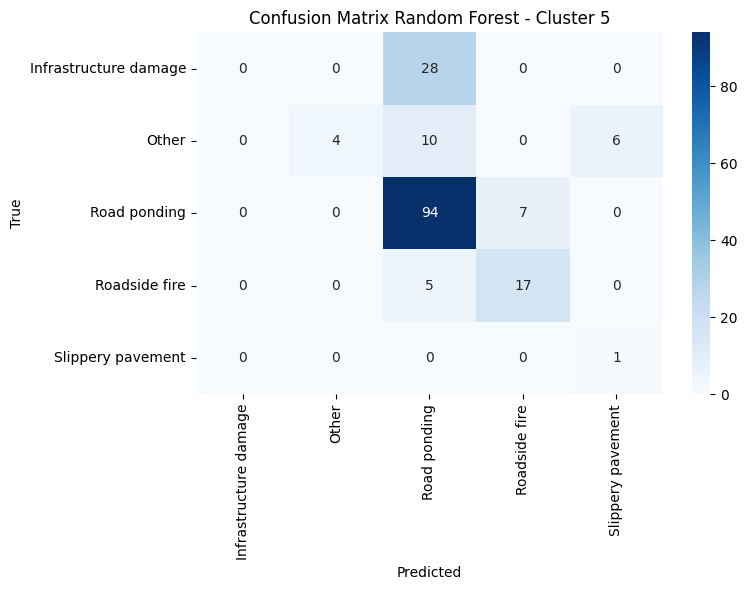


Feature Coefficients (Mean Absolute weight across classes):


,0
max_temp,0.166667
sum_prec (1h),0.166667
low_veg_%,0.166667
mid_high_veg_%,0.166667
pavement_%,0.166667
water_%,0.166667


In [ ]:
# Test the model

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = list(label_enc1_mapping.keys())

print('Evaluating on Test Set:')
y_true = y_test5 #CHANGE
y_pred = rf_model.predict(X_test5) #CHANGE

print(f'Test Accuracy: {accuracy_score(y_true, y_pred):.4f}')
print('Classification Report (Test Set):')
print(classification_report(y_true, y_pred, target_names=class_names))

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Random Forest - Cluster 5")
plt.tight_layout()
plt.show()


print("\nFeature Coefficients (Mean Absolute weight across classes):")
rf_model_importances = pd.Series(np.mean(np.abs(rf_model.feature_importances_), axis=0), index=features).sort_values(ascending=False)
display(rf_model_importances)

In [ ]:
#Bootstrapped evaluation metrics

from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd

# Initialize lists to store metrics
metrics_list = []

n_iterations = 10
sample_size = 4*len(y_test5) #CHANGE

# Ensure class_names is available, fallback to model classes if not
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {c}" for c in rf_model.classes_]

for i in range(n_iterations):
    # Bootstrap the test set
    X_test_boot, y_test_boot = resample(X_test5, y_test5, n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE

    # Predict using the trained rf_model
    y_pred_boot = rf_model.predict(X_test_boot)

    # Calculate general metrics
    precision = precision_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_test_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_test_boot, y_pred_boot)

    # Calculate per-class metrics
    precision_per_class = precision_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=rf_model.classes_)
    recall_per_class = recall_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=rf_model.classes_)

    # Build iteration dictionary
    iter_metrics = {
       'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

    # Add per-class metrics to the dictionary
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    # Append to list
    metrics_list.append(iter_metrics)

# Create a DataFrame to view and save the metrics
bootstrap_metrics_df = pd.DataFrame(metrics_list)
display(bootstrap_metrics_df)

# Report the mean and standard deviation of all evaluation metrics
mean_metrics = bootstrap_metrics_df.drop(columns=['iteration']).mean()
std_metrics = bootstrap_metrics_df.drop(columns=['iteration']).std()

summary_rf_df = pd.DataFrame({
    'Mean': mean_metrics,
    'Standard Deviation': std_metrics
})

print("\nMean and Standard Deviation of Evaluation Metrics (10 iterations):")
display(summary_rf_df)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,iteration,accuracy,balanced_accuracy,f1_score,precision,recall,precision_Infrastructure damage,recall_Infrastructure damage,precision_Other,recall_Other,precision_Road ponding,recall_Road ponding,precision_Roadside fire,recall_Roadside fire,precision_Slippery pavement,recall_Slippery pavement
0,1,0.668605,0.569856,0.588737,0.580340,0.668605,0.0,0.0,1.0,0.203390,0.666667,0.920398,0.698113,0.725490,0.266667,1.0
1,2,0.665698,0.565024,0.595129,0.619038,0.665698,0.0,0.0,1.0,0.176471,0.683060,0.928218,0.697917,0.720430,0.035714,1.0
2,3,0.645349,0.456667,0.567942,0.580296,0.645349,0.0,0.0,1.0,0.171053,0.655738,0.916031,0.682692,0.739583,0.000000,0.0
3,4,0.661337,0.582833,0.583105,0.586419,0.661337,0.0,0.0,1.0,0.237500,0.675090,0.916667,0.626374,0.760000,0.208333,1.0
4,5,0.643895,0.550676,0.570830,0.585393,0.643895,0.0,0.0,1.0,0.192308,0.666667,0.912718,0.627660,0.648352,0.100000,1.0
5,6,0.672965,0.571624,0.600963,0.626333,0.672965,0.0,0.0,1.0,0.164706,0.703704,0.922330,0.666667,0.771084,0.131579,1.0
6,7,0.667151,0.575453,0.590429,0.603255,0.667151,0.0,0.0,1.0,0.214286,0.678766,0.928040,0.677778,0.734940,0.206897,1.0
7,8,0.696221,0.581426,0.627465,0.643682,0.696221,0.0,0.0,1.0,0.223529,0.705244,0.942029,0.733333,0.741573,0.153846,1.0
8,9,0.662791,0.564653,0.590247,0.619717,0.662791,0.0,0.0,1.0,0.166667,0.680657,0.923267,0.680412,0.733333,0.071429,1.0
9,10,0.674419,0.592042,0.604237,0.624178,0.674419,0.0,0.0,1.0,0.236559,0.681467,0.921671,0.729730,0.801980,0.216216,1.0



Mean and Standard Deviation of Evaluation Metrics (10 iterations):


,Mean,Standard Deviation
accuracy,0.665843,0.014861
balanced_accuracy,0.561025,0.038412
f1_score,0.591908,0.017061
precision,0.606865,0.022728
recall,0.665843,0.014861
precision_Infrastructure damage,0.000000,0.000000
recall_Infrastructure damage,0.000000,0.000000
precision_Other,1.000000,0.000000
recall_Other,0.198647,0.028482
precision_Road ponding,0.679706,0.015564


In [ ]:
# Extract prediction probabilities for the test set
y_pred_probs_rf = rf_model.predict_proba(X_test5) #CHANGE

# Convert to a DataFrame for better readability
#rf_probs_df = pd.DataFrame(y_pred_probs_rf, columns=[f'Class {c}' for c in rf_model.classes_])
rf_probs_df = pd.DataFrame(y_pred_probs_rf, columns=[c for c in class_names])

rf_probs_df[100:110]

rf_probs_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_rf5.csv', header=True, index=True) #CHANGE NAME

# Optional: Save to CSV ----------- CHANGE NAME

summary_rf_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/rf_summary_metrics5.csv', index=True)

In [ ]:
y_pred_probs_rf

array([[6.49165949e-02, 2.56087725e-02, 8.79563652e-01, 1.80858787e-02,
        1.18251016e-02],
       [1.07027787e-01, 2.68414925e-02, 8.38055162e-01, 1.86636016e-02,
        9.41195743e-03],
       [6.49165949e-02, 2.56087725e-02, 8.79563652e-01, 1.80858787e-02,
        1.18251016e-02],
       [6.70577649e-02, 5.98426401e-02, 8.54109004e-01, 8.07990151e-03,
        1.09106891e-02],
       [6.49165949e-02, 2.56087725e-02, 8.79563652e-01, 1.80858787e-02,
        1.18251016e-02],
       [1.07027787e-01, 2.68414925e-02, 8.38055162e-01, 1.86636016e-02,
        9.41195743e-03],
       [6.70577649e-02, 5.98426401e-02, 8.54109004e-01, 8.07990151e-03,
        1.09106891e-02],
       [6.49165949e-02, 2.56087725e-02, 8.79563652e-01, 1.80858787e-02,
        1.18251016e-02],
       [1.07027787e-01, 2.68414925e-02, 8.38055162e-01, 1.86636016e-02,
        9.41195743e-03],
       [6.70577649e-02, 5.98426401e-02, 8.54109004e-01, 8.07990151e-03,
        1.09106891e-02],
       [6.49165949e-02, 2.5608

LR training

In [ ]:
#LR trained on SGD, 100 epochs, Softmax probabilities as class outputs

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, f1_score

# Initialize the SGDClassifier with logistic regression loss (log_loss)
lr_model = SGDClassifier(loss='log_loss', max_iter=100,         # 100 epochs
        learning_rate="optimal",
        verbose=0,
        random_state=42)

In [ ]:
import optuna
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score

def objective_lr(trial):
    # --- Define search space ---
    penalty = trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet'])
    alpha = trial.suggest_float('alpha', 1e-6, 1e-1, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0) # Used if penalty='elasticnet'
    learning_rate = trial.suggest_categorical('learning_rate', ['constant', 'optimal', 'invscaling', 'adaptive'])
    eta0 = trial.suggest_float('eta0', 1e-5, 1e-1, log=True) # Required for constant, invscaling, adaptive

    # Build model using selected hyperparameters
    model = SGDClassifier(
        loss='log_loss',
        max_iter=100,
        penalty=penalty,
        alpha=alpha,
        l1_ratio=l1_ratio,
        learning_rate=learning_rate,
        eta0=eta0,
        random_state=42,
        verbose=0
    )

    # Fit on training data
    model.fit(X_train5, y_train5) #CHANGE

    # Return the validation log loss achieved in this trial
    y_val_pred_probs = model.predict_proba(X_val5) #CHANGE
    val_loss = log_loss(y_val5, y_val_pred_probs, labels=model.classes_) #CHANGE

    y_val_pred = model.predict(X_val5) #CHANGE
    val_acc = accuracy_score(y_val5, y_val_pred) #CHANGE

    trial.set_user_attr('accuracy', val_acc)
    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_lr = optuna.create_study(direction='minimize')
study_lr.optimize(objective_lr, n_trials=20) # Adjust n_trials as needed

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_lr.best_trial.params)
print("Best validation loss:", study_lr.best_value)
print("Best validation accuracy:", study_lr.best_trial.user_attrs['accuracy'])

[I 2026-07-22 16:30:45,099] A new study created in memory with name: no-name-d5646713-eb2c-46da-87b8-8b3b87578cb0
[I 2026-07-22 16:30:45,123] Trial 0 finished with value: 1.1752215469089367 and parameters: {'penalty': 'l2', 'alpha': 0.00025827273227426194, 'l1_ratio': 0.916233419167522, 'learning_rate': 'invscaling', 'eta0': 0.023465399821258334}. Best is trial 0 with value: 1.1752215469089367.
[I 2026-07-22 16:30:45,139] Trial 1 finished with value: 1.1644491020284944 and parameters: {'penalty': 'elasticnet', 'alpha': 0.07515697887857369, 'l1_ratio': 0.41581559522555156, 'learning_rate': 'optimal', 'eta0': 0.02298809970315922}. Best is trial 1 with value: 1.1644491020284944.
[I 2026-07-22 16:30:45,157] Trial 2 finished with value: 1.154874946526851 and parameters: {'penalty': 'elasticnet', 'alpha': 0.0015466159010226665, 'l1_ratio': 0.19070142396346745, 'learning_rate': 'optimal', 'eta0': 0.0007296433600237481}. Best is trial 2 with value: 1.154874946526851.
[I 2026-07-22 16:30:45,177

Trial 0 finished with val_loss: 1.1752 and val_accuracy: 0.5000
Trial 1 finished with val_loss: 1.1644 and val_accuracy: 0.5000
Trial 2 finished with val_loss: 1.1549 and val_accuracy: 0.5306
Trial 3 finished with val_loss: 1.2419 and val_accuracy: 0.5306
Trial 4 finished with val_loss: 1.6088 and val_accuracy: 0.5000
Trial 5 finished with val_loss: 1.3842 and val_accuracy: 0.5000
Trial 6 finished with val_loss: 1.1283 and val_accuracy: 0.5000
Trial 7 finished with val_loss: 1.3152 and val_accuracy: 0.5102
Trial 8 finished with val_loss: 1.2345 and val_accuracy: 0.5612
Trial 9 finished with val_loss: 1.1363 and val_accuracy: 0.5000


[I 2026-07-22 16:30:45,353] Trial 10 finished with value: 1.1645255948424134 and parameters: {'penalty': 'elasticnet', 'alpha': 1.260523285496634e-06, 'l1_ratio': 0.032020359151835154, 'learning_rate': 'constant', 'eta0': 0.00019751144721679356}. Best is trial 6 with value: 1.1282939544312047.
[I 2026-07-22 16:30:45,380] Trial 11 finished with value: 1.0727404702669598 and parameters: {'penalty': 'l1', 'alpha': 5.041271561147528e-06, 'l1_ratio': 0.6844784221442783, 'learning_rate': 'constant', 'eta0': 0.0048838991719187975}. Best is trial 11 with value: 1.0727404702669598.
[I 2026-07-22 16:30:45,409] Trial 12 finished with value: 1.079137051918851 and parameters: {'penalty': 'l1', 'alpha': 1.1081457038770805e-06, 'l1_ratio': 0.672438587658383, 'learning_rate': 'constant', 'eta0': 0.0037855290917493205}. Best is trial 11 with value: 1.0727404702669598.
[I 2026-07-22 16:30:45,443] Trial 13 finished with value: 1.0912452577929614 and parameters: {'penalty': 'l1', 'alpha': 1.72086552146959

Trial 10 finished with val_loss: 1.1645 and val_accuracy: 0.5000
Trial 11 finished with val_loss: 1.0727 and val_accuracy: 0.5306
Trial 12 finished with val_loss: 1.0791 and val_accuracy: 0.5306
Trial 13 finished with val_loss: 1.0912 and val_accuracy: 0.5306
Trial 14 finished with val_loss: 1.1010 and val_accuracy: 0.5306
Trial 15 finished with val_loss: 1.1632 and val_accuracy: 0.5000


[I 2026-07-22 16:30:45,558] Trial 16 finished with value: 1.081173834456787 and parameters: {'penalty': 'l1', 'alpha': 6.3708461358933184e-06, 'l1_ratio': 0.7603534461806916, 'learning_rate': 'adaptive', 'eta0': 0.004163951234199731}. Best is trial 11 with value: 1.0727404702669598.
[I 2026-07-22 16:30:45,587] Trial 17 finished with value: 1.1301315818075757 and parameters: {'penalty': 'l1', 'alpha': 2.8476863829126885e-05, 'l1_ratio': 0.5434365628332637, 'learning_rate': 'constant', 'eta0': 0.0007469326119597142}. Best is trial 11 with value: 1.0727404702669598.
[I 2026-07-22 16:30:45,616] Trial 18 finished with value: 1.0531162903496913 and parameters: {'penalty': 'l1', 'alpha': 3.044514928999488e-06, 'l1_ratio': 0.8557793925867793, 'learning_rate': 'constant', 'eta0': 0.008088802579564411}. Best is trial 18 with value: 1.0531162903496913.
[I 2026-07-22 16:30:45,650] Trial 19 finished with value: 1.0457834229122442 and parameters: {'penalty': 'l1', 'alpha': 2.111491348459157e-05, 'l1

Trial 16 finished with val_loss: 1.0812 and val_accuracy: 0.5306
Trial 17 finished with val_loss: 1.1301 and val_accuracy: 0.5000
Trial 18 finished with val_loss: 1.0531 and val_accuracy: 0.5306
Trial 19 finished with val_loss: 1.0458 and val_accuracy: 0.5306

Optimization finished.
Best trial (lowest loss): {'penalty': 'l1', 'alpha': 2.111491348459157e-05, 'l1_ratio': 0.8452016100450006, 'learning_rate': 'constant', 'eta0': 0.010732702938466792}
Best validation loss: 1.0457834229122442
Best validation accuracy: 0.5306122448979592


In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'penalty': 'elasticnet', 'alpha': 2.8168923056317686e-05, 'l1_ratio': 0.8161201163720578, 'learning_rate': 'adaptive', 'eta0': 0.0006995272770599538}
#Best validation loss: 1.2899366724751191
#Best validation accuracy: 0.5309734513274337

#Cluster 2
#Best trial (lowest loss): {'penalty': 'elasticnet', 'alpha': 0.00028954597386309514, 'l1_ratio': 0.9824386406851959, 'learning_rate': 'adaptive', 'eta0': 0.08648416073863789}
#Best validation loss: 0.8235626673636007
#Best validation accuracy: 0.703921568627451

#Cluster 3
#Best trial (lowest loss): {'penalty': 'l1', 'alpha': 1.0361613932749564e-06, 'l1_ratio': 0.2519074073951868, 'learning_rate': 'constant', 'eta0': 0.08681110487513591}
#Best validation loss: 0.7588827144339128
#Best validation accuracy: 0.6903225806451613

#Cluster 4
#Best trial (lowest loss): {'penalty': 'l1', 'alpha': 3.4203069671194464e-05, 'l1_ratio': 0.5706869578544304, 'learning_rate': 'adaptive', 'eta0': 0.09801272612009858}
#Best validation loss: 1.0873906414673327
#Best validation accuracy: 0.4657210401891253

#Cluster 5
#Best trial (lowest loss): {'penalty': 'l1', 'alpha': 8.985239316546958e-06, 'l1_ratio': 0.6149814037287574, 'learning_rate': 'adaptive', 'eta0': 0.09946065782743728}
#Best validation loss: 1.0179610651001718
#Best validation accuracy: 0.5306122448979592

In [ ]:
#Compile model with new parameters

lr_model = SGDClassifier(loss='log_loss',
        max_iter=100,
        penalty='l1',
        alpha=0,
        l1_ratio=0.6149814037287574,
        learning_rate='adaptive',
        eta0=0.09946065782743728)

# Train the model
print('Training Logistic Regression (SGD) model...')
lr_model.fit(X_train5, y_train5) #CHANGE

# Validate the model
print('\nEvaluating on Validation Set:')
y_val_pred_lr = lr_model.predict(X_val5) #CHANGE
print(f'Validation Accuracy: {accuracy_score(y_val5, y_val_pred_lr):.4f}') #CHANGE

Training Logistic Regression (SGD) model...

Evaluating on Validation Set:
Validation Accuracy: 0.5306


LR testing + evaluation metrics

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluating on Test Set:
Test Accuracy: 0.6570

Classification Report (Test Set):
                       precision    recall  f1-score   support

Infrastructure damage       0.00      0.00      0.00        28
                Other       0.00      0.00      0.00        20
         Road ponding       0.68      0.90      0.77       101
        Roadside fire       0.71      1.00      0.83        22
    Slippery pavement       0.00      0.00      0.00         1

             accuracy                           0.66       172
            macro avg       0.28      0.38      0.32       172
         weighted avg       0.49      0.66      0.56       172

Balanced Accuracy on Test Set: 0.3802
Weighted F1 Score on Test Set: 0.5610


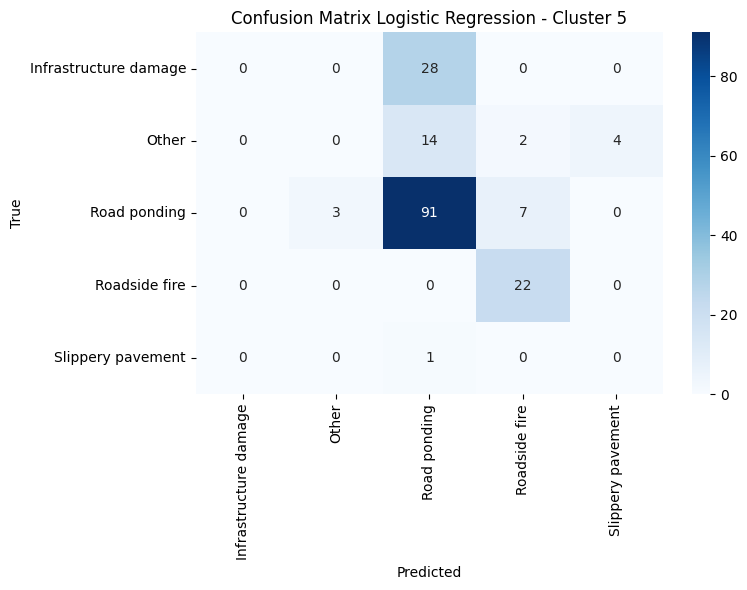

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, balanced_accuracy_score, f1_score
import numpy as np

# Get the actual class names from the label encoder mapping
class_names = list(label_enc1_mapping.keys())

# Test the model
print('\nEvaluating on Test Set:')
y_true_lr = y_test5 #CHANGE
y_pred_lr = lr_model.predict(X_test5) #CHANGE


print(f'Test Accuracy: {accuracy_score(y_true_lr, y_pred_lr):.4f}')
print('\nClassification Report (Test Set):')
print(classification_report(y_true_lr, y_pred_lr, target_names=class_names))

# Balanced Accuracy
balanced_acc_lr = balanced_accuracy_score(y_true_lr, y_pred_lr)
print(f"Balanced Accuracy on Test Set: {balanced_acc_lr:.4f}")

# Weighted F1 Score
w_f1_score_lr = f1_score(y_true_lr, y_pred_lr, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score_lr:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true_lr, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Logistic Regression - Cluster 5")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd

# Initialize lists to store metrics
metrics_list_lr = []

n_iterations = 10
sample_size = 4*len(y_test5) #CHANGE

# Ensure class_names is available, fallback to model classes if not
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {c}" for c in lr_model.classes_]

for i in range(n_iterations):
    # Bootstrap the test set
    X_test_boot, y_test_boot = resample(X_test5, y_test5, n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE

    # Predict using the trained lr_model
    y_pred_boot = lr_model.predict(X_test_boot)

    # Calculate general metrics
    precision = precision_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_test_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_test_boot, y_pred_boot)

    # Calculate per-class metrics
    precision_per_class = precision_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=lr_model.classes_)
    recall_per_class = recall_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=lr_model.classes_)

    # Build iteration dictionary
    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

    # Add per-class metrics to the dictionary
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    # Append to list
    metrics_list_lr.append(iter_metrics)

# Create a DataFrame to view and save the metrics
bootstrap_metrics_lr_df = pd.DataFrame(metrics_list_lr)
display(bootstrap_metrics_lr_df)

# Report the mean and standard deviation of all evaluation metrics
mean_metrics = bootstrap_metrics_lr_df.drop(columns=['iteration']).mean()
std_metrics = bootstrap_metrics_lr_df.drop(columns=['iteration']).std()

summary_lr_df = pd.DataFrame({
    'Mean': mean_metrics,
    'Standard Deviation': std_metrics
})

print("\nMean and Standard Deviation of Evaluation Metrics (10 iterations):")
display(summary_lr_df)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,iteration,accuracy,balanced_accuracy,f1_score,precision,recall,precision_Infrastructure damage,recall_Infrastructure damage,precision_Other,recall_Other,precision_Road ponding,recall_Road ponding,precision_Roadside fire,recall_Roadside fire,precision_Slippery pavement,recall_Slippery pavement
0,1,0.662791,0.376119,0.573576,0.505927,0.662791,0.0,0.0,0.0,0.0,0.687379,0.880597,0.703448,1.0,0.0,0.0
1,2,0.664244,0.380198,0.569485,0.498472,0.664244,0.0,0.0,0.0,0.0,0.682927,0.900990,0.720930,1.0,0.0,0.0
2,3,0.643895,0.470738,0.546876,0.475342,0.643895,0.0,0.0,0.0,0.0,0.658444,0.882952,0.711111,1.0,0.0,0.0
3,4,0.633721,0.376961,0.537327,0.467208,0.633721,0.0,0.0,0.0,0.0,0.671004,0.884804,0.635593,1.0,0.0,0.0
4,5,0.649709,0.377556,0.553221,0.482139,0.649709,0.0,0.0,0.0,0.0,0.674242,0.887781,0.674074,1.0,0.0,0.0
5,6,0.651163,0.377184,0.558327,0.489027,0.651163,0.0,0.0,0.0,0.0,0.678439,0.885922,0.685950,1.0,0.0,0.0
6,7,0.646802,0.379653,0.549354,0.477530,0.646802,0.0,0.0,0.0,0.0,0.670370,0.898263,0.703390,1.0,0.0,0.0
7,8,0.681686,0.383575,0.590018,0.520185,0.681686,0.0,0.0,0.0,0.0,0.707635,0.917874,0.729508,1.0,0.0,0.0
8,9,0.659884,0.380198,0.562774,0.490834,0.659884,0.0,0.0,0.0,0.0,0.681648,0.900990,0.692308,1.0,0.0,0.0
9,10,0.640988,0.377546,0.545463,0.474813,0.640988,0.0,0.0,0.0,0.0,0.665362,0.887728,0.711268,1.0,0.0,0.0



Mean and Standard Deviation of Evaluation Metrics (10 iterations):


,Mean,Standard Deviation
accuracy,0.653488,0.013911
balanced_accuracy,0.387973,0.029164
f1_score,0.558642,0.015721
precision,0.488148,0.016283
recall,0.653488,0.013911
precision_Infrastructure damage,0.000000,0.000000
recall_Infrastructure damage,0.000000,0.000000
precision_Other,0.000000,0.000000
recall_Other,0.000000,0.000000
precision_Road ponding,0.677745,0.013609


In [ ]:
# Extract prediction probabilities for the test set (Logistic Regression)
y_pred_probs_lr = lr_model.predict_proba(X_test5) #CHANGE

# Convert to a DataFrame for better readability
lr_probs_df = pd.DataFrame(y_pred_probs_lr, columns=class_names)

# Display the first 10 rows
display(lr_probs_df.head(10))

# Optional: Save to CSV
lr_probs_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lr5.csv', header=True, index=True)

# Optional: Save to CSV

summary_lr_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/lr_summary_metrics5.csv', index=True)

,Infrastructure damage,Other,Road ponding,Roadside fire,Slippery pavement
0,0.044283,0.008793,0.946597,1.375041e-08,0.000326
1,0.037921,0.005950,0.955972,8.769870e-10,0.000157
2,0.044283,0.008793,0.946597,1.375041e-08,0.000326
3,0.095789,0.026290,0.877497,9.357547e-05,0.000330
4,0.044283,0.008793,0.946597,1.375041e-08,0.000326
5,0.037921,0.005950,0.955972,8.769870e-10,0.000157
6,0.095789,0.026290,0.877497,9.357547e-05,0.000330
7,0.044283,0.008793,0.946597,1.375041e-08,0.000326
8,0.037921,0.005950,0.955972,8.769870e-10,0.000157
9,0.095789,0.026290,0.877497,9.357547e-05,0.000330


XGBoost training

In [ ]:
#Model definition

import xgboost as xgb
from sklearn.metrics import accuracy_score

# Initialize the XGBoost model with base parameters for multiclass classification
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                              verbosity=2)

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import log_loss, accuracy_score

def objective_xgb(trial):
    # --- Define search space ---
    param = {
        'n_estimators': trial.suggest_categorical('n_estimators', [50, 100, 250, 500]),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'verbosity': 0
    }

    # Build model using selected hyperparameters
    model = xgb.XGBClassifier(**param)

    # Fit on training data with early stopping based on val_loss
    model.fit(
        X_train5, y_train5, #CHANGE
        eval_set=[(X_val5, y_val5)], #CHANGE
        verbose=False
    )

    # Return the validation log loss achieved in this trial
    y_val_pred_probs = model.predict_proba(X_val5) #CHANGE
    val_loss = log_loss(y_val5, y_val_pred_probs, labels=model.classes_) #CHANGE

    y_val_pred = model.predict(X_val5) #CHANGE
    val_acc = accuracy_score(y_val5, y_val_pred) #CHANGE

    trial.set_user_attr('accuracy', val_acc)
    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20) # Adjust n_trials as needed based on compute limits

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_xgb.best_trial.params)
print("Best validation loss:", study_xgb.best_value)
print("Best validation accuracy:", study_xgb.best_trial.user_attrs['accuracy'])


[I 2026-07-22 16:30:47,541] A new study created in memory with name: no-name-87e33c0f-85b1-4d3a-ba1f-7372be77f50e
[I 2026-07-22 16:30:51,911] Trial 0 finished with value: 1.0814677569821836 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.005142729241731774, 'subsample': 0.6242404562155838, 'colsample_bytree': 0.7180778810196224}. Best is trial 0 with value: 1.0814677569821836.


Trial 0 finished with val_loss: 1.0815 and val_accuracy: 0.4796


[I 2026-07-22 16:30:52,675] Trial 1 finished with value: 1.9057578757583837 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.043736516728185786, 'subsample': 0.9909949812695938, 'colsample_bytree': 0.6953855275710041}. Best is trial 0 with value: 1.0814677569821836.


Trial 1 finished with val_loss: 1.9058 and val_accuracy: 0.6122


[I 2026-07-22 16:30:52,886] Trial 2 finished with value: 1.1497025858877012 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.02465174065728856, 'subsample': 0.5266385638464861, 'colsample_bytree': 0.7993486122551591}. Best is trial 0 with value: 1.0814677569821836.


...

Trial 5 finished with val_loss: 1.1976 and val_accuracy: 0.5000
Trial 6 finished with val_loss: 1.2377 and val_accuracy: 0.5000


[I 2026-07-22 16:30:54,141] Trial 7 finished with value: 1.1593118839000964 and parameters: {'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.013133380597632648, 'subsample': 0.9387452672396488, 'colsample_bytree': 0.857627673844926}. Best is trial 0 with value: 1.0814677569821836.


Trial 7 finished with val_loss: 1.1593 and val_accuracy: 0.4796


[W 2026-07-22 16:30:54,523] Trial 8 failed with parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.04800673437032366, 'subsample': 0.8434163147725433, 'colsample_bytree': 0.6519117088725734} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_7144/3571580241.py", line 22, in objective_xgb
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py", line 1807, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/xgboost/core.py", line 553, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3

KeyboardInterrupt: 

In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01610992548592057, 'subsample': 0.8643694562308952, 'colsample_bytree': 0.9921509534664766}
#Best validation loss: 1.3181866598370222
#Best validation accuracy: 0.5309734513274337

#Cluster 2
#Best trial (lowest loss): {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.006721163672091264, 'subsample': 0.8959949343364703, 'colsample_bytree': 0.8743641171588206}
#Best validation loss: 0.7987828537479061
#Best validation accuracy: 0.6901960784313725

#Cluster 3
#Best trial (lowest loss): {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.002765860875855895, 'subsample': 0.6941667869563821, 'colsample_bytree': 0.7407102272564239}
#Best validation loss: 0.9156966666921357
#Best validation accuracy: 0.6989247311827957

#Cluster 4
#Best trial (lowest loss): {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.0557706875334531, 'subsample': 0.8535586260241167, 'colsample_bytree': 0.8771172603746542}
#Best validation loss: 1.0880780500071268
#Best validation accuracy: 0.5271867612293144

#Cluster 5
#Best trial (lowest loss): {'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.013330987361907425, 'subsample': 0.7505107046407022, 'colsample_bytree': 0.9059914513419177}
#Best validation loss: 1.131237726956735
#Best validation accuracy: 0.5408163265306123

In [ ]:
#Compile model with new parameters
xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss',
                              verbosity=2,
                              n_estimators=250,
                              max_depth=5,
                              learning_rate=0.013330987361907425,
                              subsample=0.7505107046407022,
                              colsample_bytree=0.9059914513419177)

# Train the model
print('Training XGBoost model...')
xgb_model.fit(X_train5, y_train5) #CHANGE

# Validate the model
print('\nEvaluating on Validation Set:')
y_val_pred_xgb = xgb_model.predict(X_val5) #CHANGE
print(f'Validation Accuracy: {accuracy_score(y_val5, y_val_pred_xgb):.4f}') #CHANGE

XGBoost testing + evaluation metrics

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score

print('\nEvaluating on Test Set:')
y_true_xgb = y_test5 #CHANGE
y_pred_xgb = xgb_model.predict(X_test5) #CHANGE

print(f'Test Accuracy: {accuracy_score(y_true_xgb, y_pred_xgb):.4f}')
print('\nClassification Report (Test Set):')
print(classification_report(y_true_xgb, y_pred_xgb, target_names=class_names))

# Balanced Accuracy
balanced_acc_xgb = balanced_accuracy_score(y_true_xgb, y_pred_xgb)
print(f"Balanced Accuracy on Test Set: {balanced_acc_xgb:.4f}")

# Weighted F1 Score
w_f1_score_xgb = f1_score(y_true_xgb, y_pred_xgb, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score_xgb:.4f}")


# Confusion Matrix
cm = confusion_matrix(y_true_xgb, y_pred_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix XGBoost - Cluster 5")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd

# Initialize lists to store metrics
metrics_list_xgb = []

n_iterations = 10
sample_size = 4*len(y_test5) #CHANGE

# Ensure class_names is available, fallback to model classes if not
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {c}" for c in xgb_model.classes_]

for i in range(n_iterations):
    # Bootstrap the test set
    X_test_boot, y_test_boot = resample(X_test5, y_test5, n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE

    # Predict using the trained xgb_model
    y_pred_boot = xgb_model.predict(X_test_boot)

    # Calculate general metrics
    precision = precision_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_test_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_test_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_test_boot, y_pred_boot)

    # Calculate per-class metrics
    precision_per_class = precision_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=xgb_model.classes_)
    recall_per_class = recall_score(y_test_boot, y_pred_boot, average=None, zero_division=0, labels=xgb_model.classes_)

    # Build iteration dictionary
    iter_metrics = {
       'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    # Add per-class metrics to the dictionary
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    # Append to list
    metrics_list_xgb.append(iter_metrics)

# Create a DataFrame to view and save the metrics
bootstrap_metrics_xgb_df = pd.DataFrame(metrics_list_xgb)
display(bootstrap_metrics_xgb_df)

# Report the mean and standard deviation of all evaluation metrics
mean_metrics = bootstrap_metrics_xgb_df.drop(columns=['iteration']).mean()
std_metrics = bootstrap_metrics_xgb_df.drop(columns=['iteration']).std()

summary_xgb_df = pd.DataFrame({
    'Mean': mean_metrics,
    'Standard Deviation': std_metrics
})

print("\nMean and Standard Deviation of Evaluation Metrics (10 iterations):")
display(summary_xgb_df)


In [ ]:
import pandas as pd

# Extract prediction probabilities for the test set
y_pred_probs_xgb = xgb_model.predict_proba(X_test5) #CHANGE

# Convert to a DataFrame for better readability using class names
xgb_probs_df = pd.DataFrame(y_pred_probs_xgb, columns=class_names)

# Display the first 10 rows
display(xgb_probs_df.head(10))

# Optional: Save to CSV
xgb_probs_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_xgb5.csv', header=True, index=True)

# Optional: Save to CSV

summary_xgb_df.to_csv('drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/xgb_summary_metrics5.csv', index=True)

# Preprocessing for spatial and temporal models

Adjacency matrix generation - spatial similarity

In [ ]:
#Calculate spatial distance using Haversine #LOAD THEM FOR NEXT TIME

#!pip install haversine
#from haversine import haversine, Unit

#n1 = len(coords1)
#spatial_dist1 = np.zeros((n1, n1))

#for i in range(n1):
#    for j in range(n1):
#        if i != j:
#            spatial_dist1[i, j] = haversine(tuple(coords1.iloc[i]), tuple(coords1.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist_suburban = pd.DataFrame(spatial_dist1)
#spatial_dist_suburban.to_csv('drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_suburban.csv', header=True, index=True)

#n2 = len(coords2)
#spatial_dist2 = np.zeros((n2, n2))

#for i in range(n2):
#    for j in range(n2):
#        if i != j:
#            spatial_dist2[i, j] = haversine(tuple(coords2.iloc[i]), tuple(coords2.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist_ams_ut = pd.DataFrame(spatial_dist2)
#spatial_dist_ams_ut.to_csv('drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_ams_ut.csv', header=True, index=True)


#n3 = len(coords3)
#spatial_dist3 = np.zeros((n3, n3))

#for i in range(n3):
#    for j in range(n3):
#        if i != j:
#            spatial_dist3[i, j] = haversine(tuple(coords3.iloc[i]), tuple(coords3.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist_dh_rot = pd.DataFrame(spatial_dist3)
#spatial_dist_dh_rot.to_csv('drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_dh_rot.csv', header=True, index=True)

#n4 = len(coords4)
#spatial_dist4 = np.zeros((n4, n4))

#for i in range(n4):
#    for j in range(n4):
#        if i != j:
#            spatial_dist4[i, j] = haversine(tuple(coords4.iloc[i]), tuple(coords4.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist_outlier = pd.DataFrame(spatial_dist4)
#spatial_dist_outlier.to_csv('drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_outlier.csv', header=True, index=True)


#n5 = len(coords5)
#spatial_dist5 = np.zeros((n5, n5))

#for i in range(n5):
#    for j in range(n5):
#        if i != j:
#            spatial_dist5[i, j] = haversine(tuple(coords5.iloc[i]), tuple(coords5.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist_limburg = pd.DataFrame(spatial_dist5)
#spatial_dist_limburg.to_csv('drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_limburg.csv', header=True, index=True)



In [ ]:
spatial_dist1 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_suburban.csv")
spatial_dist1 = spatial_dist1.drop(columns=['Unnamed: 0'])

spatial_dist2 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_ams_ut.csv")
spatial_dist2 = spatial_dist2.drop(columns=['Unnamed: 0'])

spatial_dist3 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_dh_rot.csv")
spatial_dist3 = spatial_dist3.drop(columns=['Unnamed: 0'])

spatial_dist4 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_outlier.csv")
spatial_dist4 = spatial_dist4.drop(columns=['Unnamed: 0'])

spatial_dist5 = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/new_spatial_dist_limburg.csv")
spatial_dist5 = spatial_dist5.drop(columns=['Unnamed: 0'])

In [ ]:
print("Cluster 1 (Suburban regions) spatial distance matrix shape:", spatial_dist1.shape)
print("Cluster 2 (Amsterdam-Utrecht) spatial distance matrix shape:", spatial_dist2.shape)
print("Cluster 3 (Randstad) spatial distance matrix shape:", spatial_dist3.shape)
print("Cluster 4 (Outskirts) spatial distance matrix shape:", spatial_dist4.shape)
print("Cluster 5 (Limburg) spatial distance matrix shape:", spatial_dist5.shape)

In [ ]:
#Convert to similarity (Exponential decay)

spatial_sim1 = np.exp(-spatial_dist1 / spatial_dist1.std())
spatial_sim2 = np.exp(-spatial_dist2 / spatial_dist2.std())
spatial_sim3 = np.exp(-spatial_dist3 / spatial_dist3.std())
spatial_sim4 = np.exp(-spatial_dist4 / spatial_dist4.std())
spatial_sim5 = np.exp(-spatial_dist5 / spatial_dist5.std())

In [ ]:
attributes1

In [ ]:
print("Cluster 1 (Suburban regions) spatial similarity matrix shape:", spatial_sim1.shape)
print("Cluster 2 (Amsterdam-Utrecht) spatial similarity matrix shape:", spatial_sim2.shape)
print("Cluster 3 (Randstad) spatial similarity matrix shape:", spatial_sim3.shape)
print("Cluster 4 (Outskirts) spatial similarity matrix shape:", spatial_sim4.shape)
print("Cluster 5 (Limburg) spatial similarity matrix shape:", spatial_sim5.shape)

Adding contextual similarity (Cosine similarity)

In [ ]:
#Attribute similarity using Cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

attr_sim1 = cosine_similarity(attributes1)
attr_sim2 = cosine_similarity(attributes2)
attr_sim3 = cosine_similarity(attributes3)
attr_sim4 = cosine_similarity(attributes4)
attr_sim5 = cosine_similarity(attributes5)

In [ ]:
#Check for negative values - No negative values, so no opposities, only similarities (good news)
print(attr_sim1[attr_sim1<0])
print(attr_sim2[attr_sim2<0])
print(attr_sim3[attr_sim3<0])
print(attr_sim4[attr_sim4<0])
print(attr_sim5[attr_sim5<0])

In [ ]:
print("Attr. matrix cluster 1 shape:", attr_sim1.shape)
print("Attr. matrix cluster 2 shape:", attr_sim2.shape)
print("Attr. matrix cluster 3 shape:", attr_sim3.shape)
print("Attr. matrix cluster 4 shape:", attr_sim4.shape)
print("Attr. matrix cluster 5 shape:", attr_sim5.shape)

In [ ]:
attr_sim1[0]

In [ ]:
#Combine spatial + attribute similarities - Weighted sum or product (tunable hyperparameter alpha):

alpha = 0.5  # weight for spatial vs attribute
combined_sim1 = alpha * spatial_sim1 + (1 - alpha) * attr_sim1
combined_sim2 = alpha * spatial_sim2 + (1 - alpha) * attr_sim2
combined_sim3 = alpha * spatial_sim3 + (1 - alpha) * attr_sim3
combined_sim4 = alpha * spatial_sim4 + (1 - alpha) * attr_sim4
combined_sim5 = alpha * spatial_sim5 + (1 - alpha) * attr_sim5

In [ ]:
#Weighted adjacency matrix

threshold = 0.8
combined_sim1[combined_sim1 < threshold] = 0 #All points less than the threshold are 0
combined_sim2[combined_sim2 < threshold] = 0
combined_sim3[combined_sim3 < threshold] = 0
combined_sim4[combined_sim4 < threshold] = 0
combined_sim5[combined_sim5 < threshold] = 0

A1 = combined_sim1.copy()
A2 = combined_sim2.copy()
A3 = combined_sim3.copy()
A4 = combined_sim4.copy()
A5 = combined_sim5.copy()

In [ ]:
A1.shape, A2.shape, A3.shape, A4.shape, A5.shape

In [ ]:
#Add self loops

from spektral.utils import add_self_loops

A_np1 = A1.to_numpy()
A_with_loops1 = add_self_loops(A_np1)

A_np2 = A2.to_numpy()
A_with_loops2 = add_self_loops(A_np2)

A_np3 = A3.to_numpy()
A_with_loops3 = add_self_loops(A_np3)

A_np4 = A4.to_numpy()
A_with_loops4 = add_self_loops(A_np4)

A_np5 = A5.to_numpy()
A_with_loops5 = add_self_loops(A_np5)

print(A_with_loops1.shape)
print(A_with_loops2.shape)
print(A_with_loops3.shape)
print(A_with_loops4.shape)
print(A_with_loops5.shape)

In [ ]:
A_with_loops1[1:10]

In [ ]:
#Preprocessing the adjacency matrix
from spektral.utils import add_self_loops, normalized_adjacency, gcn_filter

# Normalize adjacency
A_with_loops1 = gcn_filter(A_with_loops1).astype("float32")
A_with_loops2 = gcn_filter(A_with_loops2).astype("float32")
A_with_loops3 = gcn_filter(A_with_loops3).astype("float32")
A_with_loops4 = gcn_filter(A_with_loops4).astype("float32")
A_with_loops5 = gcn_filter(A_with_loops5).astype("float32")

from scipy.sparse import csr_matrix

# Convert the dense numpy array to a CSR sparse matrix
A_sparse1 = csr_matrix(A_with_loops1)
A_sparse2 = csr_matrix(A_with_loops2)
A_sparse3 = csr_matrix(A_with_loops3)
A_sparse4 = csr_matrix(A_with_loops4)
A_sparse5 = csr_matrix(A_with_loops5)

print(A_sparse1.shape)
print(A_sparse2.shape)
print(A_sparse3.shape)
print(A_sparse4.shape)
print(A_sparse5.shape)
#print(A_sparse)

In [ ]:
#Visualization weighted adjacency matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(combined_sim1.iloc[50:70, 50:70], annot=True, cmap="Blues")
plt.title("Weighted Adjacency Matrix")
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

C = A1.iloc[50:70, 50:70].to_numpy()
G = nx.from_numpy_array(C)
nx.draw(G, with_labels=False, node_color='lightblue')
plt.title("Graph structure from adjacency matrix")
plt.show()

Degree matrices

In [ ]:
# Generate the degree matrix
# The degree matrix is a diagonal matrix where the diagonal elements are the sum of the corresponding rows of the adjacency matrix.
D1 = np.diag(np.sum(A_with_loops1, axis=1))
print(D1.shape)
D2 = np.diag(np.sum(A_with_loops2, axis=1))
print(D2.shape)
D3 = np.diag(np.sum(A_with_loops3, axis=1))
print(D3.shape)
D4 = np.diag(np.sum(A_with_loops4, axis=1))
print(D4.shape)
D5 = np.diag(np.sum(A_with_loops5, axis=1))
print(D5.shape)

X and y matrices

In [ ]:
y1 = output1
y2 = output2
y3 = output3
y4 = output4
y5 = output5

features_com1 = np.hstack([attributes1])#, spatial1])
features_com2 = np.hstack([attributes2])#, spatial2])
features_com3 = np.hstack([attributes3])#, spatial3])
features_com4 = np.hstack([attributes4])#, spatial4])
features_com5 = np.hstack([attributes5])#, spatial5])

X1 = features_com1
X2 = features_com2
X3 = features_com3
X4 = features_com4
X5 = features_com5

print("Cluster 1 shapes:", y1.shape, X1.shape)
print("Cluster 2 shapes:", y2.shape, X2.shape)
print("Cluster 3 shapes:", y3.shape, X3.shape)
print("Cluster 4 shapes:", y4.shape, X4.shape)
print("Cluster 5 shapes:", y5.shape, X5.shape)

In [ ]:
#One hot encoding for GAT

y_one_hot1 = tf.keras.utils.to_categorical(y1, num_classes=5)
print(y_one_hot1.shape)
y_one_hot2 = tf.keras.utils.to_categorical(y2, num_classes=5)
print(y_one_hot2.shape)
y_one_hot3 = tf.keras.utils.to_categorical(y3, num_classes=5)
print(y_one_hot3.shape)
y_one_hot4 = tf.keras.utils.to_categorical(y4, num_classes=5)
print(y_one_hot4.shape)
y_one_hot5 = tf.keras.utils.to_categorical(y5, num_classes=5)
print(y_one_hot5.shape)

In [ ]:
y5.unique()

SingleMode dataloader (create graphs)

In [ ]:
from spektral.data import Graph, Dataset

#Create Spektral dataset

from spektral.data import Dataset, Graph

class NodeLevelDataset1(Dataset):
    def read(self):
        return [Graph(x=features_com1, a=A_sparse1, y=y1)] #Change back to y1,2, 3... for GCN-BLSTM

class NodeLevelDataset2(Dataset):
    def read(self):
        return [Graph(x=features_com2, a=A_sparse2, y=y2)]

class NodeLevelDataset3(Dataset):
    def read(self):
        return [Graph(x=features_com3, a=A_sparse3, y=y3)]

class NodeLevelDataset4(Dataset):
    def read(self):
        return [Graph(x=features_com4, a=A_sparse4, y=y4)]

class NodeLevelDataset5(Dataset):
    def read(self):
        return [Graph(x=features_com5, a=A_sparse5, y=y5)]

dataset1 = NodeLevelDataset1()
dataset2 = NodeLevelDataset2()
dataset3 = NodeLevelDataset3()
dataset4 = NodeLevelDataset4()
dataset5 = NodeLevelDataset5()

graph1 = dataset1[0]
graph2 = dataset2[0]
graph3 = dataset3[0]
graph4 = dataset4[0]
graph5 = dataset5[0]

num_nodes1 = graph1.n_nodes
num_nodes2 = graph2.n_nodes
num_nodes3 = graph3.n_nodes
num_nodes4 = graph4.n_nodes
num_nodes5 = graph5.n_nodes

In [ ]:
num_nodes1, num_nodes2, num_nodes3, num_nodes4, num_nodes5

In [ ]:
bootstrap_suburban

In [ ]:
 #Time indices per cluster for train, val and test
train1 = bootstrap_suburban.loc['2014-01-01':'2020-07-01']
val1 = bootstrap_suburban.loc['2020-07-01':'2021-07-01']
test1 = bootstrap_suburban.loc['2021-07-01':]

train2 = bootstrap_ams_ut.loc['2014-01-01':'2020-07-01']
val2 = bootstrap_ams_ut.loc['2020-07-01':'2021-07-01']
test2 = bootstrap_ams_ut.loc['2021-07-01':]

train3 = bootstrap_dh_rot.loc['2014-01-01':'2020-07-01']
val3 = bootstrap_dh_rot.loc['2020-07-01':'2021-07-01']
test3 = bootstrap_dh_rot.loc['2021-07-01':]

train4 = bootstrap_outlier.loc['2014-01-01':'2020-07-01']
val4 = bootstrap_outlier.loc['2020-07-01':'2021-07-01']
test4 = bootstrap_outlier.loc['2021-07-01':]

train5 = bootstrap_limburg.loc['2014-01-01':'2020-07-01']
val5 = bootstrap_limburg.loc['2020-07-01':'2021-07-01']
test5 = bootstrap_limburg.loc['2021-07-01':]


#Receive indices for train, val, test (in row number)

no_train1 = len(train1)
no_val1 = len(val1)
no_test1 = len(test1)

no_train2 = len(train2)
no_val2 = len(val2)
no_test2 = len(test2)

no_train3 = len(train3)
no_val3 = len(val3)
no_test3 = len(test3)

no_train4 = len(train4)
no_val4 = len(val4)
no_test4 = len(test4)

no_train5 = len(train5)
no_val5 = len(val5)
no_test5 = len(test5)

idx_train1 = np.arange(0, (no_train1-1))
idx_val1   = np.arange(no_train1, no_train1 + no_val1)
idx_test1  = np.arange(no_train1 + no_val1, num_nodes1)

idx_train2 = np.arange(0, (no_train2-1))
idx_val2   = np.arange(no_train2, no_train2 + no_val2)
idx_test2  = np.arange(no_train2 + no_val2, num_nodes2)

idx_train3 = np.arange(0, (no_train3-1))
idx_val3   = np.arange(no_train3, no_train3 + no_val3)
idx_test3  = np.arange(no_train3 + no_val3, num_nodes3)

idx_train4 = np.arange(0, (no_train4-1))
idx_val4   = np.arange(no_train4, no_train4 + no_val4)
idx_test4  = np.arange(no_train4 + no_val4, num_nodes4)

idx_train5 = np.arange(0, (no_train5-1))
idx_val5   = np.arange(no_train5, no_train5 + no_val5)
idx_test5  = np.arange(no_train5 + no_val5, num_nodes5)

In [ ]:
class_names = list(label_enc21_mapping.keys())
print(class_names)

label_enc21_mapping = dict(zip(label_enc21.classes_, label_enc21.transform(label_enc21.classes_)))
print(label_enc21)

train_incidents1 = train1['incident_type'].value_counts()
validation_incidents1 = val1['incident_type'].value_counts()
test_incidents1 = test1['incident_type'].value_counts()
print("Cluster 1 train incidents", train_incidents1)
print("Cluster 1 validation incidents", validation_incidents1)
print("Cluster 1 test incidents", test_incidents1)

train_incidents2 = train2['incident_type'].value_counts()
validation_incidents2 = val2['incident_type'].value_counts()
test_incidents2 = test2['incident_type'].value_counts()
print("Cluster 2 train incidents", train_incidents2)
print("Cluster 2 validation incidents", validation_incidents2)
print("Cluster 2 test incidents", test_incidents2)

train_incidents3 = train3['incident_type'].value_counts()
validation_incidents3 = val3['incident_type'].value_counts()
test_incidents3 = test3['incident_type'].value_counts()
print("Cluster 3 train incidents", train_incidents3)
print("Cluster 3 validation incidents", validation_incidents3)
print("Cluster 3 test incidents", test_incidents3)

train_incidents4 = train4['incident_type'].value_counts()
validation_incidents4 = val4['incident_type'].value_counts()
test_incidents4 = test4['incident_type'].value_counts()
print("Cluster 4 train incidents", train_incidents4)
print("Cluster 4 validation incidents", validation_incidents4)
print("Cluster 4 test incidents", test_incidents4)

train_incidents5 = train5['incident_type'].value_counts()
validation_incidents5 = val5['incident_type'].value_counts()
test_incidents5 = test5['incident_type'].value_counts()
print("Cluster 5 train incidents", train_incidents5)
print("Cluster 5 validation incidents", validation_incidents5)
print("Cluster 5 test incidents", test_incidents5)

# GCN, GAT + GCN/GAT-BLSTM

Preprocessing for GAT/GCN

Creating and splitting the dataset (train, test, val) https://chatgpt.com/c/68a47592-8164-8331-bee2-e84ce20a5a2b

In [ ]:
from spektral.data import SingleLoader

#num_nodes1 = graph1.n_nodes
#num_nodes2 = graph2.n_nodes
#num_nodes3 = graph3.n_nodes
#num_nodes4 = graph4.n_nodes
#num_nodes5 = graph5.n_nodes

#idx_train1 = np.arange(0, (no_train1-1))
#idx_val1   = np.arange(no_train1, no_train1 + no_val1)
#idx_test1  = np.arange(no_train1 + no_val1, num_nodes1)

#idx_train2 = np.arange(0, (no_train2-1))
#idx_val2   = np.arange(no_train2, no_train2 + no_val2)
#idx_test2  = np.arange(no_train2 + no_val2, num_nodes2)

#idx_train3 = np.arange(0, (no_train3-1))
#idx_val3   = np.arange(no_train3, no_train3 + no_val3)
#idx_test3  = np.arange(no_train3 + no_val3, num_nodes3)

#idx_train4 = np.arange(0, (no_train4-1))
#idx_val4   = np.arange(no_train4, no_train4 + no_val4)
#idx_test4  = np.arange(no_train4 + no_val4, num_nodes4)

#idx_train5 = np.arange(0, (no_train5-1))
#idx_val5   = np.arange(no_train5, no_train5 + no_val5)
#idx_test5  = np.arange(no_train5 + no_val5, num_nodes5)

# Create masks for splitting
train_mask_tf1 = tf.constant(np.isin(np.arange(num_nodes1), idx_train1), dtype=tf.float32)
val_mask_tf1 = tf.constant(np.isin(np.arange(num_nodes1), idx_val1), dtype=tf.float32)
test_mask_tf1  = tf.constant(np.isin(np.arange(num_nodes1), idx_test1), dtype=tf.float32)

train_mask_tf2 = tf.constant(np.isin(np.arange(num_nodes2), idx_train2), dtype=tf.float32)
val_mask_tf2 = tf.constant(np.isin(np.arange(num_nodes2), idx_val2), dtype=tf.float32)
test_mask_tf2  = tf.constant(np.isin(np.arange(num_nodes2), idx_test2), dtype=tf.float32)

train_mask_tf3 = tf.constant(np.isin(np.arange(num_nodes3), idx_train3), dtype=tf.float32)
val_mask_tf3 = tf.constant(np.isin(np.arange(num_nodes3), idx_val3), dtype=tf.float32)
test_mask_tf3  = tf.constant(np.isin(np.arange(num_nodes3), idx_test3), dtype=tf.float32)

train_mask_tf4 = tf.constant(np.isin(np.arange(num_nodes4), idx_train4), dtype=tf.float32)
val_mask_tf4 = tf.constant(np.isin(np.arange(num_nodes4), idx_val4), dtype=tf.float32)
test_mask_tf4  = tf.constant(np.isin(np.arange(num_nodes4), idx_test4), dtype=tf.float32)

train_mask_tf5 = tf.constant(np.isin(np.arange(num_nodes5), idx_train5), dtype=tf.float32)
val_mask_tf5 = tf.constant(np.isin(np.arange(num_nodes5), idx_val5), dtype=tf.float32)
test_mask_tf5  = tf.constant(np.isin(np.arange(num_nodes5), idx_test5), dtype=tf.float32)

# Create SingleLoader for each set (assuming full-batch training)
train_loader1 = SingleLoader(dataset1, sample_weights=train_mask_tf1)
val_loader1   = SingleLoader(dataset1, sample_weights=val_mask_tf1)
test_loader1  = SingleLoader(dataset1, sample_weights=test_mask_tf1)

train_loader2 = SingleLoader(dataset2, sample_weights=train_mask_tf2)
val_loader2   = SingleLoader(dataset2, sample_weights=val_mask_tf2)
test_loader2  = SingleLoader(dataset2, sample_weights=test_mask_tf2)

train_loader3 = SingleLoader(dataset3, sample_weights=train_mask_tf3)
val_loader3   = SingleLoader(dataset3, sample_weights=val_mask_tf3)
test_loader3  = SingleLoader(dataset3, sample_weights=test_mask_tf3)

train_loader4 = SingleLoader(dataset4, sample_weights=train_mask_tf4)
val_loader4   = SingleLoader(dataset4, sample_weights=val_mask_tf4)
test_loader4  = SingleLoader(dataset4, sample_weights=test_mask_tf4)

train_loader5 = SingleLoader(dataset5, sample_weights=train_mask_tf5)
val_loader5   = SingleLoader(dataset5, sample_weights=val_mask_tf5)
test_loader5  = SingleLoader(dataset5, sample_weights=test_mask_tf5)

# Proper masked loss (Sparse CE example; use CategoricalCE if you one-hot)
def masked_sparse_cce(y_true, y_pred, mask_tf):
    per_node = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)  # shape (N,)
    per_node = tf.cast(per_node, tf.float32) * mask_tf                          # zero out unmasked
    return tf.reduce_sum(per_node) / tf.reduce_sum(mask_tf)                     # average, not sum!

Model building GCN

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from spektral.layers import GCNConv
import tensorflow as tf


# Explicitly disable XLA JIT compilation globally
tf.config.optimizer.set_jit(False)

F = 6 # Features
n_classes = 5 # Corrected to the number of incident types
l2_reg = 0.0007508946083368348
dropout_rate2 = 0.41331875131930695

X_in = Input(shape=(F,), name='X_in')
A_in = Input(shape=(None,), sparse=True, name='A_in')

x = GCNConv(
    channels=32,
    activation=LeakyReLU(negative_slope=0.2)
)([X_in, A_in])

x = GCNConv(
    channels=64,
    activation=LeakyReLU(negative_slope=0.2)
)([x, A_in])
x = Dropout(dropout_rate2)(x)

out = Dense(
    n_classes,
    activation="softmax",
    kernel_regularizer=l2(l2_reg)
)(x)

model = Model(inputs=[X_in, A_in], outputs=out)

model.compile(
    optimizer=Adam(learning_rate=0.004235890921177635),
    loss=lambda y_true, y_pred: masked_sparse_cce(y_true, y_pred, train_mask_tf4), #CHANGE HERE #Otherwise train_mask_tensor CHANGE WITH CLUSTER
    metrics=["accuracy"],
    jit_compile=False # Disable XLA compilation
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

model.summary()



In [ ]:
import optuna
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
from tensorflow.keras.regularizers import l2
from spektral.layers import GCNConv

# Bayesian Optimization of hyperparameters (Optuna Search) for GCN
#

def objective_gcn(trial):
    # --- Define search space ---
    channel1 = trial.suggest_categorical('channel1', [8, 16, 32, 64])
    channel2 = trial.suggest_categorical('channel2', [8, 16, 32, 64])
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-1, log=True)
    dropout_rate2 = trial.suggest_float('dropout_rate2', 0, 0.7)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    F = 6
    n_classes = 5

    # Build model using selected hyperparameters
    X_in = Input(shape=(F,), name='X_in')
    A_in = Input(shape=(None,), sparse=True, name='A_in')

    x = GCNConv(
        channels=channel1,
        activation=LeakyReLU(negative_slope=0.2)
    )([X_in, A_in])

    x = GCNConv(
        channels=channel2,
        activation=LeakyReLU(negative_slope=0.2)
    )([x, A_in])
    x = Dropout(dropout_rate2)(x)

    out = Dense(
        n_classes,
        activation='softmax',
        kernel_regularizer=l2(l2_reg)
    )(x)

    model = Model(inputs=[X_in, A_in], outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=lambda y_true, y_pred: masked_sparse_cce(y_true, y_pred, train_mask_tf5), #CHANGE
        metrics=["accuracy"],
        jit_compile=False # Disable XLA compilation
    )

    # Fit on training data with early stopping based on val_loss
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        train_loader5.load(), #CHANGE
        steps_per_epoch=train_loader5.steps_per_epoch, #CHANGE
        validation_data=val_loader5.load(), #CHANGE
        validation_steps=val_loader5.steps_per_epoch, #CHANGE
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history['val_accuracy']
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)

    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_gcn = optuna.create_study(direction='minimize')
study_gcn.optimize(objective_gcn, n_trials=20)

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_gcn.best_trial.params)
print("Best validation loss:", study_gcn.best_value)
print("Best validation accuracy:", study_gcn.best_trial.user_attrs['accuracy'])


In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'channel1': 32, 'channel2': 16, 'l2_reg': 0.0001802133833930624, 'dropout_rate2': 0.29699354613169837, 'learning_rate': 0.009393301875594708}
#Best validation loss: 0.1106552854180336
#Best validation accuracy: 0.6013157963752747

#Cluster 2
#Best trial (lowest loss): {'channel1': 64, 'channel2': 64, 'l2_reg': 0.00010676672567631956, 'dropout_rate2': 0.11602779257315017, 'learning_rate': 0.008934432726411048}
#Best validation loss: 0.17705518007278442
#Best validation accuracy: 0.5295597314834595

#Cluster 3
#Best trial (lowest loss): {'channel1': 64, 'channel2': 64, 'l2_reg': 0.00022721964890748113, 'dropout_rate2': 0.6768863427838077, 'learning_rate': 0.005281375008232406}
#Best validation loss: 0.10502798855304718
#Best validation accuracy: 0.6317980885505676

#Cluster 4
#Best trial (lowest loss): {'channel1': 32, 'channel2': 64, 'l2_reg': 0.0007508946083368348, 'dropout_rate2': 0.41331875131930695, 'learning_rate': 0.004235890921177635}
#Best validation loss: 0.14269720017910004
#Best validation accuracy: 0.4499325156211853

#Cluster 5
#Best trial (lowest loss): {'channel1': 64, 'channel2': 8, 'l2_reg': 0.0001011294549423496, 'dropout_rate2': 0.47082639498815626, 'learning_rate': 0.009768402962720427}
#Best validation loss: 0.10288961976766586
#Best validation accuracy: 0.5630000233650208

In [ ]:
#num_nodes1 = graph1.n_nodes
#num_nodes2 = graph2.n_nodes
#num_nodes3 = graph3.n_nodes
#num_nodes4 = graph4.n_nodes
#num_nodes5 = graph5.n_nodes

N = num_nodes4 #CHANGE
y_int = np.random.randint(0, 5, size=(N,))            # integer labels (0..4)


history = model.fit(
    train_loader4.load(), #CHANGE
    steps_per_epoch=train_loader4.steps_per_epoch, #CHANGE
    validation_data=val_loader4.load(), #CHANGE
    validation_steps=val_loader4.steps_per_epoch, #CHANGE
    epochs=100,
    callbacks=[early_stop],
    verbose=2
)

no_epochs=len(history.history['val_loss'])

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('GCN Model Accuracy - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GCN Model Loss - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Convert history to DataFrame
gcn_training_log5 = pd.DataFrame(history.history)

# Save to CSV
gcn_training_log5.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/gcn_training_log5.csv", index=False)

In [ ]:
model.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Models/gcn_cluster4.keras', include_optimizer=True)

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get the actual class names from the label encoder mapping
class_names = list(label_enc21_mapping.keys()) #['Infrastructure damage', 'Other', 'Road ponding', 'Roadside fire', 'Slippery pavement']

# ----------------------------------------------------------------------
# 1) Run predictions for all nodes in the graph
# ----------------------------------------------------------------------
# Pass the entire dataset as a single batch for prediction
y_pred_softmax = model.predict([X4, A_with_loops4], batch_size=num_nodes4, verbose=0)   # CHANGE PER CLUSTER
y_pred_classes = np.argmax(y_pred_softmax, axis=1)  # predicted class ids

# ----------------------------------------------------------------------
# 2) Extract the test set
# ----------------------------------------------------------------------
y_true_test = y4.iloc[idx_test4]            # true labels for test nodes using iloc CHANGE
y_pred_test = y_pred_classes[idx_test4]   # predicted labels for test nodes CHANGE
y_prob_test = y_pred_softmax[idx_test4]   # softmax probabilities for test nodes CHANGE

# ----------------------------------------------------------------------
# 3) Confusion Matrix
# ----------------------------------------------------------------------
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8,6)) # Increased figure size for better readability
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix GCN - Cluster 4")
#plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# ----------------------------------------------------------------------
# 4) Classification Report
# ----------------------------------------------------------------------
print("Classification Report on Test Set:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true_test, y_pred_test)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true_test, y_pred_test, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")



In [ ]:
#Bootstrapped evaluation metrics

from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd
import numpy as np

# Initialize lists to store metrics
metrics_list_gcn = []

n_iterations = 10
sample_size = 4*len(idx_test4) #CHANGE

# Fallback for class names
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]

# Using indices for resampling from the test subset
for i in range(n_iterations):
    # Bootstrap the indices of the test set
    boot_idx = resample(idx_test4, n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE

    # Predict using the trained GCN model
    # Note: For GCN, we need to pass the features and adjacency matrix.
    # Since the prediction on the whole graph is already available, we can just resample from those predictions.
    y_true_boot = y4.iloc[boot_idx].values #CHANGE
    y_pred_boot = y_pred_classes[boot_idx]

    # Calculate general metrics
    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    # Calculate per-class metrics
    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    # Build iteration dictionary
    iter_metrics = {
       'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }

    # Add per-class metrics to the dictionary
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    # Append to list
    metrics_list_gcn.append(iter_metrics)

# Create a DataFrame to view the metrics
bootstrap_metrics_gcn_df = pd.DataFrame(metrics_list_gcn)
display(bootstrap_metrics_gcn_df)

# Report the mean score of all evaluation metrics with their standard deviations
mean_metrics_gcn = bootstrap_metrics_gcn_df.drop(columns=['iteration']).mean()
std_metrics_gcn = bootstrap_metrics_gcn_df.drop(columns=['iteration']).std()

summary_gcn_df = pd.DataFrame({
    'Mean': mean_metrics_gcn,
    'Standard Deviation': std_metrics_gcn
})

print("\nMean and Standard Deviation of Evaluation Metrics (10 iterations):")
display(summary_gcn_df)


In [ ]:
y_prob_pd = pd.DataFrame(y_prob_test, columns=class_names)
y_prob_pd.to_csv('drive/MyDrive/PhD data analysis/Paper1/tes4_gcn.csv', header=True, index=True)

y_prob_test.shape

summary_gcn_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gcn_summary_metrics_cl4.csv', index=True)

In [ ]:
# Evaluate the model specifically on the test subset by providing the test data directly
# Use the integer-encoded labels for the test set for this evaluation
y_true_test_int = y.iloc[idx_test1]

loss, accuracy = model.evaluate(
    [X[idx_test1], A_with_loops[np.ix_(idx_test1, idx_test1)]], # Use test subset of features and corresponding adjacency block
    y_true_test_int,                         # Use integer-encoded true labels for the test subset
    batch_size=len(idx_test1),              # Use the size of the test set as batch size
    verbose=0
)

print(f"Test Loss (evaluated on test subset): {loss:.4f}")
print(f"Test Accuracy (evaluated on test subset): {accuracy:.4f}")

GAT

In [ ]:
#One hot encoding of targets

C = 5
y_one_hot1 = tf.keras.utils.to_categorical(y1, num_classes=C)
y_one_hot2 = tf.keras.utils.to_categorical(y2, num_classes=C)
y_one_hot3 = tf.keras.utils.to_categorical(y3, num_classes=C)
y_one_hot4 = tf.keras.utils.to_categorical(y4, num_classes=C)
y_one_hot5 = tf.keras.utils.to_categorical(y5, num_classes=C)

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from spektral.layers import GATConv
from spektral.data import Dataset, Graph
from spektral.data.loaders import SingleLoader

#Names X and A
#X1_tf = tf.cast(X1, tf.float32)
#A1_tf = tf.cast(A_with_loops1, tf.float32)
#X2_tf = tf.cast(X2, tf.float32)
#A2_tf = tf.cast(A_with_loops2, tf.float32)
#X1_w_tf = tf.cast(X1_w, tf.float32)
#A1_w_tf = tf.cast(w_A_with_loops1, tf.float32)
#X2_w_tf = tf.cast(X2_w, tf.float32)
#A2_w_tf = tf.cast(w_A_with_loops2, tf.float32)
#X1_i_tf = tf.cast(X1_i, tf.float32)
#A1_i_tf = tf.cast(i_A_with_loops1, tf.float32)
#X2_i_tf = tf.cast(X2_i, tf.float32)
#A2_i_tf = tf.cast(i_A_with_loops2, tf.float32)

# Cl1 2280, 2280)
# Cl2 3180, 3180)
# Cl3 3843, 3843)
# Cl4 3705, 3705)
#Cl5 1000, 1000)
F=6 #CHANGE with subset
N=1000 #CHANGE with subset
n_classes = 5   # output classes
l2_reg = 0.00011495998853750123


X_in = Input(shape=(F,), name='X_in')
A_in = Input(shape=(None,), sparse=True, name='A_in')

x = GATConv(
    channels=32,
    attn_heads=2,
    concat=True,
    activation='relu',
    #kernel_regularizer=l2(l2_reg),
    bias_regularizer=l2(l2_reg),
)([X_in, A_in])
#x = Dropout(0.5)(x)

x = GATConv(
    channels=32,
    attn_heads=1,
    concat=False,
    activation='relu',
    kernel_regularizer=l2(l2_reg),
   # bias_regularizer=l2(l2_reg),
)([x, A_in])
x = Dropout(0.5946493673809683)(x)

#x = GATConv(
#    channels=8,
#    attn_heads=1,
#    concat=False,
#    activation='relu',
#    kernel_regularizer=l2(l2_reg),
   # bias_regularizer=l2(l2_reg),
#)([x, A_in])
#x = Dropout(0.5)(x)

out = Dense(
    n_classes,
    activation='softmax',
    kernel_regularizer=l2(l2_reg),
    bias_regularizer=l2(l2_reg),
)(x)

model_gat = Model(inputs=[X_in, A_in], outputs=out)
model_gat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
   loss='categorical_crossentropy',
    weighted_metrics=['accuracy'],
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

#model_gat.compile(
#    optimizer=tf.keras.optimizers.Adam(1e-2),
#    loss=lambda y_true, y_pred: masked_sparse_cce(y_true, y_pred, train_mask_tf), #Otherwise train_mask_tensor
#    metrics=["accuracy"]) #ASK CHATGPT HOW TO ADD DEFINED ACC METRIC

model_gat.summary()

In [ ]:
#Bayesian Optimization

import optuna
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from spektral.layers import GATConv

def objective_gat(trial):
    # --- Define search space ---
    channels1 = trial.suggest_categorical('channels1', [8, 16, 32, 64])
    channels2 = trial.suggest_categorical('channels2', [8, 16, 32, 64])
    attn_heads1 = trial.suggest_categorical('attn_heads1', [1, 2, 3])
    attn_heads2 = trial.suggest_categorical('attn_heads2', [1, 2, 3])
    dropout_rate = trial.suggest_float('dropout_rate', 0, 0.7)
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-1, log=True)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    F = 6
    n_classes = 5

    X_in = Input(shape=(F,), name='X_in')
    A_in = Input(shape=(None,), sparse=True, name='A_in')

    x = GATConv(
        channels=channels1,
        attn_heads=attn_heads1,
        concat=True,
        activation='relu',
        bias_regularizer=l2(l2_reg),
    )([X_in, A_in])

    x = GATConv(
        channels=channels2,
        attn_heads=attn_heads2,
        concat=False,
        activation='relu',
        kernel_regularizer=l2(l2_reg),
    )([x, A_in])
    x = Dropout(dropout_rate)(x)

    out = Dense(
        n_classes,
        activation='softmax',
        kernel_regularizer=l2(l2_reg),
        bias_regularizer=l2(l2_reg),
    )(x)

    model_gat = Model(inputs=[X_in, A_in], outputs=out)
    model_gat.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=False # Disable XLA to prevent SparseReorder error
    )

    # Fit on training data with early stopping based on val_loss
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model_gat.fit(
        train_loader5.load(), #CHANGE
        steps_per_epoch=train_loader5.steps_per_epoch, #CHANGE
        validation_data=val_loader5.load(), #CHANGE
        validation_steps=val_loader5.steps_per_epoch, #CHANGE
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history['val_accuracy']
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)

    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_gat = optuna.create_study(direction='minimize')
study_gat.optimize(objective_gat, n_trials=20) # Adjust n_trials as needed

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_gat.best_trial.params)
print("Best validation loss:", study_gat.best_value)
print("Best validation accuracy:", study_gat.best_trial.user_attrs['accuracy'])

In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'channels1': 16, 'channels2': 16, 'attn_heads1': 1, 'attn_heads2': 1, 'dropout_rate': 0.2677700297608169, 'l2_reg': 0.00010213501221251424, 'learning_rate': 0.00850486379558717}
#Best validation loss: 0.14454659819602966
#Best validation accuracy: 0.6030701994895935

#Cluster 2
#Best trial (lowest loss): {'channels1': 16, 'channels2': 32, 'attn_heads1': 3, 'attn_heads2': 2, 'dropout_rate': 0.018913252789921575, 'l2_reg': 0.00011221317035725626, 'learning_rate': 0.004148532024786636}
#Best validation loss: 0.1560191810131073
#Best validation accuracy: 0.5279874205589294

#Cluster 3
#Best trial (lowest loss): {'channels1': 64, 'channels2': 8, 'attn_heads1': 1, 'attn_heads2': 3, 'dropout_rate': 0.256048121236933, 'l2_reg': 0.00041226651881069563, 'learning_rate': 0.009527495627993932}
#Best validation loss: 0.11806711554527283
#Best validation accuracy: 0.6107208132743835

#Cluster 4
#Best trial (lowest loss): {'channels1': 64, 'channels2': 16, 'attn_heads1': 3, 'attn_heads2': 3, 'dropout_rate': 0.543143490050068, 'l2_reg': 0.00016928926073618675, 'learning_rate': 0.004512845923977145}
#Best validation loss: 0.15497203171253204
#Best validation accuracy: 0.4450742304325104

#Cluster 5
#Best trial (lowest loss): {'channels1': 32, 'channels2': 32, 'attn_heads1': 2, 'attn_heads2': 1, 'dropout_rate': 0.5946493673809683, 'l2_reg': 0.00011495998853750123, 'learning_rate': 0.00994787721115513}
#Best validation loss: 0.11620137840509415
#Best validation accuracy: 0.5640000104904175

In [ ]:
#Train the GAT

model_gat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00994787721115513),
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['accuracy'],
    jit_compile=False # Explicitly disable XLA to prevent SparseReorder errors
)

history = model_gat.fit(
    train_loader5.load(), #CHANGE
    steps_per_epoch=train_loader5.steps_per_epoch, #CHANGE
    validation_data=val_loader5.load(),  #CHANGE
    validation_steps=val_loader5.steps_per_epoch, #CHANGE
    epochs=100,
   # class_weight=class_weight_dict, # Add class weights to address imbalance
    callbacks=[early_stop],
    verbose=2,
)


In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('GAT Model Accuracy - Cluster 1') #CHANGE
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GAT Model Loss - Cluster 1') #CHANGE
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Convert history to DataFrame
gat_df_traininglog = pd.DataFrame(history.history) #CHANGE NAME

# Save to CSV
gat_df_traininglog.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gat_training_log5.csv", index=False) #CHANGE ACCORDING TO FULL FEATURE SET, W, or I

model.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Models/gat_cluster5.keras', include_optimizer=True) #CHANGE NAME

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Recompile the model with sparse categorical crossentropy to match y1 (integer encoded)
model_gat.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    weighted_metrics=['accuracy'],
    jit_compile=False
)

# Test the model
test_loss, test_acc = model_gat.evaluate(test_loader5.load(), steps=test_loader5.steps_per_epoch) #CHANGE
print(f'Test accuracy: {test_acc}')

# Predict on the entire graph
y_pred_probs = model_gat.predict(test_loader5.load(), steps=test_loader5.steps_per_epoch) #CHANGE
if len(y_pred_probs.shape) == 3:
    y_pred_probs = y_pred_probs[0]

y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Extract the test set predictions and true labels using test indices
y_true_test = y5.iloc[idx_test5] #CHANGE
y_pred_test = y_pred_classes[idx_test5] #CHANGE

# Extract the test set prediction probabilities using test indices
y_probs = y_pred_probs[idx_test5] #CHANGE

class_names = list(label_enc1_mapping.keys())

# -----------------------------
# Classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true_test, y_pred_test, target_names=class_names))

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true_test, y_pred_test)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

# Weighted F1 Score
w_f1_score = f1_score(y_true_test, y_pred_test, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")

# -----------------------------
# Confusion matrix
# -----------------------------
cm = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix GAT - Cluster 5")
#plt.xticks(rotation=45, ha='right')
#plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
y_probs[100:120]

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd
import numpy as np

n_iterations = 10
sample_size = 4*len(idx_test5) #CHANGE

# Ensure class_names is available
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]


print("Evaluating GAT...")
metrics_list_gat = []
for i in range(n_iterations):
    # Bootstrap the indices of the test set
    boot_idx = resample(idx_test5, n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE
    y_true_boot = y5.iloc[boot_idx].values #CHANGE
    # y_pred_classes is assumed to be available from the prior GAT prediction cell
    y_pred_boot = y_pred_classes[boot_idx]

    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    metrics_list_gat.append(iter_metrics)

bootstrap_metrics_gat_df = pd.DataFrame(metrics_list_gat)
display(bootstrap_metrics_gat_df)

mean_metrics_gat = bootstrap_metrics_gat_df.drop(columns=['iteration']).mean()
std_metrics_gat = bootstrap_metrics_gat_df.drop(columns=['iteration']).std()
summary_gat_df = pd.DataFrame({'Mean': mean_metrics_gat, 'Standard Deviation': std_metrics_gat})
print("\nMean and Standard Deviation of Evaluation Metrics GAT (10 iterations):")
display(summary_gat_df)
#summary_gat_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gat_summary_metrics_cl3.csv', index=True)



In [ ]:

y_pred_probs = pd.DataFrame(y_probs, columns=class_names)
#y_prob_pd.to_csv('drive/MyDrive/PhD data analysis/Paper1/testprob_bootstrap_gcn.csv', header=True, index=True)
y_pred_probs.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gat5.csv', header=True, index=True)
y_pred_probs.shape

# Save the summary DataFrame to a CSV
summary_gat_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gat_summary_metrics_cl5.csv', index=True)

GCN/GAT-BLSTM

Preprocessing for GCN_BLSTM

In [ ]:
#Time windowing

import numpy as np

def create_time_windows_dynamic(A, X, y, window_size=20): #CHAAAAAAAAAAAAAAANGE
    """
    Create time windows with dynamic adjacency for each window.

    Parameters:
        A : np.ndarray (N, N) - full adjacency matrix
        X : np.ndarray (N, F) - feature matrix
        y : np.ndarray (N, C) - one-hot labels
        window_size : int - number of nodes per window

    Returns:
        A_windows : list of np.ndarray (window_size, window_size)
        X_windows : list of np.ndarray (window_size, F)
        y_targets : list of np.ndarray (C,)
    """
    N = X.shape[0]
    A_windows, X_windows, y_targets = [], [], []

    for start in range(0, N - window_size):
        end = start + window_size

        # dynamic adjacency for just this window
        node_indices = np.arange(start, end)
        A_win = A[np.ix_(node_indices, node_indices)]  # submatrix

        # features for nodes in the window
        X_win = X[start:end]

        # label of the next node (31st)
        y_target = y[end]

        A_windows.append(A_win)
        X_windows.append(X_win)
        y_targets.append(y_target)

    return A_windows, X_windows, y_targets


A_windows1, X_windows1, y_targets1 = create_time_windows_dynamic(A_with_loops1, X1, y_one_hot1, window_size=20) #WE TRY WITH 10 (3 prior incidents), 20 (6-7 prior incidents), 30 (10 prior incidents)
A_windows2, X_windows2, y_targets2 = create_time_windows_dynamic(A_with_loops2, X2, y_one_hot2, window_size=20)
A_windows3, X_windows3, y_targets3 = create_time_windows_dynamic(A_with_loops3, X3, y_one_hot3, window_size=20)
A_windows4, X_windows4, y_targets4 = create_time_windows_dynamic(A_with_loops4, X4, y_one_hot4, window_size=20)
A_windows5, X_windows5, y_targets5 = create_time_windows_dynamic(A_with_loops5, X5, y_one_hot5, window_size=20)

# Convert lists of sparse matrices to lists of dense arrays (safely check if they have toarray method) POTENTIALLY?
#A_windows1 = [win.toarray() if hasattr(win, 'toarray') else win for win in A_windows1]
#A_windows2 = [win.toarray() if hasattr(win, 'toarray') else win for win in A_windows2]
#A_windows3 = [win.toarray() if hasattr(win, 'toarray') else win for win in A_windows3]
#A_windows4 = [win.toarray() if hasattr(win, 'toarray') else win for win in A_windows4]
#A_windows5 = [win.toarray() if hasattr(win, 'toarray') else win for win in A_windows5]


#Convert to numpy arrays
A_windows1 = np.array(A_windows1)
X_windows1 = np.array(X_windows1)
y_targets1 = np.array(y_targets1)

A_windows2 = np.array(A_windows2)
X_windows2 = np.array(X_windows2)
y_targets2 = np.array(y_targets2)

A_windows3 = np.array(A_windows3)
X_windows3 = np.array(X_windows3)
y_targets3 = np.array(y_targets3)

A_windows4 = np.array(A_windows4)
X_windows4 = np.array(X_windows4)
y_targets4 = np.array(y_targets4)

A_windows5 = np.array(A_windows5)
X_windows5 = np.array(X_windows5)
y_targets5 = np.array(y_targets5)

print("Cluster 1 time window batches")
print(len(A_windows1), len(X_windows1), len(y_targets1))  # 9970
print(A_windows1[0].shape, X_windows1[0].shape, y_targets1[0].shape)
print(A_windows1.shape, X_windows1.shape, y_targets1.shape)

print("Cluster 2 time window batches")
print(len(A_windows2), len(X_windows2), len(y_targets2))  # 9970
print(A_windows2[0].shape, X_windows2[0].shape, y_targets2[0].shape)
print(A_windows2.shape, X_windows2.shape, y_targets2.shape)

print("Cluster 3 time window batches")
print(len(A_windows3), len(X_windows3), len(y_targets3))  # 9970
print(A_windows3[0].shape, X_windows3[0].shape, y_targets3[0].shape)
print(A_windows3.shape, X_windows3.shape, y_targets3.shape)

print("Cluster 4 time window batches")
print(len(A_windows4), len(X_windows4), len(y_targets4))  # 9970
print(A_windows4[0].shape, X_windows4[0].shape, y_targets4[0].shape)
print(A_windows4.shape, X_windows4.shape, y_targets4.shape)

print("Cluster 5 time window batches")
print(len(A_windows5), len(X_windows5), len(y_targets5))  # 9
print(A_windows5[0].shape, X_windows5[0].shape, y_targets5[0].shape)
print(A_windows5.shape, X_windows5.shape, y_targets5.shape)

In [ ]:
print(A_windows1.shape)
print(A_windows2.shape)
print(A_windows3.shape)
print(A_windows4.shape)
print(A_windows5.shape)

In [ ]:
#Normalize
from spektral.utils import normalized_adjacency

def normalize_windows(A_windows, force=True):
    if not force:
        return A_windows.astype(np.float32)
    W = A_windows.shape[1]
    out = np.empty_like(A_windows, dtype=np.float32)
    for i, Aw in enumerate(A_windows):
        # add self-loops and normalize (Spektral helper)
        out[i] = normalized_adjacency(Aw + np.eye(W))
    return out

# Set to True if your windows are NOT yet normalized
A_windows1 = normalize_windows(A_windows1, force=True)
A_windows2 = normalize_windows(A_windows2, force=True)
A_windows3 = normalize_windows(A_windows3, force=True)
A_windows4 = normalize_windows(A_windows4, force=True)
A_windows5 = normalize_windows(A_windows5, force=True)

In [ ]:
train1 = bootstrap_suburban.loc['2014-01-01':'2020-07-01']
val1 = bootstrap_suburban.loc['2020-07-01':'2021-07-01']
test1 = bootstrap_suburban.loc['2021-07-01':]

train2 = bootstrap_ams_ut.loc['2014-01-01':'2020-07-01']
val2 = bootstrap_ams_ut.loc['2020-07-01':'2021-07-01']
test2 = bootstrap_ams_ut.loc['2021-07-01':]

train3 = bootstrap_dh_rot.loc['2014-01-01':'2020-07-01']
val3 = bootstrap_dh_rot.loc['2020-07-01':'2021-07-01']
test3 = bootstrap_dh_rot.loc['2021-07-01':]

train4 = bootstrap_outlier.loc['2014-01-01':'2020-07-01']
val4 = bootstrap_outlier.loc['2020-07-01':'2021-07-01']
test4 = bootstrap_outlier.loc['2021-07-01':]

train5 = bootstrap_limburg.loc['2014-01-01':'2020-07-01']
val5 = bootstrap_limburg.loc['2020-07-01':'2021-07-01']
test5 = bootstrap_limburg.loc['2021-07-01':]


#Receive indices for train, val, test (in row number)

no_train1 = len(train1)
no_val1 = len(val1)
no_test1 = len(test1)
train_val1 = no_train1 + no_val1
val_test1 = (train_val1 + no_test1) - 1

no_train2 = len(train2)
no_val2 = len(val2)
no_test2 = len(test2)
train_val2 = no_train2 + no_val2
val_test2 = (train_val2 + no_test2) - 1

no_train3 = len(train3)
no_val3 = len(val3)
no_test3 = len(test3)
train_val3 = no_train3 + no_val3
val_test3 = (train_val3 + no_test3) - 1

no_train4 = len(train4)
no_val4 = len(val4)
no_test4 = len(test4)
train_val4 = no_train4 + no_val4
val_test4 = (train_val4 + no_test4) - 1

no_train5 = len(train5)
no_val5 = len(val5)
no_test5 = len(test5)
train_val5 = no_train5 + no_val5
val_test5 = (train_val5 + no_test5) - 1

print("Cluster 1: ",no_train1, no_val1, no_test1, train_val1, val_test1) #2277 (Test 1 after windowing)
print("Cluster 2: ",no_train2, no_val2, no_test2, train_val2, val_test2) #2134 (Test 2 "" "")
print("Cluster 3: ",no_train3, no_val3, no_test3, train_val3, val_test3)#2026 (Test 3 "" "")
print("Cluster 4: ",no_train4, no_val4, no_test4, train_val4, val_test4) #2385 (Test 4 "" "")
print("Cluster 5: ",no_train5, no_val5, no_test5, train_val5, val_test5) #851 (Test 5 "" "")

idx_train1 = np.arange(0, (no_train1-1))
idx_val1   = np.arange(no_train1, no_train1 + no_val1)
idx_test1  = np.arange(no_train1 + no_val1, num_nodes1)

idx_train2 = np.arange(0, (no_train2-1))
idx_val2   = np.arange(no_train2, no_train2 + no_val2)
idx_test2  = np.arange(no_train2 + no_val2, num_nodes2)

idx_train3 = np.arange(0, (no_train3-1))
idx_val3   = np.arange(no_train3, no_train3 + no_val3)
idx_test3  = np.arange(no_train3 + no_val3, num_nodes3)

idx_train4 = np.arange(0, (no_train4-1))
idx_val4   = np.arange(no_train4, no_train4 + no_val4)
idx_test4  = np.arange(no_train4 + no_val4, num_nodes4)

idx_train5 = np.arange(0, (no_train5-1))
idx_val5   = np.arange(no_train5, no_train5 + no_val5)
idx_test5  = np.arange(no_train5 + no_val5, num_nodes5)

In [ ]:
# Suppose X_windows, A_windows, y_targets are already created
#B = X_windows.shape[0]

# Indices for split
#train_end = int(0.7 * B)
#val_end = int(0.8 * B)

# Split windows while keeping all dimensions
X_train1 = X_windows1[:no_train1]
A_train1 = A_windows1[:no_train1]
y_train1 = y_targets1[:no_train1]

X_val1 = X_windows1[no_train1:train_val1]
A_val1 = A_windows1[no_train1:train_val1]
y_val1 = y_targets1[no_train1:train_val1]

X_test1 = X_windows1[train_val1:]
A_test1 = A_windows1[train_val1:]
y_test1 = y_targets1[train_val1:]

print("Cluster 1 Train shapes:", X_train1.shape, A_train1.shape, y_train1.shape)
print("Cluster 1 Val shapes:", X_val1.shape, A_val1.shape, y_val1.shape)
print("Clusyer 1 Test shapes:", X_test1.shape, A_test1.shape, y_test1.shape)

X_train2 = X_windows2[:no_train2]
A_train2 = A_windows2[:no_train2]
y_train2 = y_targets2[:no_train2]

X_val2 = X_windows2[no_train2:train_val2]
A_val2 = A_windows2[no_train2:train_val2]
y_val2 = y_targets2[no_train2:train_val2]

X_test2 = X_windows2[train_val2:]
A_test2 = A_windows2[train_val2:]
y_test2 = y_targets2[train_val2:]

print("Cluster 2 Train shapes:", X_train2.shape, A_train2.shape, y_train2.shape)
print("Cluster 2 Val shapes:", X_val2.shape, A_val2.shape, y_val2.shape)
print("Clusyer 2 Test shapes:", X_test2.shape, A_test2.shape, y_test2.shape)

X_train3 = X_windows3[:no_train3]
A_train3 = A_windows3[:no_train3]
y_train3 = y_targets3[:no_train3]

X_val3 = X_windows3[no_train3:train_val3]
A_val3 = A_windows3[no_train3:train_val3]
y_val3 = y_targets3[no_train3:train_val3]

X_test3 = X_windows3[train_val3:]
A_test3 = A_windows3[train_val3:]
y_test3 = y_targets3[train_val3:]

print("Cluster 3 Train shapes:", X_train3.shape, A_train3.shape, y_train3.shape)
print("Cluster 3 Val shapes:", X_val3.shape, A_val3.shape, y_val3.shape)
print("Clusyer 3 Test shapes:", X_test3.shape, A_test3.shape, y_test3.shape)

X_train4 = X_windows4[:no_train4]
A_train4 = A_windows4[:no_train4]
y_train4 = y_targets4[:no_train4]

X_val4 = X_windows4[no_train4:train_val4]
A_val4 = A_windows4[no_train4:train_val4]
y_val4 = y_targets4[no_train4:train_val4]

X_test4 = X_windows4[train_val4:]
A_test4 = A_windows4[train_val4:]
y_test4 = y_targets4[train_val4:]

print("Cluster 4 Train shapes:", X_train4.shape, A_train4.shape, y_train4.shape)
print("Cluster 4 Val shapes:", X_val4.shape, A_val4.shape, y_val4.shape)
print("Clusyer 4 Test shapes:", X_test4.shape, A_test4.shape, y_test4.shape)

X_train5 = X_windows5[:no_train5]
A_train5 = A_windows5[:no_train5]
y_train5 = y_targets5[:no_train5]

X_val5 = X_windows5[no_train5:train_val5]
A_val5 = A_windows5[no_train5:train_val5]
y_val5 = y_targets5[no_train5:train_val5]

X_test5 = X_windows5[train_val5:]
A_test5 = A_windows5[train_val5:]
y_test5 = y_targets5[train_val5:]

print("Cluster 5 Train shapes:", X_train5.shape, A_train5.shape, y_train5.shape)
print("Cluster 5 Val shapes:", X_val5.shape, A_val5.shape, y_val5.shape)
print("Clusyer 5 Test shapes:", X_test5.shape, A_test5.shape, y_test5.shape)

GCN-BLSTM

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, LeakyReLU, TimeDistributed
from spektral.layers import GCNConv


def build_gcn_blstm(window_size=20, n_features=6, n_classes=5,
                    gcn_units1=16, gcn_units2=16,
                    lstm_units1=64, lstm_units2=64, l2_reg=0.00020738828854294055):#,
                  #  dropout1=0.25, dropout2 = 0.25): #CHANGE BASED ON BEST PARAMETERS
    """
    Model architecture:
    - Input: Node features (X) with shape (batch, N, F) and adjacency (A) with shape (batch, N, N).
    - GCN Block: Two GCN layers with kernel regularizer and LeakyReLU.
    - BLSTM Block: Two stacked Bidirectional LSTMs across time windows.
    - Dropout: 0.5 applied after BLSTM layers.
    - Dense: Softmax output for classification into 5 classes.
    """

    # (a) Inputs
    X_in = Input(shape=(window_size, n_features), name="X_in")
    A_in = Input(shape=(window_size, window_size), name="A_in")

    # (b) Two GCN layers
    gcn1 = GCNConv(
        gcn_units1,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )([X_in, A_in])
    gcn1 = LeakyReLU()(gcn1)

    gcn2 = GCNConv(
        gcn_units2,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )([gcn1, A_in])
    gcn2 = LeakyReLU()(gcn2)
  #  gcn2 = Dropout(dropout1)(gcn2) # Added dropout after second GCN layer

    # (c) Two BLSTM layers process temporal dependencies
    blstm1 = Bidirectional(LSTM(lstm_units1, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))(gcn2)
    blstm1 = LeakyReLU()(blstm1)

    blstm2 = Bidirectional(LSTM(lstm_units2, return_sequences=False))(blstm1)
    blstm2 = LeakyReLU()(blstm2)
   # blstm2 = Dropout(dropout2)(blstm2) # Added dropout after second BLSTM layer

    # (d) Classification output
    out = Dense(n_classes, activation="softmax")(blstm2)

    return Model(inputs=[X_in, A_in], outputs=out)


In [ ]:
import optuna

#Bayesian Optimization of hyperparameters (Optuna Search)

def objective(trial):
    # --- Define search space ---
    gcn_units1 = trial.suggest_categorical('gcn_units1', [8, 16, 32, 64])
    gcn_units2 = trial.suggest_categorical('gcn_units2', [8, 16, 32, 64])
    lstm_units1 = trial.suggest_categorical('lstm_units1', [8, 16, 32, 64])
    lstm_units2 = trial.suggest_categorical('lstm_units2', [8, 16, 32, 64])
    l2_reg = trial.suggest_float('l2_reg', 1e-4, 1e-1, log=True)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
  #  dropout1 = trial.suggest_float('dropout1', 0, 0.5)
  #  dropout2 = trial.suggest_float('dropout2', 0, 0.5)

    # Build model using selected hyperparameters
    model = build_gcn_blstm(
        window_size=X_windows1.shape[1], #CHANGE
        n_features=X_windows1.shape[2], #CHANGE
        n_classes=y_targets1.shape[1], #CHANGE
        gcn_units1=gcn_units1,
        gcn_units2=gcn_units2,
        lstm_units1=lstm_units1,
        lstm_units2=lstm_units2,
        l2_reg=l2_reg#,
  #      dropout1=dropout1,
  #      dropout2=dropout2
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Fit on training data with early stopping based on val_loss
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        [X_train1, A_train1], y_train1, #CHANGE
        validation_data=([X_val1, A_val1], y_val1), #CHANGE
        batch_size=64,
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history['val_accuracy']
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)

    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("\nOptimization finished.")
print("Best trial (lowest loss):", study.best_trial.params)
print("Best validation loss:", study.best_value)
print("Best validation accuracy:", study.best_trial.user_attrs['accuracy'])

In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'gcn_units1': 16, 'gcn_units2': 16, 'lstm_units1': 64, 'lstm_units2': 64, 'l2_reg': 0.00020738828854294055, 'learning_rate': 0.002064148439641318}
#Best validation loss: 1.417184591293335
#Best validation accuracy: 0.4557522237300873

#Cluster 2
#Best trial (lowest loss): {'gcn_units1': 16, 'gcn_units2': 32, 'lstm_units1': 32, 'lstm_units2': 8, 'l2_reg': 0.00019615912480942053, 'learning_rate': 0.0052384786973419745}
#Best validation loss: 1.0358827114105225
#Best validation accuracy: 0.6058823466300964

#Cluster 3
#Best trial (lowest loss): {'gcn_units1': 8, 'gcn_units2': 8, 'lstm_units1': 32, 'lstm_units2': 64, 'l2_reg': 0.00042087135915693674, 'learning_rate': 0.004503292978399786}
#Best validation loss: 0.9082866311073303
#Best validation accuracy: 0.7053763270378113


#Cluster 4
#Best trial (lowest loss): {'gcn_units1': 16, 'gcn_units2': 8, 'lstm_units1': 16, 'lstm_units2': 32, 'l2_reg': 0.00035934746462937993, 'learning_rate': 0.00765184762064853}
#Best validation loss: 1.2127395868301392
#Best validation accuracy: 0.4869976341724396

#Cluster 5
#Best trial (lowest loss): {'gcn_units1': 16, 'gcn_units2': 32, 'lstm_units1': 64, 'lstm_units2': 64, 'l2_reg': 0.0012956800106025724, 'learning_rate': 0.0099943080180175}
#Best validation loss: 1.0041240453720093
#Best validation accuracy: 0.6020408272743225

In [ ]:
model = build_gcn_blstm(window_size=X_windows1.shape[1], n_features=X_windows1.shape[2], n_classes=y_targets1.shape[1]) #CHANGE
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.002064148439641318), loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Train the model
history = model.fit([X_train1, A_train1], y_train1, #CHANGE
batch_size=64,
epochs=100,
validation_data=([X_val1, A_val1], y_val1), #CHANGE
verbose=1, callbacks=[early_stop])


# Test the model
test_loss, test_acc = model.evaluate([X_test1, A_test1], y_test1, verbose=1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('GCN-BLSTM Model Accuracy - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('GCN-BLSTM Model Loss - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


GCN-BLSTM testing + evaluation metrics

In [ ]:
# Convert history to DataFrame
gcnblstm_df_traininglog = pd.DataFrame(history.history)

# Save to CSV
gcnblstm_df_traininglog.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gcnblstm_training_cluster1.csv", index=False) #CHANGE ACCORDING TO FULL FEATURE SET, W, or I

model.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Models/gcnblstm_cl1.keras', include_optimizer=True)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
import seaborn as sns

# -----------------------------
# 4) Predictions
# -----------------------------

y_pred_probs = model.predict([X_test1, A_test1])          #  CHANGE softmax probabilities
y_pred = np.argmax(y_pred_probs, axis=1)                # predicted classes
y_true = np.argmax(y_test1, axis=1)                      # CHANGE true classes

class_names = list(label_enc1_mapping.keys())
# -----------------------------
# 5) Classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2, target_names=class_names))

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")
# -----------------------------
# 6) Confusion matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix GCN-BLSTM - Cluster 1")
plt.show()

In [ ]:
# ==========================================
# 2. GCN-BLSTM Model Evaluation
# ==========================================

n_iterations = 10
sample_size = 4*len(y_test1) #CHANGE

# Fallback for class names
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]

print("\nEvaluating GCN-BLSTM...")
metrics_list_gcn_blstm = []
for i in range(n_iterations):
    boot_idx = resample(np.arange(len(y_test1)), n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE
    X_test_boot = X_test1[boot_idx] #CHANGE
    A_test_boot = A_test1[boot_idx] #CHANGE
    y_true_boot = np.argmax(y_test1[boot_idx], axis=1) #CHANGE

    # Predict using the trained GCN-BLSTM model ('model' variable)
    y_pred_probs_boot = model.predict([X_test_boot, A_test_boot], verbose=0)
    y_pred_boot = np.argmax(y_pred_probs_boot, axis=1)

    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    metrics_list_gcn_blstm.append(iter_metrics)

bootstrap_metrics_gcn_blstm_df = pd.DataFrame(metrics_list_gcn_blstm)
display(bootstrap_metrics_gcn_blstm_df)

mean_metrics_gcn_blstm = bootstrap_metrics_gcn_blstm_df.drop(columns=['iteration']).mean()
std_metrics_gcn_blstm = bootstrap_metrics_gcn_blstm_df.drop(columns=['iteration']).std()
summary_gcn_blstm_df = pd.DataFrame({'Mean': mean_metrics_gcn_blstm, 'Standard Deviation': std_metrics_gcn_blstm})
print("\nMean and Standard Deviation of Evaluation Metrics GCN-BLSTM (10 iterations):")
display(summary_gcn_blstm_df)


In [ ]:
y_pred = pd.DataFrame(y_pred_probs, columns=class_names)
#y_pred.to_csv('drive/MyDrive/PhD data analysis/Paper1/testprob_bootstrap_gcnblstm.csv', header=True, index=True)
y_pred.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gcnblstm1.csv', header=True, index=True)

y_pred.shape

summary_gcn_blstm_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gcnblstm_summary_metrics_cl1.csv', index=True)

In [ ]:
y_pred

GAT-BLSTM

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, LeakyReLU, TimeDistributed
from spektral.layers import GATConv



def build_gat_blstm(window_size=20, n_features=6, n_classes=5,
                    gat_channels1=8, gat_channels2=8,
                    attn_heads1=3, attn_heads2=2,
                    lstm_units1=16, lstm_units2=32, l2_reg=0.001006693809788594): #,
                   # dropout1=0.25, dropout2 = 0.25): #CHANGE PARAMETERS TO BEST RESULT
    """
    Model architecture:
    - Input: Node features (X) with shape (batch, N, F) and adjacency (A) with shape (batch, N, N).
    - GAT Block: Two GAT layers with kernel regularizer and LeakyReLU.
    - BLSTM Block: Two stacked Bidirectional LSTMs across time windows.
    - Dropout: 0.5 applied after BLSTM layers.
    - Dense: Softmax output for classification into 5 classes.
    """

    # (a) Inputs
    X_in = Input(shape=(window_size, n_features), name="X_in")
    A_in = Input(shape=(window_size, window_size), name="A_in")

    # (b) Two GAT layers
    gat1 = GATConv(
        channels=gat_channels1,
        attn_heads=attn_heads1,
        concat=True,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )([X_in, A_in])
    gat1 = LeakyReLU()(gat1)

    gat2 = GATConv(
        channels=gat_channels2,
        attn_heads=attn_heads2,
        concat=False,
        activation=None,
        kernel_regularizer=tf.keras.regularizers.l2(l2_reg)
    )([gat1, A_in])
    gat2 = LeakyReLU()(gat2)
  #  gat2 = Dropout(dropout1)(gat2) # Added dropout after second GAT layer

    # (c) Two BLSTM layers process temporal dependencies

    blstm1 = Bidirectional(LSTM(lstm_units1, return_sequences=True, kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))(gat2)
    blstm1 = LeakyReLU()(blstm1)

    blstm2 = Bidirectional(LSTM(lstm_units2, return_sequences=False))(blstm1)
    blstm2 = LeakyReLU()(blstm2)
    #blstm2 = Dropout(dropout1)(blstm2) # Added dropout after second BLSTM layer

    # (d) Dropout and classification output
    out = Dense(n_classes, activation="softmax")(blstm2)

    return Model(inputs=[X_in, A_in], outputs=out)

    #Cl 3: 'l2_reg': 0.0010457192913154634, 'learning_rate': 0.007123193269684386}


In [ ]:
#Compilation

# Instantiate the corrected GAT-BLSTM model
gat_blstm_model = build_gat_blstm(
    window_size=X_windows2.shape[1], #CHANGE
    n_features=X_windows2.shape[2], #CHANGE
    n_classes=y_targets2.shape[1] #CHANGE
)

# Compile the model
gat_blstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.002767391262764231),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

gat_blstm_model.summary()

# Define early stopping
early_stop_gat = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


In [ ]:
import optuna
import tensorflow as tf

# Bayesian Optimization of hyperparameters (Optuna Search) for GAT-BLSTM

def objective_gat_blstm(trial):
    # --- Define search space ---
    gat_channels1 = trial.suggest_categorical('gat_channels1', [8, 16, 32, 64])
    gat_channels2 = trial.suggest_categorical('gat_channels2', [8, 16, 32, 64])
    attn_heads1 = trial.suggest_categorical('attn_heads1', [1, 2, 3])
    attn_heads2 = trial.suggest_categorical('attn_heads2', [1, 2, 3])
    lstm_units1 = trial.suggest_categorical('lstm_units1', [8, 16, 32, 64])
    lstm_units2 = trial.suggest_categorical('lstm_units2', [8, 16, 32, 64])
    l2_reg = trial.suggest_float('l2_reg', 0.0001, 0.1, log=True)
    lr = trial.suggest_float('learning_rate', 0.0001, 0.01, log=True)
  #  dropout1 = trial.suggest_float('dropout1', 0, 0.5)
    #dropout2 = trial.suggest_float('dropout2', 0, 0.5)

    # Build model using selected hyperparameters
    model = build_gat_blstm(
        window_size=X_windows2.shape[1], #CHANGE
        n_features=X_windows2.shape[2], #CHANGE
        n_classes=y_targets2.shape[1], #CHANGE
        gat_channels1=gat_channels1,
        gat_channels2=gat_channels2,
        attn_heads1=attn_heads1,
        attn_heads2=attn_heads2,
        lstm_units1=lstm_units1,
        lstm_units2=lstm_units2,
        l2_reg=l2_reg#,
     #   dropout1 = dropout1,
     #   dropout2 = dropout2
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Fit on training data with early stopping based on val_loss
    early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

    history = model.fit(
        [X_train2, A_train2], y_train2, #CHANGE
        validation_data=([X_val2, A_val2], y_val2), #CHANGE
        batch_size=64,
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history['val_accuracy']
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)

    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study to MINIMIZE loss ---
study_gat_blstm = optuna.create_study(direction='minimize')
study_gat_blstm.optimize(objective_gat_blstm, n_trials=20) # Adjust n_trials as needed

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_gat_blstm.best_trial.params)
print("Best validation loss:", study_gat_blstm.best_value)
print("Best validation accuracy:", study_gat_blstm.best_trial.user_attrs['accuracy'])


In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'gat_channels1': 32, 'gat_channels2': 8, 'attn_heads1': 2, 'attn_heads2': 2, 'lstm_units1': 8, 'lstm_units2': 32, 'l2_reg': 0.0058877542455853865, 'learning_rate': 0.024984086523838548}
#Best validation loss: 1.5384937524795532
#Best validation accuracy: 0.38053098320961


#Cluster 2
#Best trial (lowest loss): {'gat_channels1': 8, 'gat_channels2': 8, 'attn_heads1': 3, 'attn_heads2': 2, 'lstm_units1': 16, 'lstm_units2': 32, 'l2_reg': 0.001006693809788594, 'learning_rate': 0.002767391262764231}
#Best validation loss: 1.0657100677490234
#Best validation accuracy: 0.6176470518112183

#Cluster 3
#Best trial (lowest loss): {'gat_channels1': 16, 'gat_channels2': 64, 'attn_heads1': 3, 'attn_heads2': 3, 'lstm_units1': 64, 'lstm_units2': 32, 'l2_reg': 0.0010646397890924889, 'learning_rate': 0.0010531146738370367}
#Best validation loss: 0.9659472107887268
#Best validation accuracy: 0.6559139490127563


#Cluster 4
#Best trial (lowest loss): {'gat_channels1': 16, 'gat_channels2': 32, 'attn_heads1': 2, 'attn_heads2': 3, 'lstm_units1': 64, 'lstm_units2': 16, 'l2_reg': 0.0012739952660170317, 'learning_rate': 0.0024723192100609467}
#Best validation loss: 1.2747747898101807
#Best validation accuracy: 0.4373522400856018


#Cluster 5
#Best trial (lowest loss): {'gat_channels1': 32, 'gat_channels2': 32, 'attn_heads1': 2, 'attn_heads2': 1, 'lstm_units1': 8, 'lstm_units2': 16, 'l2_reg': 0.01077607974531579, 'learning_rate': 0.004230348801128544}
#Best validation loss: 1.0652103424072266
#Best validation accuracy: 0.5714285969734192

In [ ]:
# Recompile the model with eager execution to avoid the OptionalFromValue error
gat_blstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.008618741211001365),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True
)

# Train the model
print("Training GAT-BLSTM model...")
history_gat_blstm = gat_blstm_model.fit(
    [X_train2, A_train2], y_train2, #CHANGE
    batch_size=64,
    epochs=100,
    validation_data=([X_val2, A_val2], y_val2), #CHANGE
    verbose=1,
    callbacks=[early_stop_gat]
)

# Evaluate the model on the test set
print("\nEvaluating GAT-BLSTM model on Test Set...")
test_loss, test_acc = gat_blstm_model.evaluate([X_test2, A_test2], y_test2, verbose=1) #CHANGE
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history_gat_blstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_gat_blstm.history['val_accuracy'], label='Val Accuracy')
plt.title('GAT-BLSTM Model Accuracy - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history_gat_blstm.history['loss'], label='Train Loss')
plt.plot(history_gat_blstm.history['val_loss'], label='Val Loss')
plt.title('GAT-BLSTM Model Loss - Cluster 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# Convert history to DataFrame
gatblstm_df_traininglog = pd.DataFrame(history_gat_blstm.history)

# Save to CSV
gatblstm_df_traininglog.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gatblstm_training_cluster1.csv", index=False) #CHANGE ACCORDING TO FULL FEATURE SET, W, or

model.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Models/gatblstm_cl1.keras', include_optimizer=True)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score
import seaborn as sns

# -----------------------------
# 4) Predictions
# -----------------------------

y_pred_probs = gat_blstm_model.predict([X_test2, A_test2])  # softmax probabilities CHANGE
y_pred = np.argmax(y_pred_probs, axis=1)                # predicted classes
y_true = np.argmax(y_test2, axis=1)                      # true classes CHANGE

class_names = list(label_enc1_mapping.keys())
# -----------------------------
# 5) Classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=2, target_names=class_names))

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")
# -----------------------------
# 6) Confusion matrix
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix GAT-BLSTM - Cluster 2")
plt.show()

In [ ]:
# ==========================================
# 3. GAT-BLSTM Model Evaluation
# ==========================================

# Initialize lists to store metrics

n_iterations = 10
sample_size = 4*len(y_test2) #CHANGE

# Fallback for class names
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]

print("\nEvaluating GAT-BLSTM...")
metrics_list_gat_blstm = []
for i in range(n_iterations):
    boot_idx = resample(np.arange(len(y_test2)), n_samples=sample_size, random_state=42 + i, replace=True) #CHANGE
    X_test_boot = X_test2[boot_idx] #CHANGE
    A_test_boot = A_test2[boot_idx] #CHANGE
    y_true_boot = np.argmax(y_test2[boot_idx], axis=1) #CHANGE

    # Predict using the trained GAT-BLSTM model ('gat_blstm_model' variable)
    y_pred_probs_boot = gat_blstm_model.predict([X_test_boot, A_test_boot], verbose=0)
    y_pred_boot = np.argmax(y_pred_probs_boot, axis=1)

    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    metrics_list_gat_blstm.append(iter_metrics)

bootstrap_metrics_gat_blstm_df = pd.DataFrame(metrics_list_gat_blstm)
display(bootstrap_metrics_gat_blstm_df)

mean_metrics_gat_blstm = bootstrap_metrics_gat_blstm_df.drop(columns=['iteration']).mean()
std_metrics_gat_blstm = bootstrap_metrics_gat_blstm_df.drop(columns=['iteration']).std()
summary_gat_blstm_df = pd.DataFrame({'Mean': mean_metrics_gat_blstm, 'Standard Deviation': std_metrics_gat_blstm})
print("\nMean and Standard Deviation of Evaluation Metrics GAT-BLSTM (10 iterations):")
display(summary_gat_blstm_df)



In [ ]:
y_pred_probs = pd.DataFrame(y_pred_probs, columns=class_names)
#y_pred.to_csv('drive/MyDrive/PhD data analysis/Paper1/testprob_bootstrap_gcnblstm.csv', header=True, index=True)
y_pred_probs.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_gatblstm2.csv', header=True, index=True)
y_pred_probs.shape

# Save summary to CSV
summary_gat_blstm_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/gatblstm_summary_metrics_cl2.csv', index=True)


# BLSTM/LSTM

Time-windowing

In [ ]:
import keras
import tensorflow as tf


generator11 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_train1,
                                                                y_train1,
                                                                length=20, #Length of the output sequences (in number of timesteps).
                                                                stride=1, #Period between successive individual timesteps within sequences. For rate r, timesteps data[i], data[i-r], ... data[i - length] are used for create a sample sequence.
                                                                sampling_rate=1, #Period between successive output sequences. For stride s, consecutive output samples would be centered around data[i], data[i+s], data[i+2*s], etc.
                                                                batch_size=1)

generator12 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_val1,
                                                                y_val1,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator13 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_test1,
                                                                y_test1,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator21 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_train2,
                                                                y_train2,
                                                                length=20, #Length of the output sequences (in number of timesteps).
                                                                stride=1, #Period between successive individual timesteps within sequences. For rate r, timesteps data[i], data[i-r], ... data[i - length] are used for create a sample sequence.
                                                                sampling_rate=1, #Period between successive output sequences. For stride s, consecutive output samples would be centered around data[i], data[i+s], data[i+2*s], etc.
                                                                batch_size=1)

generator22 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_val2,
                                                                y_val2,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator23 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_test2,
                                                                y_test2,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator31 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_train3,
                                                                y_train3,
                                                                length=20, #Length of the output sequences (in number of timesteps).
                                                                stride=1, #Period between successive individual timesteps within sequences. For rate r, timesteps data[i], data[i-r], ... data[i - length] are used for create a sample sequence.
                                                                sampling_rate=1, #Period between successive output sequences. For stride s, consecutive output samples would be centered around data[i], data[i+s], data[i+2*s], etc.
                                                                batch_size=1)

generator32 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_val3,
                                                                y_val3,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator33 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_test3,
                                                                y_test3,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator41 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_train4,
                                                                y_train4,
                                                                length=20, #Length of the output sequences (in number of timesteps).
                                                                stride=1, #Period between successive individual timesteps within sequences. For rate r, timesteps data[i], data[i-r], ... data[i - length] are used for create a sample sequence.
                                                                sampling_rate=1, #Period between successive output sequences. For stride s, consecutive output samples would be centered around data[i], data[i+s], data[i+2*s], etc.
                                                                batch_size=1)

generator42 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_val4,
                                                                y_val4,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator43 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_test4,
                                                                y_test4,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator51 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_train5,
                                                                y_train5,
                                                                length=20, #Length of the output sequences (in number of timesteps).
                                                                stride=1, #Period between successive individual timesteps within sequences. For rate r, timesteps data[i], data[i-r], ... data[i - length] are used for create a sample sequence.
                                                                sampling_rate=1, #Period between successive output sequences. For stride s, consecutive output samples would be centered around data[i], data[i+s], data[i+2*s], etc.
                                                                batch_size=1)

generator52 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_val5,
                                                                y_val5,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

generator53 = tf.keras.preprocessing.sequence.TimeseriesGenerator(X_test5,
                                                                y_test5,
                                                                length=20,
                                                                stride=1,
                                                                sampling_rate=1,
                                                                batch_size=1)

In [ ]:



print("No. of train samples by generator - red cluster:", len(generator11))#, "Training data shape:", X_train.shape, y_train.shape)
print("No. of val samples by generator - red cluster:", len(generator12))#, "Validation data shape:", X_val.shape, y_val.shape)
print("No of. test samples by generator - red cluster :", len(generator13))#, "Test data shape:", X_test.shape, y_test.shape)
print("No. of train samples by generator - blue cluster:", len(generator21))#, "Training data shape:", X_train.shape, y_train.shape)
print("No. of val samples by generator - blue cluster:", len(generator22))#, "Validation data shape:", X_val.shape, y_val.shape)
print("No of. test samples by generator - blue cluster :", len(generator23))#, "Test data shape:", X_test.shape, y_test.shape)
print("No. of train samples by generator - green cluster:", len(generator31))#, "Training data shape:", X_train.shape, y_train.shape)
print("No. of val samples by generator - green cluster:", len(generator32))#, "Validation data shape:", X_val.shape, y_val.shape)
print("No of. test samples by generator - green cluster :", len(generator33))#, "Test data shape:", X_test.shape, y_test.shape)
print("No. of train samples by generator - grey cluster:", len(generator41))#, "Training data shape:", X_train.shape, y_train.shape)
print("No. of val samples by generator - grey cluster:", len(generator42))#, "Validation data shape:", X_val.shape, y_val.shape)
print("No of. test samples by generator - grey cluster :", len(generator43))#, "Test data shape:", X_test.shape, y_test.shape)
print("No. of train samples by generator - purple cluster:", len(generator51))#, "Training data shape:", X_train.shape, y_train.shape)
print("No. of val samples by generator - purple cluster:", len(generator52))#, "Validation data shape:", X_val.shape, y_val.shape)
print("No of. test samples by generator - purple cluster :", len(generator53))#, "Test data shape:", X_test.shape, y_test.shape)

print(f"Training batches: {len(generator11)}, Validation batches: {len(generator12)}")
print(f"One batch x shape: {generator11[0][0].shape}, y shape: {generator11[0][1].shape}")

LSTM

In [ ]:
#Model building POTENTIALLY ADD AUTO-ENCODER architecture for feature extraction
#Add incident duration as an output

#-CLUSTER 3 in PAPER - Cluster 1 = Red region (778) - train1,val1,test1
#-CLUSTER 1 IN PAPER - Cluster 2 = Blue region (1184) - train2,val2,test2
#-CLUSTER 2 in PAPER - Cluster 3 = Green region (1256) - train3,val3,test3
#-CLUSTER 4 in PAPER - Cluster 4 = Grey region (1193) - train4,val4,test4
#-CLUSTER 4 in PAPER - Cluster 5 = Purple region (351) - train5,val5,test5

import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, LSTM, Bidirectional

def build_lstm(lstm_units1, lstm_units2, dropout_rate):
    model = keras.models.Sequential()

    # First Layer
    model.add(keras.layers.LSTM(lstm_units1, return_sequences=True, input_shape=(20, 6))) # 30 timestamps, 6 features (CHANGE FOR EACH SUBSET)

    # Second Layer
    model.add(keras.layers.LSTM(lstm_units2, return_sequences=False))
    model.add(keras.layers.LeakyReLU(negative_slope=0.1))

    # Dropout Layer
    model.add(keras.layers.Dropout(dropout_rate))

    # Final Output Layer
    model.add(keras.layers.Dense(5, activation='softmax'))

    return model

# Instantiate and compile the LSTM model first!
model= build_lstm(lstm_units1=32, lstm_units2=32, dropout_rate=0.3)

callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer=tf.keras.optimizers.Adamax(learning_rate=0.002, beta_1=0.9, beta_2=0.999),
              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

model.summary()


In [ ]:
#Bayesian optimization of hyperparameters

import optuna
import tensorflow as tf
from tensorflow import keras


def objective_lstm(trial):
    # --- Define search space ---
    lstm_units1 = trial.suggest_categorical('lstm_units1', [8, 16, 32, 64])
    lstm_units2 = trial.suggest_categorical('lstm_units2', [8, 16, 32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.5)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Build model
    model = build_lstm(lstm_units1, lstm_units2, dropout_rate)

    model.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adamax(learning_rate=lr, beta_1=0.9, beta_2=0.999),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

    # Early stopping to prevent overfitting and speed up search
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Fit the model using generators
    history = model.fit(
        generator51, #CHANGE
        validation_data=generator52, #CHANGE
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history.get('val_sparse_categorical_accuracy', history.history.get('val_accuracy'))
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)
    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study ---
study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=20) # Adjust n_trials as needed based on compute limits

print("\nOptimization finished.")
print("Best trial (lowest loss):", study_lstm.best_trial.params)
print("Best validation loss:", study_lstm.best_value)
print("Best validation accuracy:", study_lstm.best_trial.user_attrs['accuracy'])

In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'lstm_units1': 16, 'lstm_units2': 8, 'dropout_rate': 0.2792969263125629, 'learning_rate': 0.005823165999805577}
#Best validation loss: 1.36924147605896
#Best validation accuracy: 0.4660194218158722

#Cluster 2
#Best trial (lowest loss): {'lstm_units1': 8, 'lstm_units2': 16, 'dropout_rate': 0.3648671493734302, 'learning_rate': 0.007449270337398657}
#Best validation loss: 0.9854403734207153
#Best validation accuracy: 0.640816330909729

#Cluster 3
#Best trial (lowest loss): {'lstm_units1': 8, 'lstm_units2': 16, 'dropout_rate': 0.24427138504914458, 'learning_rate': 0.00719162737462031}
#Best validation loss: 0.8827431797981262
#Best validation accuracy: 0.6786516904830933

#Cluster 4
#Best trial (lowest loss): {'lstm_units1': 64, 'lstm_units2': 32, 'dropout_rate': 0.28065001576152493, 'learning_rate': 0.009910049907380739}
#Best validation loss: 1.1732414960861206
#Best validation accuracy: 0.5310173630714417

#Cluster 5
#Best trial (lowest loss): {'lstm_units1': 32, 'lstm_units2': 32, 'dropout_rate': 0.2985888220649827, 'learning_rate': 0.0015892901452653015}
#Best validation loss: 1.1489149332046509
#Best validation accuracy: 0.4871794879436493

In [ ]:
#Training

# Instantiate and compile the LSTM model first!
#model = build_lstm(lstm_units1=32, lstm_units2=32, dropout_rate=0.5)

#callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)
#model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
#              optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001, beta_1=0.9, beta_2=0.999),
#              metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

#generator11
#generator12
#generator13 Test
#generator21
#generator22
#generator23 Test bootstrap
#generator_w_11
#generator_w_12
#generator_w_13 Test original w
#generator_i_11
#generator_i_12
#generator_i_13 Test original i
#generator_w_21
#generator_w_22
#generator_w_23 Test boot w
#generator_i_21
#generator_i_22
#generator_i_23 Test boot i

training = model.fit(generator51, epochs=100, batch_size=64, validation_data=generator52, #CHANGE
                     callbacks=[callback],verbose=1)

#training = model.fit(x61, y_train6, epochs=30,
#                     batch_size=32, validation_data=(x52, y_val5),
#                     callbacks=[callback])
no_epochs=len(training.history['val_loss'])

In [ ]:
#Plotting
no_epochs=len(training.history['loss'])
acc = model.history.history['sparse_categorical_accuracy']
val_acc = model.history.history['val_sparse_categorical_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs_range = range(no_epochs)

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('LSTM Model Accuracy - Cluster 5')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('LSTM Model Loss - Cluster 5')
plt.show()

In [ ]:
#Save log of training and validation accuracy scores

# Convert history to DataFrame
lstm_df_traininglog = pd.DataFrame(training.history) #CHANGE NAME

# Save to CSV
lstm_df_traininglog.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/lstm_traininglog_cluster5.csv", index=False) #CHANGE ACCORDING TO FULL FEATURE SET, W, or I

model.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Models/lstm_cl5.keras', include_optimizer=True) #CHANGE NAME

LSTM testing + evaluation metrics

In [ ]:
#Testing

predictions = model.predict(generator53) #CHANGE per subset
y_pred = np.argmax(predictions, axis=1)


In [ ]:
#Generator true labels
test_gen = generator53 #CHANGE per subset

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix, balanced_accuracy_score, f1_score

# Compute confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)


cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix LSTM - Cluster 5") #CHANGE THIS ACCORDING TO CLUSTER
plt.show()

In [ ]:
#Classification report
# Get unique labels from y_test
unique_labels = np.unique(y_true)

# Filter target_names to match the unique labels
filtered_target_names = [label_enc21.classes_[i] for i in unique_labels]

# Now, generate the classification report with the filtered target names
report = classification_report(y_true, y_pred, target_names=filtered_target_names, labels=unique_labels)
print(report)

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")

In [ ]:
loss, accuracy = model.evaluate(generator53) #Change for each cluster
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd
import numpy as np

n_iterations = 10
sample_size = 4*len(y_true)

# Ensure class_names is available
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]

print("Evaluating LSTM...")
metrics_list_lstm = []
for i in range(n_iterations):
    # Bootstrap the indices of the test set predictions
    boot_idx = resample(np.arange(len(y_true)), n_samples=sample_size, random_state=42 + i, replace=True)
    y_true_boot = y_true[boot_idx]
    y_pred_boot = y_pred[boot_idx]

    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    metrics_list_lstm.append(iter_metrics)

bootstrap_metrics_lstm_df = pd.DataFrame(metrics_list_lstm)
display(bootstrap_metrics_lstm_df)

mean_metrics_lstm = bootstrap_metrics_lstm_df.drop(columns=['iteration']).mean()
std_metrics_lstm = bootstrap_metrics_lstm_df.drop(columns=['iteration']).std()
summary_lstm_df = pd.DataFrame({'Mean': mean_metrics_lstm, 'Standard Deviation': std_metrics_lstm})

print("\nMean and Standard Deviation of Evaluation Metrics LSTM (10 iterations):")
display(summary_lstm_df)


In [ ]:
sample_size

In [ ]:
predictions[:5]
df_pred = pd.DataFrame(predictions)
df_pred.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_lstm5.csv', header=True, index=True)

# Save the summary DataFrame to a CSV
summary_lstm_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/lstm_summary_metrics_cl5.csv', index=True)

BLSTM training

In [ ]:
#BiLSTM model


from tensorflow import keras
from keras.layers import Dense, LSTM, Bidirectional

def build_blstm(blstm_units1, blstm_units2, dropout_rate):
    model1 = keras.models.Sequential()

    # First Layer
    model1.add(keras.layers.Bidirectional(LSTM(blstm_units1, return_sequences=True), input_shape=(20,6))) # 30 timestamps, 6 features (CHANGE FOR EACH SUBSET)

    # Second Layer
    model1.add(keras.layers.Bidirectional(LSTM(blstm_units2, return_sequences=False)))#, activation="relu"))
    model1.add(keras.layers.LeakyReLU(alpha=0.1))

    # Dropout Layer
    model1.add(keras.layers.Dropout(dropout_rate))

    # Final Output Layer
    model1.add(keras.layers.Dense(5, activation='softmax'))

    return model1

# Instantiate the model by calling the function with your desired hyperparameters
model1 = build_blstm(blstm_units1=8, blstm_units2=16, dropout_rate=0.288)

# Compile the model
model1.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adamax(learning_rate=0.01, beta_1=0.9, beta_2=0.999),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
)

# Print the model summary
model1.summary()
##model1 = keras.models.Sequential()

# First Layer
#model1.add(keras.layers.Bidirectional(LSTM(16, return_sequences=True), input_shape=(X_train.shape[1],1))) #For generator, shape is (sequence length of generator, total amount of variables)
##model1.add(keras.layers.Bidirectional(LSTM(32, return_sequences=True), input_shape=(30,6)))

# Second Layer
##model1.add(keras.layers.Bidirectional(LSTM(32, return_sequences=False)))#, activation="relu"))
##model1.add(keras.layers.LeakyReLU(alpha=0.1))

# 3rd Layer (Dense)
#model.add(keras.layers.Dense(32, activation="relu"))

# 4th Layer (Dropout)
##model1.add(keras.layers.Dropout(0.5))

# Final Output Layer
##model1.add(keras.layers.Dense(5, activation='softmax'))

##model1.summary()
##callback = keras.callbacks.EarlyStopping(monitor='val_loss',
##                                              patience=2)
##model1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
##                optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001,
##                                                     beta_1=0.9,
##                                                     beta_2=0.999),
##                metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])


In [ ]:
import optuna
import tensorflow as tf
from tensorflow import keras


def objective_lstm(trial):
    # --- Define search space ---
    blstm_units1 = trial.suggest_categorical('lstm_units1', [8, 16, 32, 64])
    blstm_units2 = trial.suggest_categorical('lstm_units2', [8, 16, 32, 64])
    dropout_rate = trial.suggest_float('dropout_rate', 0, 0.7)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)

    # Build model
    model1 = build_blstm(blstm_units1, blstm_units2, dropout_rate)

    model1.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        optimizer=tf.keras.optimizers.Adamax(learning_rate=lr, beta_1=0.9, beta_2=0.999),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy()]
    )

    # Early stopping to prevent overfitting and speed up search
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Fit the model using generators
    history = model1.fit(
        generator51, #CHANGE
        validation_data=generator52, #CHANGE
        epochs=20,
        verbose=0,
        callbacks=[early_stop]
    )

    # Extract loss and accuracy for the epoch with the best (minimum) val_loss
    val_losses = history.history['val_loss']
    val_accs = history.history.get('val_sparse_categorical_accuracy', history.history.get('val_accuracy'))
    best_epoch = val_losses.index(min(val_losses))

    val_loss = val_losses[best_epoch]
    val_acc = val_accs[best_epoch]

    # Save accuracy as a user attribute to retrieve it later for the best trial
    trial.set_user_attr('accuracy', val_acc)
    print(f"Trial {trial.number} finished with val_loss: {val_loss:.4f} and val_accuracy: {val_acc:.4f}")

    return val_loss

# --- Run Bayesian Optimization Study ---
study_lstm = optuna.create_study(direction='minimize')
study_lstm.optimize(objective_lstm, n_trials=20) # Adjust n_trials as needed based on compute limits

print("Optimization finished.")
print("Best trial (lowest loss):", study_lstm.best_trial.params)
print("Best validation loss:", study_lstm.best_value)
print("Best validation accuracy:", study_lstm.best_trial.user_attrs['accuracy'])


In [ ]:
#Best parameters

#Cluster 1
#Best trial (lowest loss): {'lstm_units1': 16, 'lstm_units2': 64, 'dropout_rate': 0.4800185640947049, 'learning_rate': 0.004610891495318843}
#Best validation loss: 1.3882291316986084
#Best validation accuracy: 0.46116504073143005

#Cluster 2
#Best trial (lowest loss): {'lstm_units1': 32, 'lstm_units2': 16, 'dropout_rate': 0.24619410868411293, 'learning_rate': 0.009999572658403231}
#Best validation loss: 0.9699865579605103
#Best validation accuracy: 0.6510204076766968

#Cluster 3
#Best trial (lowest loss): {'lstm_units1': 16, 'lstm_units2': 64, 'dropout_rate': 0.29595287238615814, 'learning_rate': 0.009676170146715596}
#Best validation loss: 0.8902760744094849
#Best validation accuracy: 0.7056179642677307

#Cluster 4
#Best trial (lowest loss): {'lstm_units1': 64, 'lstm_units2': 16, 'dropout_rate': 0.2513870632292913, 'learning_rate': 0.009418031126234192}
#Best validation loss: 1.162359356880188
#Best validation accuracy: 0.4913151264190674

#Cluster 5
#Best trial (lowest loss): {'lstm_units1': 8, 'lstm_units2': 16, 'dropout_rate': 0.2884557124542568, 'learning_rate': 0.009817819320186463}
#Best validation loss: 1.1437209844589233
#Best validation accuracy: 0.4743589758872986

In [ ]:
# Training

#generator11
#generator12
#generator13 Test
#generator21
#generator22
#generator23 Test bootstrap
#generator_w_11
#generator_w_12
#generator_w_13 Test original w
#generator_i_11
#generator_i_12
#generator_i_13 Test original i
#generator_w_21
#generator_w_22
#generator_w_23 Test boot w
#generator_i_21
#generator_i_22
#generator_i_23 Test boot i

callback = keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=5)

training = model1.fit(generator51, epochs=100, batch_size=64, validation_data=generator52,
                     callbacks=[callback],verbose=1)

#training = model.fit(x61, y_train6, epochs=,
#                     batch_size=32, validation_data=(x52, y_val5),
#                     callbacks=[callback])
no_epochs=len(training.history['val_loss'])

In [ ]:
#Plotting

acc = model1.history.history['sparse_categorical_accuracy']
val_acc = model1.history.history['val_sparse_categorical_accuracy']
loss = model1.history.history['loss']
val_loss = model1.history.history['val_loss']
epochs_range = range(no_epochs)

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('BLSTM Sparse Categorical Accuracy (Training and validation)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('BLSTM Sparse Categorical Cross Entropy (Training and validation)')
plt.show()

In [ ]:
#Save log of training and validation accuracy scores

# Convert history to DataFrame
blstm_df_traininglog = pd.DataFrame(training.history) #CHANGE NAME

# Save to CSV
blstm_df_traininglog.to_csv("/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/blstm_traininglog_cluster5.csv", index=False) #CHANGE ACCORDING TO FULL FEATURE SET, W, or I

model1.save(filepath='/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/Models/blstm_cl5.keras', include_optimizer=True) #CHANGE NAME

BLSTM testing + evaluation metrics

In [ ]:
#Testing

predictions = model1.predict(generator53) #CHANGE WITH EACH CLUSTER to generator13 - 53
y_pred = np.argmax(predictions, axis=1)


In [ ]:
#Generator true labels
test_gen = generator53 #CHANGE WITH EACH CLUSTER to generator13 - 53

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix, balanced_accuracy_score, f1_score

# Compute confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix BLSTM - Cluster 5") #CHANGE THIS ACCORDING TO CLUSTER
plt.show()


In [ ]:
#Classification report
# Get unique labels from y_test
unique_labels = np.unique(y_true)

# Filter target_names to match the unique labels
filtered_target_names = [label_enc21.classes_[i] for i in unique_labels]

# Now, generate the classification report with the filtered target names
report = classification_report(y_true, y_pred, target_names=filtered_target_names, labels=unique_labels)
print(report)

#Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_true, y_pred)
print(f"Balanced Accuracy on Test Set: {balanced_acc:.4f}")

#Weighted F1 Score
w_f1_score = f1_score(y_true, y_pred, average='weighted')
print(f"Weighted F1 Score on Test Set: {w_f1_score:.4f}")

In [ ]:
loss, accuracy = model1.evaluate(generator53) #CHANGE W CLUSTER
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

In [ ]:
#Bootstrapped evaluation metrics

from sklearn.utils import resample
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, balanced_accuracy_score
import pandas as pd
import numpy as np

n_iterations = 10
sample_size = 4*len(y_true)

# Ensure class_names is available
try:
    c_names = class_names
except NameError:
    c_names = [f"Class {i}" for i in range(5)]

print("Evaluating BLSTM...")
metrics_list_blstm = []

# Safely extract 1D predictions for the BLSTM
y_pred_blstm = np.argmax(predictions, axis=1) if 'predictions' in locals() else np.array(y_pred)
if isinstance(y_pred_blstm, pd.DataFrame) or y_pred_blstm.ndim > 1:
    y_pred_blstm = np.argmax(np.array(y_pred_blstm), axis=1)

for i in range(n_iterations):
    # Bootstrap the indices of the test set predictions
    boot_idx = resample(np.arange(len(y_true)), n_samples=sample_size, random_state=42 + i, replace=True)
    y_true_boot = np.array(y_true)[boot_idx]
    y_pred_boot = y_pred_blstm[boot_idx]

    precision = precision_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    recall = recall_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    f1 = f1_score(y_true_boot, y_pred_boot, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true_boot, y_pred_boot)
    balanced_acc = balanced_accuracy_score(y_true_boot, y_pred_boot)

    precision_per_class = precision_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))
    recall_per_class = recall_score(y_true_boot, y_pred_boot, average=None, zero_division=0, labels=range(len(c_names)))

    iter_metrics = {
        'iteration': i + 1,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_acc,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    }
    for idx, c_name in enumerate(c_names):
        iter_metrics[f'precision_{c_name}'] = precision_per_class[idx]
        iter_metrics[f'recall_{c_name}'] = recall_per_class[idx]

    metrics_list_blstm.append(iter_metrics)

bootstrap_metrics_blstm_df = pd.DataFrame(metrics_list_blstm)
display(bootstrap_metrics_blstm_df)

mean_metrics_blstm = bootstrap_metrics_blstm_df.drop(columns=['iteration']).mean()
std_metrics_blstm = bootstrap_metrics_blstm_df.drop(columns=['iteration']).std()
summary_blstm_df = pd.DataFrame({'Mean': mean_metrics_blstm, 'Standard Deviation': std_metrics_blstm})

print("\nMean and Standard Deviation of Evaluation Metrics BLSTM (10 iterations):")
display(summary_blstm_df)



In [ ]:
predictions[:5]
df_pred = pd.DataFrame(predictions)
df_pred.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/test_blstm5.csv', header=True, index=True)

# Save the summary DataFrame to a CSV
summary_blstm_df.to_csv('/content/drive/MyDrive/PhD data analysis/Paper1/Revision_major1_DS4T/blstm_summary_metrics_cl5.csv', index=True)



# **OLD** **CODE**

**LSTM Model building**

In [ ]:
#Model building POTENTIALLY ADD AUTO-ENCODER architecture for feature extraction
#Add incident duration as an output

#-CLUSTER 3 in PAPER - Cluster 1 = Red region (778) - train1,val1,test1
#-CLUSTER 1 IN PAPER - Cluster 2 = Blue region (1184) - train2,val2,test2
#-CLUSTER 2 in PAPER - Cluster 3 = Green region (1256) - train3,val3,test3
#-CLUSTER 4 in PAPER - Cluster 4 = Grey region (1193) - train4,val4,test4
#-CLUSTER 4 in PAPER - Cluster 5 = Purple region (351) - train5,val5,test5

from tensorflow import keras
from keras.layers import Dense, LSTM, Bidirectional

model = keras.models.Sequential()

# First Layer
model.add(keras.layers.LSTM(32, return_sequences=True, input_shape=(30,6))) #30 is timestamps, 6 is no. of features (CHANGE TO 15 FOR LIMBURG)

# Second Layer
model.add(keras.layers.LSTM(32, return_sequences=False))#, activation="relu"))
model.add(keras.layers.LeakyReLU(alpha=0.1))

# 3rd Layer (Dense)
#model.add(keras.layers.Dense(32))#, activation="relu"))
#model.add(keras.layers.LeakyReLU(alpha=0.1))

# 4th Layer (Dropout)
model.add(keras.layers.Dropout(0.5))

# Final Output Layer
model.add(keras.layers.Dense(3, activation='softmax'))

model.summary()

callback = keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=3)
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001,
                                                     beta_1=0.9,
                                                     beta_2=0.999),
                metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

training = model.fit(generator21, epochs=30, batch_size=32, validation_data=generator22,
                     callbacks=[callback],verbose=1)

#training = model.fit(x61, y_train6, epochs=30,
#                     batch_size=32, validation_data=(x52, y_val5),
#                     callbacks=[callback])
no_epochs=len(training.history['val_loss'])

In [ ]:
#Plotting
no_epochs=len(training.history['loss'])
acc = model.history.history['sparse_categorical_accuracy']
val_acc = model.history.history['val_sparse_categorical_accuracy']
loss = model.history.history['loss']
val_loss = model.history.history['val_loss']
epochs_range = range(no_epochs)

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('Sparse Categorical Accuracy (Training and validation)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('Sparse Categorical Cross Entropy (Training and validation)')
plt.show()

In [ ]:
#Testing

predictions = model.predict(generator23) #CHANGE WITH CLUSTER
y_pred = np.argmax(predictions, axis=1)


In [ ]:
predictions[:5]
df_pred = pd.DataFrame(predictions)
df_pred.to_csv('drive/MyDrive/PhD data analysis/Paper1/df_pred.csv', header=True, index=True)

In [ ]:
#Generator true labels
test_gen = generator23 #CHANGE WITH EACH CLUSTER to generator13 - 53

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix

# Compute confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

ConfusionMatrixDisplay.from_predictions(
   y_true, y_pred, display_labels=label_enc21.classes_, xticks_rotation='vertical')
plt.title('Confusion Matrix - Cluster 5 (Purple region)') #CHANGE THIS ACCORDING TO CLUSTER
print("Confusion Matrix:\n", cm)


In [ ]:
#Classification report
# Get unique labels from y_test
unique_labels = np.unique(y_true)

# Filter target_names to match the unique labels
filtered_target_names = [label_enc21.classes_[i] for i in unique_labels]

# Now, generate the classification report with the filtered target names
report = classification_report(y_true, y_pred, target_names=filtered_target_names, labels=unique_labels)
print(report)

In [ ]:
loss, accuracy = model.evaluate(generator23) #Change for each cluster
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Mapping LSTM results

In [ ]:
#Generator true labels
test_gen = generator23 #CHANGE WITH EACH CLUSTER to generator13 - 53

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
# Let's iterate and see indices of the test datasets

gen = generator23 #CHANGE WITH EACH CLUSTER CHANGE from generator13 - 53
look_back = 30 #15 for cluster 5
indices = []
for i in range(len(gen)):
    X, y = gen[i]
    target_index = i + look_back
    print(f"Generator index {i} => target index in data: {target_index}, target value={y.flatten()[0]}")
    indices.append(target_index)

In [ ]:
#Coordinates of y targets

test_set = test2.copy() #CHANGE FOR EVERY CLUSTER TO TEST1 - TEST5
test_set = test_set[['lat', 'lon', 'incident_type', 'duration_min']]
windowed_test = test_set.iloc[indices]

print("Test_set shape:", test_set.shape, "Windowed_test shape", windowed_test.shape)

In [ ]:
test_set.shape

In [ ]:
windowed_test.shape

In [ ]:
#Mapping true + predicted labels

true_map = folium.Map(location=(51.903, 5.187))

In [ ]:
true_test = gpd.GeoDataFrame(windowed_test, geometry=gpd.points_from_xy(windowed_test.lat, windowed_test.lon), crs="EPSG:28992")
true_list = [[point.xy[0][0], point.xy[1][0]] for point in true_test.geometry]

In [ ]:
label_enc21_mapping = dict(zip(label_enc21.classes_, label_enc21.transform(label_enc21.classes_))) #Change to label_enc11 for previous categories
print(label_enc21_mapping)

In [ ]:
true_test['incident_type'].unique() #{'Other': np.int64(0), 'Road ponding/slippery pavement': np.int64(1), 'Roadside fire': np.int64(2)}

i = 0
for coordinates in true_list:
    if true_test.incident_type[i] == 0: #'Other'
        type_color = "black"
    elif true_test.incident_type[i] == 1: #'Road ponding/slippery pavement'
        type_color = "blue"
    elif true_test.incident_type[i] == 2: #Roadside fire
        type_color = "orange"
   # elif true_test.incident_type[i] == 3: #Slippery pavement
   #     type_color = "green"
   # elif true_test.incident_type[i] == 4: #Roadside fires
   #     type_color = "orange"
   # elif true_test.incident_type[i] == 5: #Slippery pavement
    #    type_color = "darkred"
    #elif df1.incident_type[i] == 'Gladheid':
    #    type_color = "green"
    #else:
    #    type_color = "black"


    true_map.add_child(
        folium.Marker(
            location=coordinates,
            #icon=folium.Icon(color="%s" % type_color),
            popup= "Incident duration: "
            + str(true_test.duration_min[i])
            + "<br>"
            + "Incident type: "
            + str(true_test.incident_type[i]),
            icon=folium.Icon(color="%s" % type_color),

        )
    )
    i = i + 1

true_map

true_map

In [ ]:
#Adding the predicted labels

pred_test = true_test.copy()
pred_test['test_label'] = y_pred

In [ ]:
pred_map = folium.Map(location=(51.903, 5.187))
pred_list = true_list.copy()

In [ ]:
pred_test['test_label'].unique() #{'Other': np.int64(0), 'Road ponding/slippery pavement': np.int64(1), 'Roadside fire': np.int64(2)}

i = 0
for coordinates in pred_list:
    if pred_test.test_label[i] == 0: #'Other'
        type_color = "black"
    elif pred_test.test_label[i] == 1: #'Road ponding/slippery pavement'
        type_color = "blue"
    elif pred_test.test_label[i] == 2: #'Roadside fires'
        type_color = "orange"
#    elif pred_test.test_label[i] == 3: #'Slippery pavement'
  #      type_color = "green"
   # elif pred_test.test_label[i] == 4: #Roadside fires
    #    type_color = "orange"
  #  elif pred_test.test_label[i] == 5: #Slippery pavement
   #     type_color = "darkred"
    #elif df1.incident_type[i] == 'Gladheid':
    #    type_color = "green"
    #else:
    #    type_color = "black"


    pred_map.add_child(
        folium.Marker(
            location=coordinates,
            #icon=folium.Icon(color="%s" % type_color),
            popup= "Incident type: "
            + str(pred_test.test_label[i]),
            icon=folium.Icon(color="%s" % type_color),

        )
    )
    i = i + 1

pred_map

pred_map

In [ ]:
#Saving the maps
true_map.save("LSTM_TrueURC_cluster4.html")
pred_map.save("LSTM_PredURC_cluster4.html")

BLSTM model

In [ ]:
#BiLSTM model

#-CLUSTER 1 IN PAPER - Cluster 2 = Blue region (1184) - train2,val2,test2
#-CLUSTER 2 in PAPER - Cluster 3 = Green region (1256) - train3,val3,test3
#-CLUSTER 3 in PAPER - Cluster 1 = Red region (778) - train1,val1,test1
#-CLUSTER 4 in PAPER - Cluster 4 = Grey region (1193) - train4,val4,test4
#-CLUSTER 4 in PAPER - Cluster 5 = Purple region (351) - train5,val5,test5

from tensorflow import keras
from keras.layers import Dense, LSTM, Bidirectional

model1 = keras.models.Sequential()

# First Layer
#model1.add(keras.layers.Bidirectional(LSTM(16, return_sequences=True), input_shape=(X_train.shape[1],1))) #For generator, shape is (sequence length of generator, total amount of variables)
model1.add(keras.layers.Bidirectional(LSTM(32, return_sequences=True), input_shape=(30,6)))

# Second Layer
model1.add(keras.layers.Bidirectional(LSTM(32, return_sequences=False)))#, activation="relu"))
model1.add(keras.layers.LeakyReLU(alpha=0.1))

# 3rd Layer (Dense)
#model.add(keras.layers.Dense(32, activation="relu"))

# 4th Layer (Dropout)
model1.add(keras.layers.Dropout(0.5))

# Final Output Layer
model1.add(keras.layers.Dense(3, activation='softmax'))

model1.summary()
callback = keras.callbacks.EarlyStopping(monitor='val_loss',
                                              patience=2)
model1.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer=tf.keras.optimizers.Adamax(learning_rate=0.001,
                                                     beta_1=0.9,
                                                     beta_2=0.999),
                metrics=[tf.keras.metrics.SparseCategoricalAccuracy()])

training = model1.fit(generator41, epochs=30, batch_size=32, validation_data=generator42,
                     callbacks=[callback],verbose=1)

#training = model.fit(x61, y_train6, epochs=30,
#                     batch_size=32, validation_data=(x52, y_val5),
#                     callbacks=[callback])
no_epochs=len(training.history['val_loss'])

In [ ]:
#Plotting

acc = model1.history.history['sparse_categorical_accuracy']
val_acc = model1.history.history['val_sparse_categorical_accuracy']
loss = model1.history.history['loss']
val_loss = model1.history.history['val_loss']
epochs_range = range(no_epochs)

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.xlabel('Number of epochs')
plt.ylabel('Accuracy')
plt.title('BLSTM Sparse Categorical Accuracy (Training and validation)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('BLSTM Sparse Categorical Cross Entropy (Training and validation)')
plt.show()

In [ ]:
#Testing

predictions = model1.predict(generator43) #CHANGE WITH EACH CLUSTER to generator13 - 53
y_pred = np.argmax(predictions, axis=1)


In [ ]:
#Saving the probabilities
predictions[:5]
df_pred1 = pd.DataFrame(predictions)
df_pred1.to_csv('drive/MyDrive/PhD data analysis/Paper1/df_pred1.csv', header=True, index=True)

In [ ]:
#Generator true labels
test_gen = generator43 #CHANGE WITH EACH CLUSTER to generator13 - 53

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, multilabel_confusion_matrix

# Compute confusion matrix and report
cm = confusion_matrix(y_true, y_pred)
report = classification_report(y_true, y_pred)

ConfusionMatrixDisplay.from_predictions(
   y_true, y_pred, display_labels=label_enc21.classes_, xticks_rotation='vertical')
plt.title('Confusion Matrix BLSTM - Cluster 5 (Purple region)') #CHANGE THIS ACCORDING TO CLUSTER
print("Confusion Matrix:\n", cm)


In [ ]:
#Classification report
# Get unique labels from y_test
unique_labels = np.unique(y_true)

# Filter target_names to match the unique labels
filtered_target_names = [label_enc21.classes_[i] for i in unique_labels]

# Now, generate the classification report with the filtered target names
report = classification_report(y_true, y_pred, target_names=filtered_target_names, labels=unique_labels)
print(report)

In [ ]:
loss, accuracy = model1.evaluate(generator53) #CHANGE W CLUSTER
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Mapping BLSTM results

In [ ]:
#Generator true labels
test_gen = generator53 #CHANGE WITH EACH CLUSTER to generator13 - 53

y_true = []
for i in range(len(test_gen)):
    y_batch = test_gen[i][1]
    # If one-hot encoded:
    if y_batch.ndim > 1:
        y_true.extend(np.argmax(y_batch, axis=1))
    else:
        y_true.extend(y_batch)
y_true = np.array(y_true)

print(len(y_true))
print(len(y_pred))

In [ ]:
# Let's iterate and see indices of the test datasets

gen = generator23 #CHANGE WITH EACH CLUSTER CHANGE from generator13 - 53
look_back = 30 #15 for cluster 5
indices = []
for i in range(len(gen)):
    X, y = gen[i]
    target_index = i + look_back
    print(f"Generator index {i} => target index in data: {target_index}, target value={y.flatten()[0]}")
    indices.append(target_index)

In [ ]:
test5.iloc[-10:]

In [ ]:
#Coordinates of y targets

test_set = test5.copy() #CHANGE FOR EVERY CLUSTER TO TEST1 - TEST5
test_set = test_set[['lat', 'lon', 'incident_type', 'duration_min']]
windowed_test = test_set.iloc[indices]

print("Test_set shape:", test_set.shape, "Windowed_test shape", windowed_test.shape)

In [ ]:
x_cluster2 = test2.iloc[30:]
x_cluster2.to_csv('drive/MyDrive/PhD data analysis/Paper1/x_cluster2.csv', header=True, index=True)

In [ ]:
test_set.shape

In [ ]:
windowed_test.shape

In [ ]:
#Mapping true + predicted labels

true_map = folium.Map(location=(51.903, 5.187))

In [ ]:
true_test = gpd.GeoDataFrame(windowed_test, geometry=gpd.points_from_xy(windowed_test.lat, windowed_test.lon), crs="EPSG:28992")
true_list = [[point.xy[0][0], point.xy[1][0]] for point in true_test.geometry]

In [ ]:
label_enc21_mapping = dict(zip(label_enc21.classes_, label_enc21.transform(label_enc21.classes_))) #Change to label_enc11 for previous categories
print(label_enc21_mapping)

In [ ]:
true_test['incident_type'].unique() #{'Other': np.int64(0), 'Road ponding/slippery pavement': np.int64(1), 'Roadside fire': np.int64(2)}
i = 0
for coordinates in true_list:
    if true_test.incident_type[i] == 0: #'Other'
        type_color = "black"
    elif true_test.incident_type[i] == 1: #'Road ponding/slippery pavement'
        type_color = "blue"
    elif true_test.incident_type[i] == 2: #Roadside fire
        type_color = "orange"
  #  elif true_test.incident_type[i] == 3: #Slippery pavement
  #      type_color = "green"
   # elif true_test.incident_type[i] == 4: #Roadside fires
   #     type_color = "orange"
   # elif true_test.incident_type[i] == 5: #Slippery pavement
    #    type_color = "darkred"
    #elif df1.incident_type[i] == 'Gladheid':
    #    type_color = "green"
    #else:
    #    type_color = "black"


    true_map.add_child(
        folium.Marker(
            location=coordinates,
            #icon=folium.Icon(color="%s" % type_color),
            popup= "Incident duration: "
            + str(true_test.duration_min[i])
            + "<br>"
            + "Incident type: "
            + str(true_test.incident_type[i]),
            icon=folium.Icon(color="%s" % type_color),

        )
    )
    i = i + 1

true_map

true_map

In [ ]:
#Adding the predicted labels

pred_test = true_test.copy()
pred_test['test_label'] = y_pred

In [ ]:
pred_map = folium.Map(location=(51.903, 5.187))
pred_list = true_list.copy()

In [ ]:
pred_test['test_label'].unique() #{'Other': np.int64(0), 'Road ponding/slippery pavement': np.int64(1), 'Roadside fire': np.int64(2)}

i = 0
for coordinates in pred_list:
    if pred_test.test_label[i] == 0: #'Other'
        type_color = "black"
    elif pred_test.test_label[i] == 1: #'Road ponding/slippery pavement'
        type_color = "blue"
    elif pred_test.test_label[i] == 2: #'Roadside fires'
        type_color = "orange"
 #   elif pred_test.test_label[i] == 3: #'Slippery pavement'
  #      type_color = "green"
   # elif pred_test.test_label[i] == 4: #Roadside fires
    #    type_color = "orange"
  #  elif pred_test.test_label[i] == 5: #Slippery pavement
   #     type_color = "darkred"
    #elif df1.incident_type[i] == 'Gladheid':
    #    type_color = "green"
    #else:
    #    type_color = "black"


    pred_map.add_child(
        folium.Marker(
            location=coordinates,
            #icon=folium.Icon(color="%s" % type_color),
            popup= "Incident type: "
            + str(pred_test.test_label[i]),
            icon=folium.Icon(color="%s" % type_color),

        )
    )
    i = i + 1

pred_map

pred_map

In [ ]:
#Saving the maps
true_map.save("TrueURC_cluster1.html")
pred_map.save("PredURC_cluster1.html")

Statistical significance testing for test performance

In [ ]:
#Friedman test


# Accuracy scores: rows = clusters, columns = models
# Shape: (n_clusters, n_models)
accuracies = np.array([
    [0.53, 0.56, 0.37, 0.53],
    [0.48, 0.48, 0.37, 0.53],
    [0.55, 0.49, 0.52, 0.59],
    [0.47, 0.49, 0.37, 0.49],
    [0.53, 0.53, 0.56, 0.62],
])

model_names = ["LSTM", "BLSTM", "GCN", "GCN_BLSTM"]

from scipy.stats import friedmanchisquare

# Transpose so each argument = one model
stat, p_value = friedmanchisquare(
    accuracies[:, 0],
    accuracies[:, 1],
    accuracies[:, 2],
    accuracies[:, 3]
)

print(f"Friedman statistic = {stat:.3f}")
print(f"p-value = {p_value:.4f}")

In [ ]:
#Nemenyi-Friedman

!pip install scikit-posthocs

In [ ]:
import scikit_posthocs as sp

nemenyi = sp.posthoc_nemenyi_friedman(accuracies)
print(nemenyi)

In [ ]:
#PostHoc (no difference, so we report effect size)

import numpy as np
from scipy.stats import rankdata

n, k = accuracies.shape  # n=clusters, k=models

ranks = np.array([rankdata(row) for row in accuracies])
mean_ranks = ranks.mean(axis=0)

W = (12 * n * np.sum((mean_ranks - (k + 1)/2)**2)) / (n**2 * (k**2 - 1))
print("Kendall's W:", W)

In [ ]:
ranks

Entire dataset preprocessing

In [ ]:
b_df = bootstrap_spatiotemporal_naive(df1, n_samples=10000) #Change to 50000 later
b_df[0:5]
#print(b_df.shape)

In [ ]:
#Sort according to time index
b_df = b_df.sort_values(['start_date'], ascending=[True])
b_df = b_df.set_index('start_date')
print(b_df.head(-10))

In [ ]:
print(b_df.head(-10))
print(b_df.shape)

In [ ]:
incidents = b_df['incident_type'].value_counts()
print(incidents)

In [ ]:
#Standardization of infrastructure and temperature data

from sklearn import preprocessing

infra_col = ['low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']
spatial_col = ['x_coor', 'y_coor', 'z_coor']
temp = ['max_temp']

scaler = preprocessing.MinMaxScaler()
b_df[infra_col] = scaler.fit_transform(b_df[infra_col])
b_df[temp] = scaler.fit_transform(b_df[temp])

#Log 1-p scaling of precipitation data

sum1 = b_df['sum_prec (1h)']
logsum1 = np.log1p(sum1)
b_df['sum_prec (1h)'] = logsum1


In [ ]:
b_df.head()

In [ ]:
#Data splitting

attributes = b_df[['max_temp',
               'sum_prec (1h)',
               'low_veg_%',
               'mid_high_veg_%',
               'pavement_%',
               'water_%']]#.to_numpy().tolist()
spatial = b_df[['x_coor', 'y_coor', 'z_coor']]#.to_numpy().tolist()
coords = b_df[['lat', 'lon']]
output = b_df['incident_type']#tolist()

coords1 = coords[0:2000]
attributes1 = attributes[0:2000]
output1 = output[0:2000]

Weighted adjacency matrix (incl. spatial + contextual information)

In [ ]:
#Calculate spatial distance using Haversine #LOAD THEM FOR NEXT TIME

#!pip install haversine
#from haversine import haversine, Unit

#n = len(coords)
#spatial_dist = np.zeros((n, n))

#for i in range(n):
#    for j in range(n):
#        if i != j:
#            spatial_dist[i, j] = haversine(tuple(coords.iloc[i]), tuple(coords.iloc[j]), unit=Unit.KILOMETERS)

#spatial_dist2 = pd.DataFrame(spatial_dist)
#spatial_dist2.to_csv('drive/MyDrive/PhD data analysis/Paper1/spatial_dist_20000.csv', header=True, index=True)

In [ ]:
#Save coordinates

#spatial_dist2 = pd.DataFrame(spatial_dist)
#spatial_dist2.to_csv('drive/MyDrive/PhD data analysis/Paper1/spatial_dist_50000.csv', header=True, index=True)

In [ ]:
#Load the bootstrapped spatial matrix

spatial_dist = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/spatial_dist_10000.csv") #Change accordingly, depending on which dataset to use
spatial_dist = spatial_dist.drop(columns=['Unnamed: 0'])
#spatial_sim = pd.read_csv("/content/drive/MyDrive/PhD data analysis/Paper1/spatial_sim_30000.csv") #Change accordingly, depending on which dataset to use
#spatial_sim = spatial_sim.drop(columns=['Unnamed: 0'])

In [ ]:
spatial_dist.shape

In [ ]:
#Convert to similarity (Exponential decay)

spatial_sim = np.exp(-spatial_dist / spatial_dist.std())
spatial_sim

In [ ]:
#spatial_sim.to_csv('drive/MyDrive/PhD data analysis/Paper1/spatial_sim_30000.csv', header=True, index=True)

In [ ]:
spatial_sim.shape

In [ ]:
#A = spatial_sim.copy()

In [ ]:
# @title Default title text
#Attribute similarity using Cosine similarity

from sklearn.metrics.pairwise import cosine_similarity

attr_sim = cosine_similarity(attributes)

In [ ]:
attr_sim[0]
attr_sim[attr_sim<0] #No negative values, so no opposities, only similarities (good news)

In [ ]:
attr_sim.shape

In [ ]:
attr_sim[0]

In [ ]:
#Combine spatial + attribute similarities - Weighted sum or product (tunable hyperparameter alpha):

alpha = 0.5  # weight for spatial vs attribute
combined_sim = alpha * spatial_sim + (1 - alpha) * attr_sim

In [ ]:
#combined_sim[1:10]

In [ ]:
#Weighted adjacency matrix

#threshold = 0.6
#combined_sim[combined_sim < threshold] = 0 #All points less than the threshold are 0
A = combined_sim.copy()

In [ ]:
A.shape

In [ ]:
A[1:10]

In [ ]:
#Add self loops

from spektral.utils import add_self_loops

A_np = A.to_numpy()
A_with_loops = add_self_loops(A_np)

print(A_with_loops.shape)

In [ ]:
A_with_loops[1:10]

In [ ]:
#Preprocessing the adjacency matrix
from spektral.utils import add_self_loops, normalized_adjacency, gcn_filter

# Normalize adjacency
A_with_loops = gcn_filter(A_with_loops).astype("float32")

from scipy.sparse import csr_matrix

# Convert the dense numpy array to a CSR sparse matrix
A_sparse = csr_matrix(A_with_loops)

print(A_sparse.shape)
#print(A_sparse)

In [ ]:
#Create Spektral dataset

from spektral.data import Dataset, Graph

features_com = np.hstack([attributes, spatial])
#features_com_np = features_com.to_numpy()

graph = Graph(x=features_com, a=A_sparse, y=output) #Separate graph

class SingleGraphDataset(Dataset):
    def read(self):
        return [Graph(x=features_com, a=A_sparse, y=output)]

In [ ]:
dataset = SingleGraphDataset()
graph = dataset[0]

In [ ]:
graph

In [ ]:
dataset

In [ ]:

train = b_df.loc['2014-01-01':'2020-01-01']
val = b_df.loc['2020-01-01':'2021-01-01']
test = b_df.loc['2021-01-01':]

#Receive indices for train, val, test (in row number)

no_train = len(train)
no_val = len(val)
no_test = len(test)

N = len(features_com)
n_train = int(0.7 * N)   # 7000
n_val   = int(0.1 * N)   # 1000
n_test  = N - n_train - n_val  # 2000

idx_train = np.arange(0, n_train)
idx_val   = np.arange(n_train, n_train + n_val)
idx_test  = np.arange(n_train + n_val, N)

idx_train1 = np.arange(0, (no_train-1))
idx_val1   = np.arange(no_train, no_train + no_val)
idx_test1  = np.arange(no_train + no_val, N)

In [ ]:
train_incidents = train['incident_type'].value_counts()
print("Train incidents", train_incidents)
validation_incidents = val['incident_type'].value_counts()
print("Validation incidents", validation_incidents)
test_incidents = test['incident_type'].value_counts()
print("Test incidents", test_incidents)

In [ ]:
from spektral.data import SingleLoader

# Create masks for splitting
train_mask_tf = tf.constant(np.isin(np.arange(N), idx_train1), dtype=tf.float32)
val_mask_tf   = tf.constant(np.isin(np.arange(N), idx_val1), dtype=tf.float32)
test_mask_tf  = tf.constant(np.isin(np.arange(N), idx_test1), dtype=tf.float32)

# Create SingleLoader for each set (assuming full-batch training)
train_loader = SingleLoader(dataset, sample_weights=train_mask_tf)
val_loader   = SingleLoader(dataset, sample_weights=val_mask_tf)
test_loader  = SingleLoader(dataset, sample_weights=test_mask_tf)

# Proper masked loss (Sparse CE example; use CategoricalCE if you one-hot)
def masked_sparse_cce(y_true, y_pred, mask_tf):
    per_node = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)  # shape (N,)
    per_node = tf.cast(per_node, tf.float32) * mask_tf                          # zero out unmasked
    return tf.reduce_sum(per_node) / tf.reduce_sum(mask_tf)                     # average, not sum!

DisJointLoader mode

In [ ]:
#1 Split the data according to timestamp

train = b_df.loc['2014-01-01':'2020-01-01']
val = b_df.loc['2020-01-01':'2021-01-01']
test = b_df.loc['2021-01-01':]

#Receive indices for train, val, test (in row number)

print(len(train))
print(len(val))
print(len(test))

In [ ]:
from spektral.data import Graph, Dataset

#Create Spektral dataset

from spektral.data import Dataset, Graph

features_com = np.hstack([attributes, spatial])
class TrainingData(Dataset):
    def read(self):
        return [Graph(x=features_com, a=A_sparse, y=output)]

dataset = TrainingData()
graph = dataset[0]
num_nodes = len(features_com)

In [ ]:
dataset

In [ ]:
N = len(features_com)
n_train = int(0.7 * N)   # 7000
n_val   = int(0.1 * N)   # 1000
n_test  = N - n_train - n_val  # 2000

idx_train = np.arange(0, n_train)
idx_val   = np.arange(n_train, n_train + n_val)
idx_test  = np.arange(n_train + n_val, N)

In [ ]:
from spektral.data import DisjointLoader

DJloader = DisjointLoader(dataset, batch_size=128)

In [ ]:
batch = DJloader.__next__()
inputs, target = batch

In [ ]:
x, a, i = inputs

In [ ]:
print(x.shape)
print(a.shape)
print(i.shape)
print(target.shape)

In [ ]:
from spektral.utils import normalized_adjacency

#def masked_sparse_cce(y_true, y_pred, mask):
    # y_true: (N,)
    # y_pred: (N, C)
#    mask = tf.cast(mask, tf.float32)
#    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
#    loss *= mask
 #   return tf.reduce_sum(loss) / tf.reduce_sum(mask)


# Proper masked loss (Sparse CE example; use CategoricalCE if you one-hot)
#def masked_sparse_cce(y_true, y_pred, mask_tf):
#    per_node = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)  # shape (N,)
#    per_node = tf.cast(per_node, tf.float32) * mask_tf                          # zero out unmasked
 #   return tf.reduce_sum(per_node) / tf.reduce_sum(mask_tf)                     # average, not sum!

# Task
Generate a choropleth map of the Netherlands using the data in `df_1`, with the color gradient representing the precipitation rate.

## Download geographical data

### Subtask:
Download a shapefile or GeoJSON of the Netherlands' administrative boundaries.


In [ ]:
import requests
import json
import pandas as pd
import plotly.express as px
import geopandas as gpd

# GeoJSON link for Netherlands provinces
geojso_url = "https://cartomap.github.io/nl/wgs84/provincie_2023.geojson"

resp = requests.get(geojso_url)
resp.raise_for_status() # Ensure the request was successful
geojson = resp.json()

# Load the GeoJSON into a GeoDataFrame
provinces_gdf = gpd.GeoDataFrame.from_features(geojson["features"])

# Ensure the coordinate reference system (CRS) is set for spatial operations
# Assuming WGS84 (EPSG:4326) for the GeoJSON. You might need to verify this.
provinces_gdf.crs = "EPSG:4326"

# Convert df_1 to a GeoDataFrame
# Ensure 'start_date' is not the index, or reset it if needed for lat/lon access
# Assuming df_1 already has 'lat' and 'lon' columns
incidents_gdf = gpd.GeoDataFrame(
    df_1.copy().reset_index() if 'start_date' in df_1.index.names else df_1.copy(),
    geometry=gpd.points_from_xy(df_1.lon, df_1.lat),
    crs="EPSG:4326"
)

# Perform a spatial join to assign each incident to a province
# 'sjoin' performs a spatial join between two GeoDataFrames
incidents_with_provinces = gpd.sjoin(incidents_gdf, provinces_gdf, how="left", predicate='within')

# Aggregate precipitation data by province (e.g., mean sum_prec (1h))
# Filter out incidents not within any province (where 'statnaam' is NaN)
precipitation_by_province = incidents_with_provinces.dropna(subset=['statnaam']).groupby('statnaam')['sum_prec (1h)'].mean().reset_index()
precipitation_by_province.rename(columns={'statnaam': 'province', 'sum_prec (1h)': 'avg_precipitation'}, inplace=True)

# Plot the choropleth map
fig = px.choropleth(
    precipitation_by_province,
    geojson=geojson,
    color="avg_precipitation",
    locations="province",
    featureidkey="properties.statnaam",
    color_continuous_scale="Viridis", # Changed color scale for precipitation
    labels={"avg_precipitation": "Average 1h Precipitation (mm)"}
)

fig.update_geos(fitbounds="locations", visible=False)

fig.update_layout(
    title_text="Average 1h Precipitation per Province — Netherlands",
    margin={"r":0, "t":40, "l":0, "b":0}
)

fig.show()
